In [1]:
import pandas as pd

input_red = pd.read_csv('../../results/fechas_117/TERMICA/inputRed.csv', sep=';')
input_red.head()

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","11,2700000000","[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,"12,0000000000",1
1,TYP2,"[22000.0, 22000.0, 22000.0, 22000.0, 22000.0, ...","0,0000000000","11,2700000000","[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,"12,0000000000",2
2,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[857700.0, 845560.0, 650860.0, 553730.0, 70115...",2025-09-02,"12,0000000000",1
3,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,"12,0000000000",1
4,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[487560.0, 261410.0, 324070.0, 304360.0, 36979...",2025-09-04,"9,0000000000",1


In [6]:
input_red['cluster'].value_counts()

cluster
5,0000000000     541
12,0000000000    510
15,0000000000    482
9,0000000000     448
2,0000000000     442
8,0000000000     158
1,0000000000     127
11,0000000000    126
14,0000000000    126
4,0000000000      96
0,0000000000      94
10,0000000000     93
7,0000000000      91
13,0000000000     90
3,0000000000      62
6,0000000000      60
Name: count, dtype: int64

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar datetime
input_red['Fecha'] = pd.to_datetime(input_red['Fecha'])

# Crear fecha sin hora
input_red['Fecha_sola'] = input_red['Fecha'].dt.date

# Extraer hora
input_red['Hora'] = input_red['Fecha'].dt.hour



In [9]:
input_red

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta,Fecha_sola,Hora
0,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","11,2700000000","[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,"12,0000000000",1,2025-08-05,0
1,TYP2,"[22000.0, 22000.0, 22000.0, 22000.0, 22000.0, ...","0,0000000000","11,2700000000","[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,"12,0000000000",2,2025-08-05,0
2,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[857700.0, 845560.0, 650860.0, 553730.0, 70115...",2025-09-02,"12,0000000000",1,2025-09-02,0
3,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,"12,0000000000",1,2025-09-09,0
4,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[487560.0, 261410.0, 324070.0, 304360.0, 36979...",2025-09-04,"9,0000000000",1,2025-09-04,0
...,...,...,...,...,...,...,...,...,...,...
4207,TDR1,"[47000.0, 47000.0, 47000.0, 47000.0, 47000.0, ...","2284,2624358728","2313,8300000000","[530630.0, 268940.0, 104170.0, 406420.0, 39726...",2025-04-07,"5,0000000000",25,2025-04-07,0
4208,TDR1,"[47000.0, 47000.0, 47000.0, 47000.0, 47000.0, ...","2270,6513003838","2313,8300000000","[404990.0, 125600.0, 104570.0, 188840.0, 12146...",2025-04-14,"5,0000000000",25,2025-04-14,0
4209,TDR1,"[47000.0, 47000.0, 47000.0, 47000.0, 47000.0, ...","2302,1608718202","2313,8300000000","[233350.0, 205300.0, 951070.0, 872530.0, 10147...",2025-04-02,"13,0000000000",25,2025-04-02,0
4210,TDR1,"[47000.0, 47000.0, 47000.0, 47000.0, 47000.0, ...","2246,1743984351","2313,8300000000","[335950.0, 131650.0, 251700.0, 112100.0, 24931...",2025-04-15,"12,0000000000",25,2025-04-15,0


In [10]:
import pandas as pd
import numpy as np

# convertir string a lista si viene como string
input_red['daily_reman_demand'] = input_red['daily_reman_demand'].apply(
    lambda x: eval(x) if isinstance(x, str) else x
)

# expandir
df_exp = input_red.explode('daily_reman_demand')

# crear indice interno por grupo
df_exp['hora_lista'] = df_exp.groupby(['Fecha_sola','CodigoPlanta']).cumcount()

# ahora sí pivot
df_pivot = df_exp.pivot_table(
    index='Fecha_sola',
    columns='hora_lista',
    values='daily_reman_demand',
    aggfunc='mean'
).sort_index()



In [11]:
df_pivot

hora_lista,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Fecha_sola,,,,,,,,,,,,,,,,,,,,,
2025-04-01,238087.97,1032624.41,838456.89,749542.0,1106656.12,406873.38,443042.69,504044.02,563509.25,600041.0,...,937370.43,1212480.0,1279565.0,1149620.0,1669940.0,1835230.0,1711201.25,1233009.24,574690.0,671990.0
2025-04-02,233350.0,205300.0,951070.0,872530.0,1014760.0,207010.0,234114.11,385468.97,241731.54,221534.61,...,771294.37,959030.51,1083575.59,985972.04,1498100.0,1666010.0,1505580.0,1080310.0,460640.0,640360.0
2025-04-03,895720.0,609450.0,422830.0,348240.0,552490.0,986560.0,124110.25,152286.32,144437.17,246661.06,...,427072.29,705208.29,662236.79,703859.36,1617970.0,1758740.0,1628280.0,716040.0,521400.0,323000.0
2025-04-04,270253.61,466977.03,239216.78,149170.0,315984.68,247201.64,308524.28,499055.53,612727.98,611392.43,...,180884.34,292194.94,467698.84,400564.49,1482106.4,1590271.56,1279136.14,312096.94,281681.52,672397.84
2025-04-07,530630.0,268940.0,104170.0,406420.0,397260.0,105460.0,234955.98,253017.94,463478.4,467304.03,...,240965.99,236271.52,512341.85,511082.01,1453830.36,1571890.0,1413780.0,777270.0,264960.0,573940.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-03,907640.0,634130.0,569640.0,339450.0,342170.0,740620.0,851291.09,897610.63,869622.46,1179804.98,...,1411544.44,1210824.7,1255633.45,1235417.93,2300618.31,2571940.0,2408770.0,1562580.0,1234960.0,1118030.0
2025-09-04,487560.0,261410.0,324070.0,304360.0,369790.0,665120.0,718679.47,903053.77,1183303.27,1373312.883889,...,1386961.853333,1613662.501944,1807839.478333,1665920.301944,2479991.7575,2676662.590833,2487088.979722,1684188.979722,1047791.7575,903309.813056
2025-09-05,957600.0,748720.0,575140.0,465820.0,676370.0,903960.0,851788.99,996180.95,1120195.9,1291470.0,...,2040501.6,1983845.75,1787829.25,1441286.4,2228780.0,2375130.0,2208860.0,1510600.0,1260500.0,1227990.0


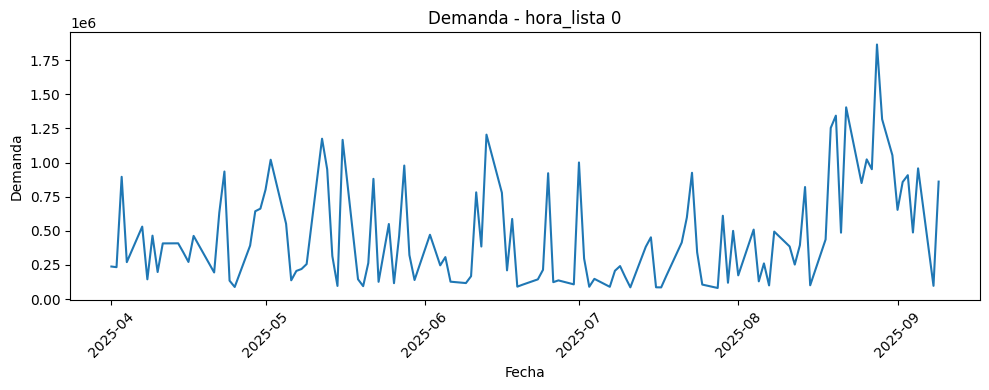

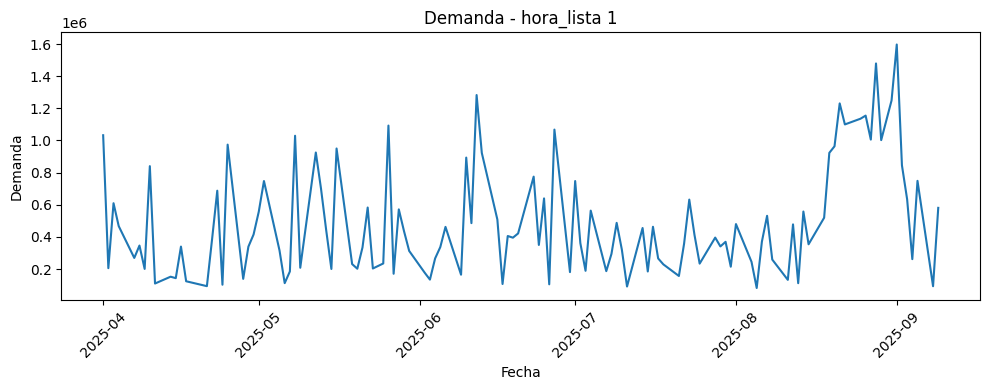

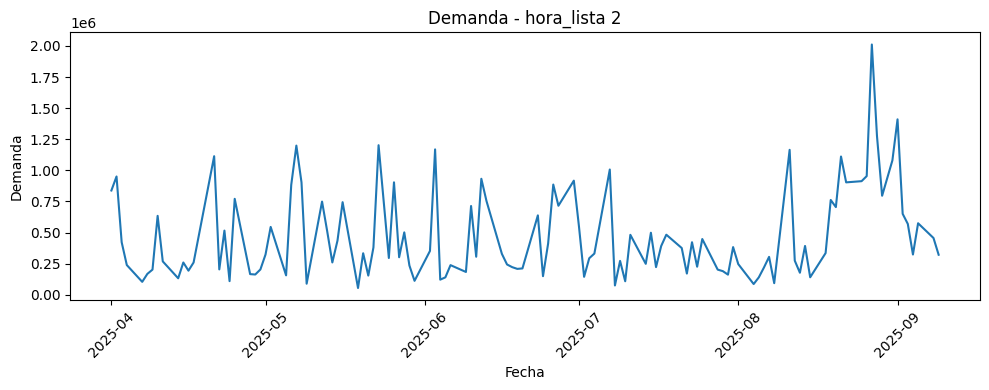

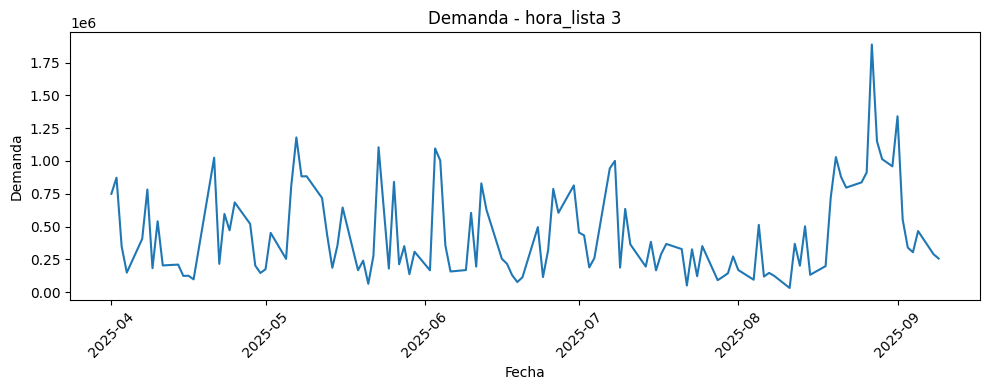

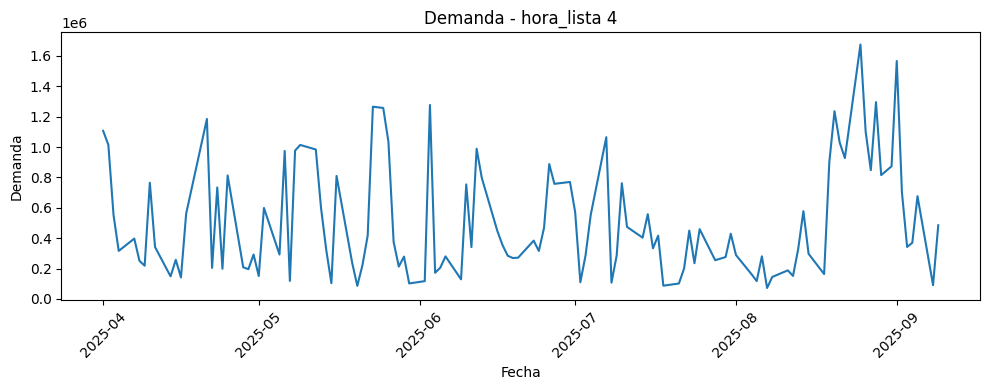

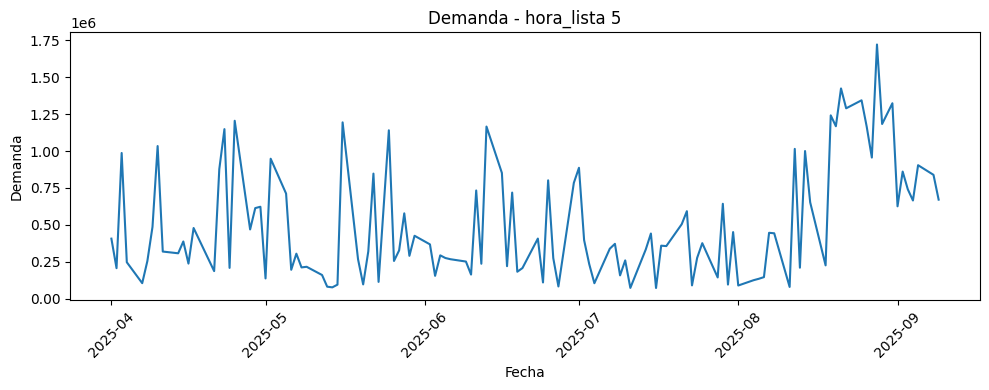

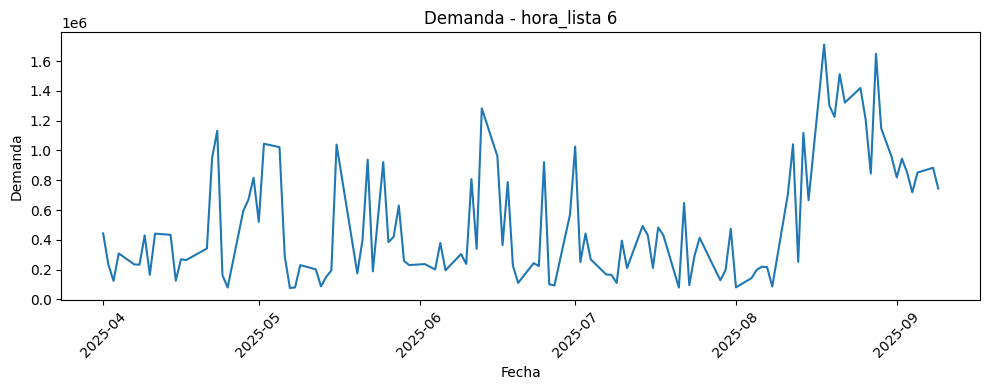

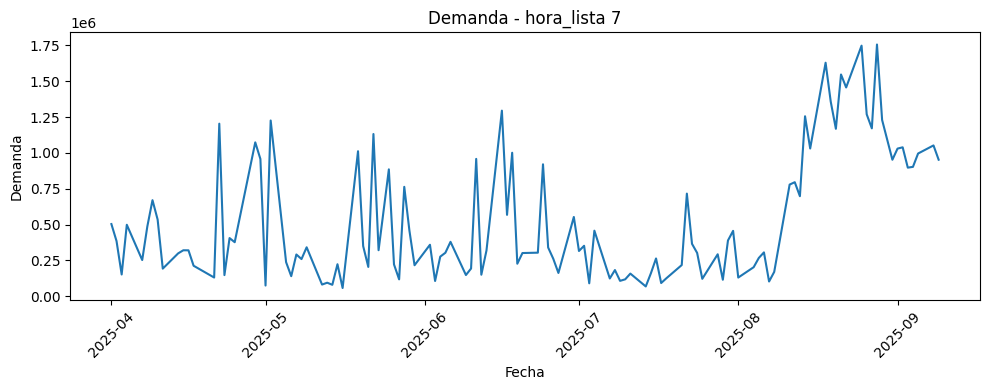

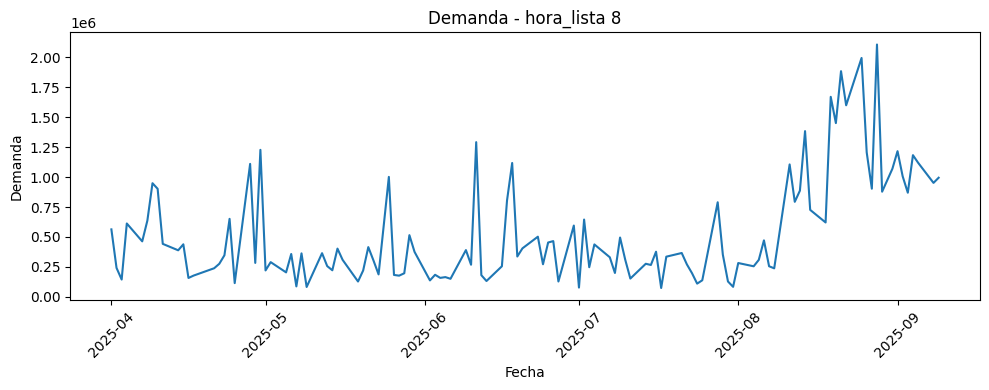

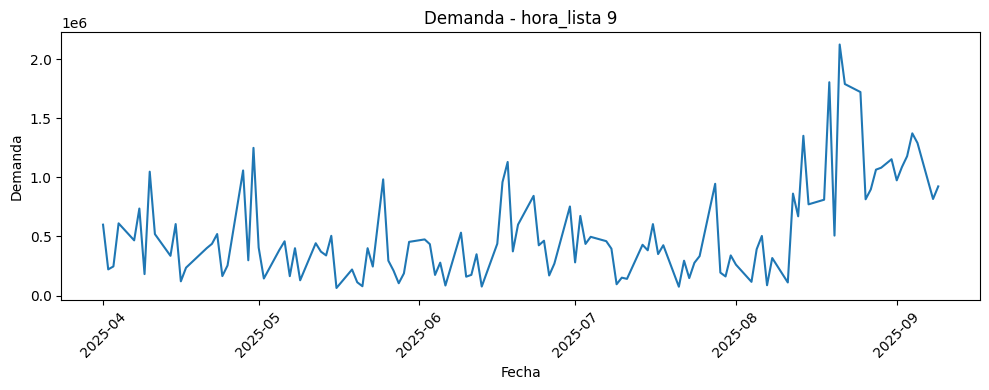

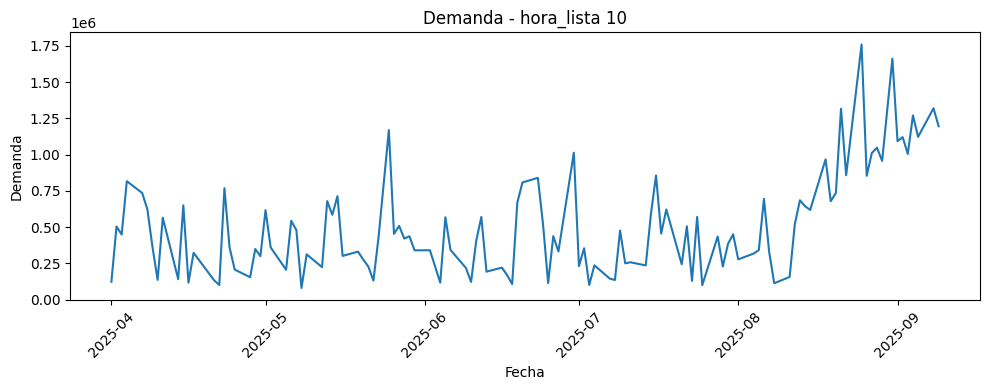

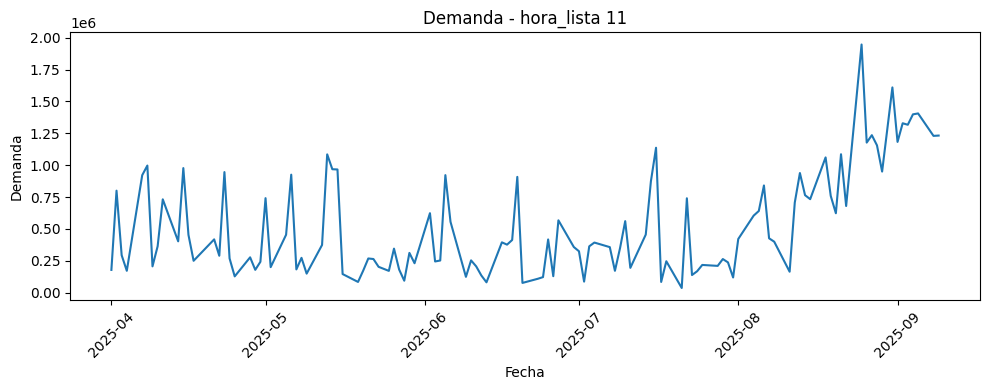

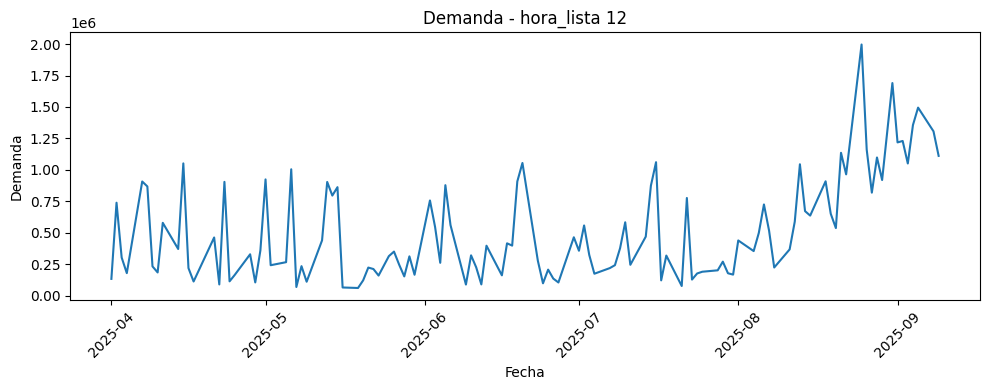

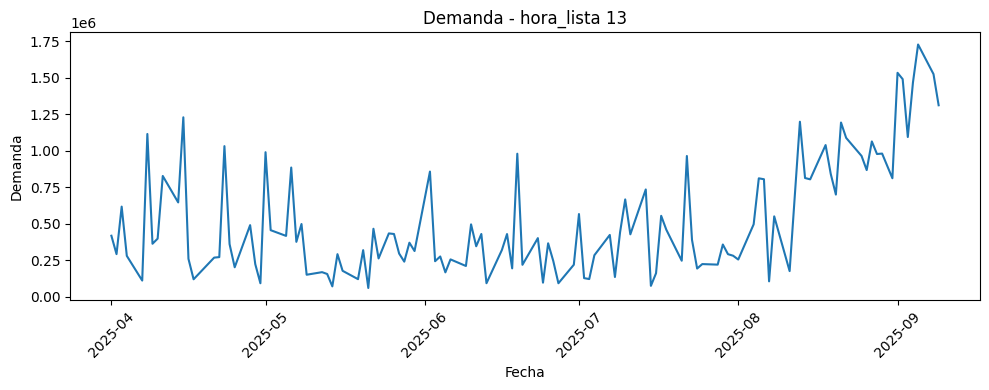

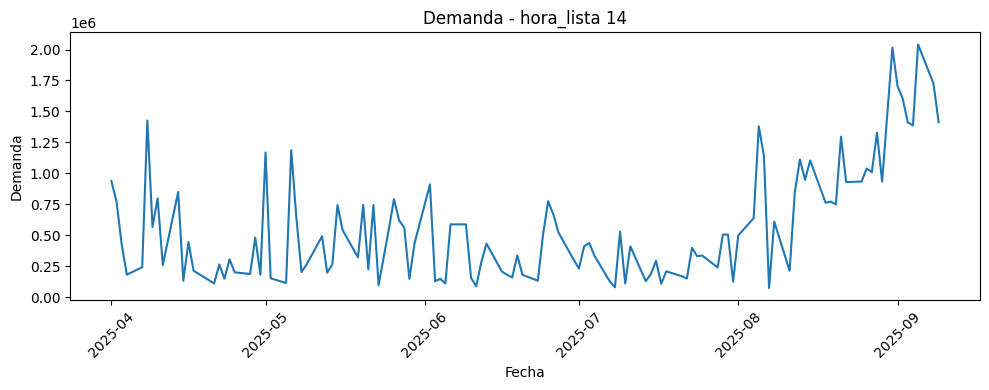

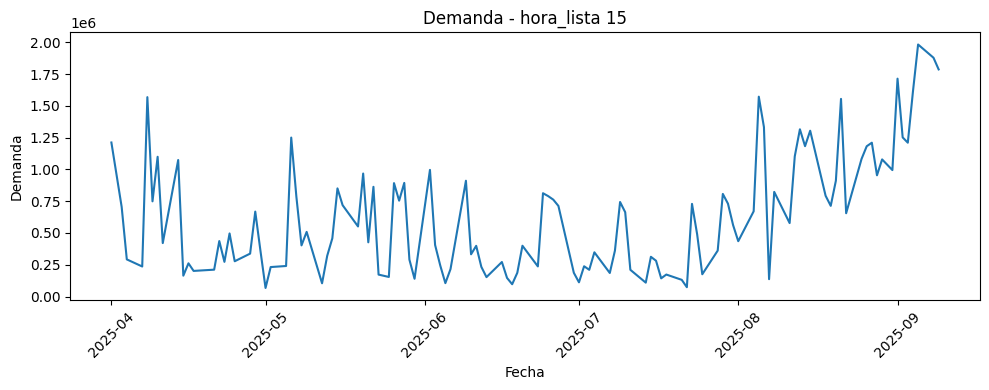

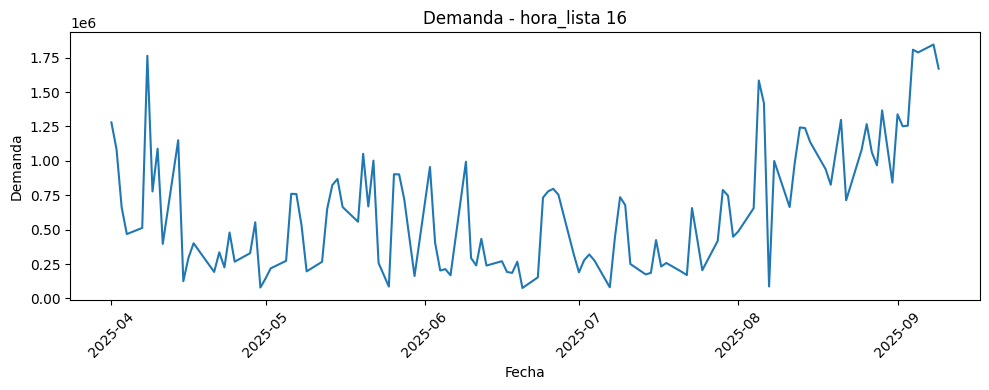

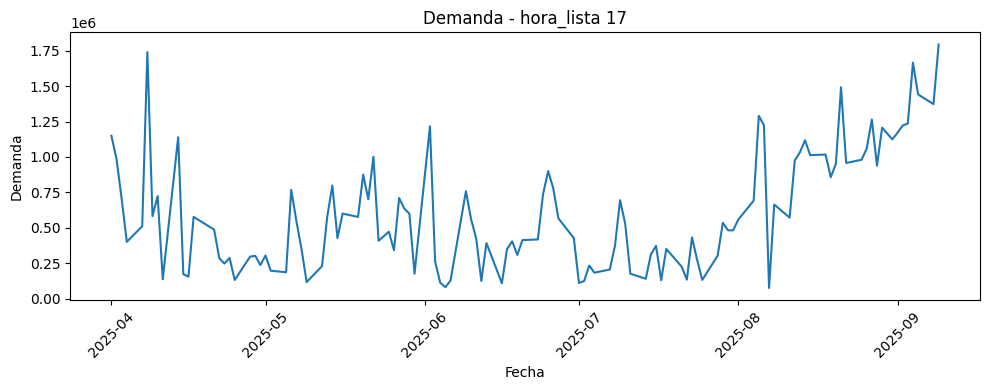

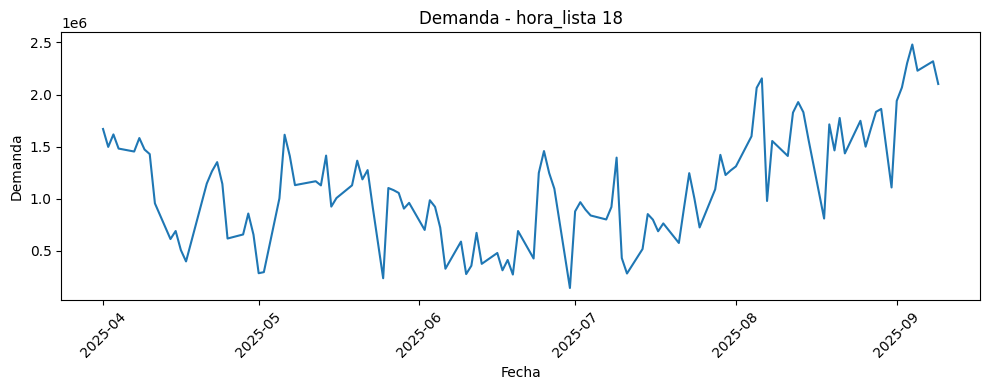

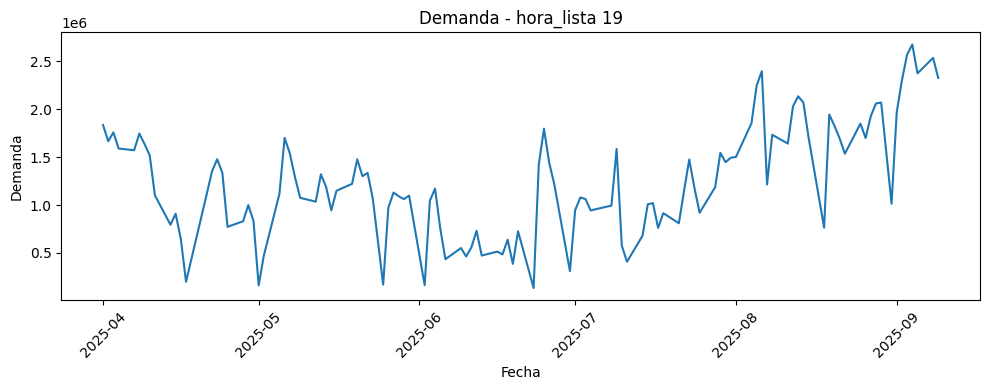

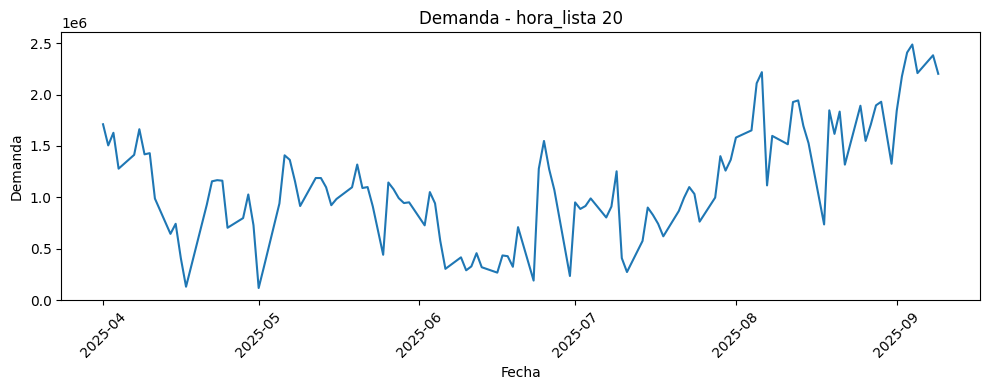

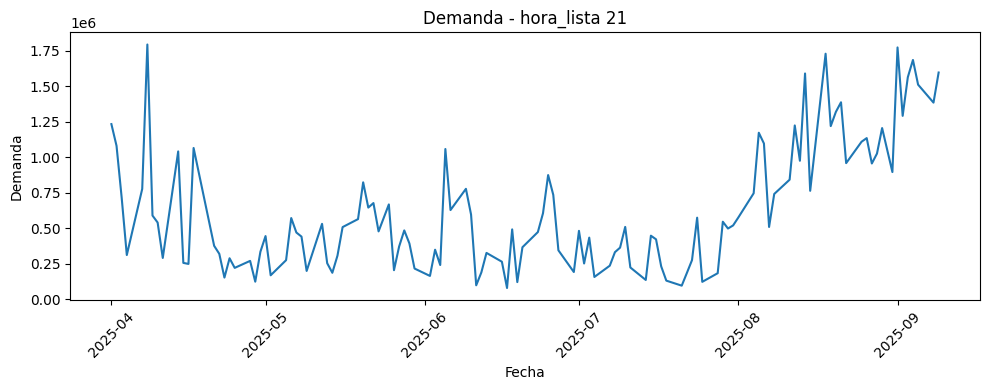

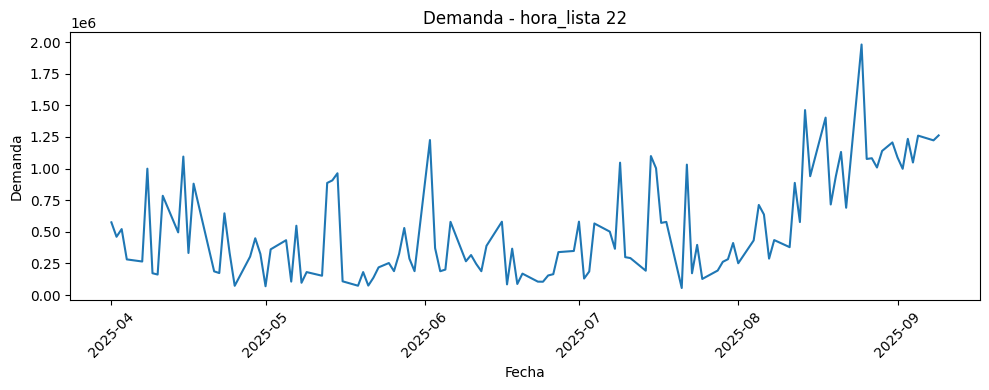

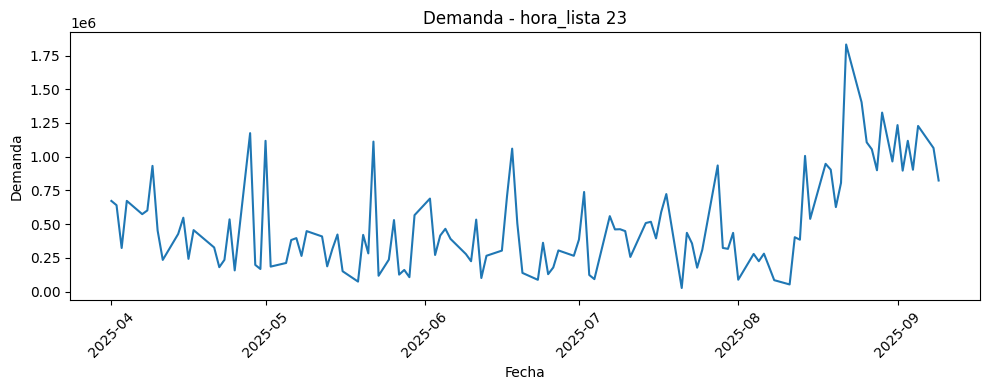

In [14]:
import matplotlib.pyplot as plt

for col in df_pivot.columns:
    
    plt.figure(figsize=(10,4))
    
    plt.plot(df_pivot.index, df_pivot[col])
    
    plt.title(f'Demanda - hora_lista {col}')
    plt.xlabel('Fecha')
    plt.ylabel('Demanda')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()


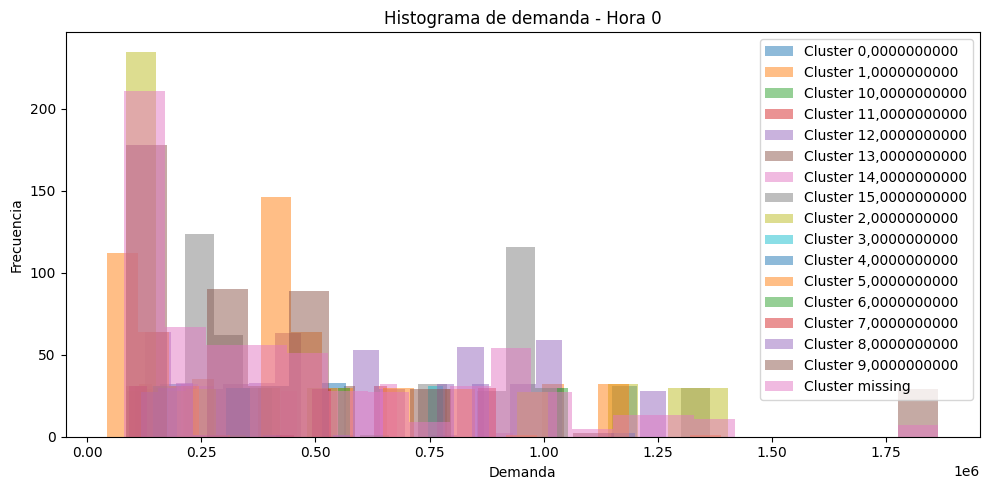

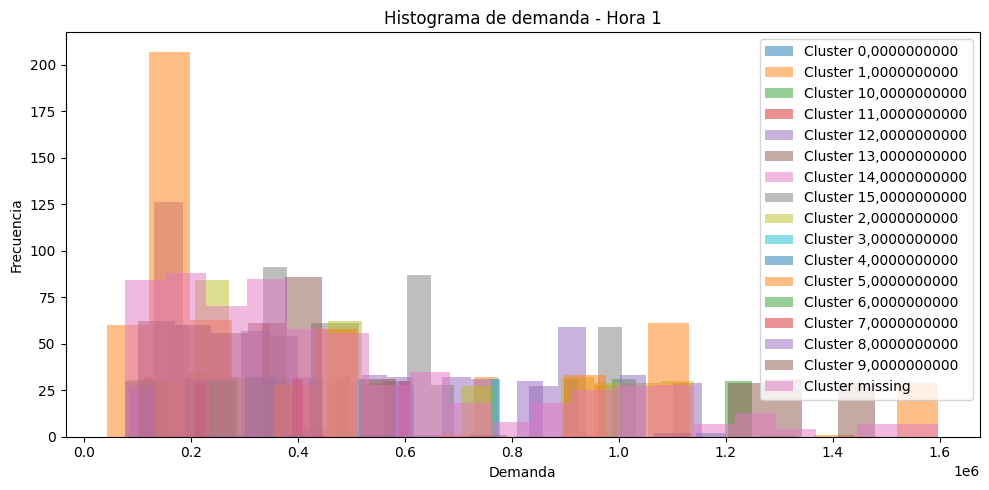

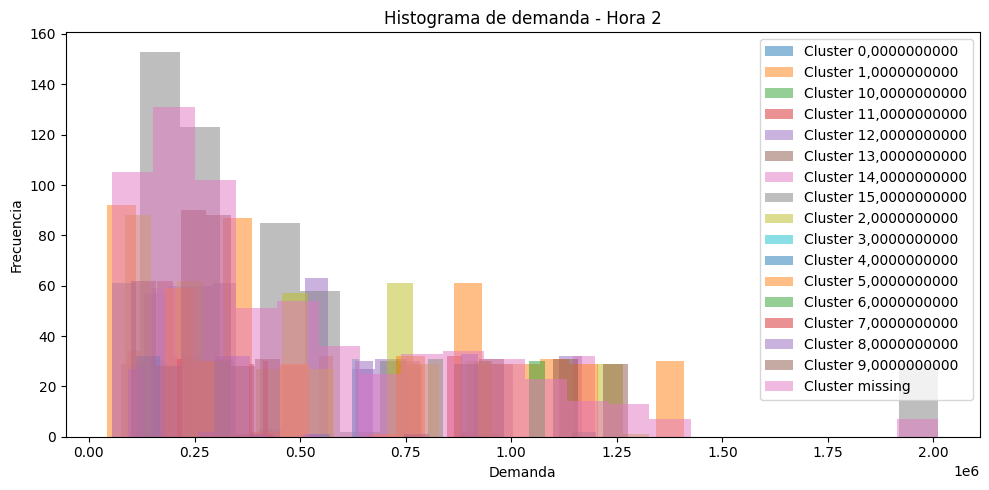

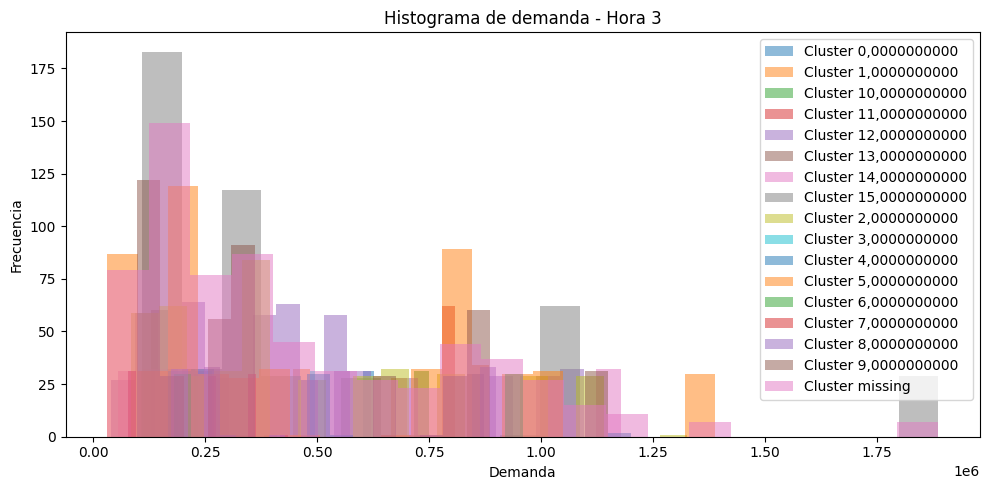

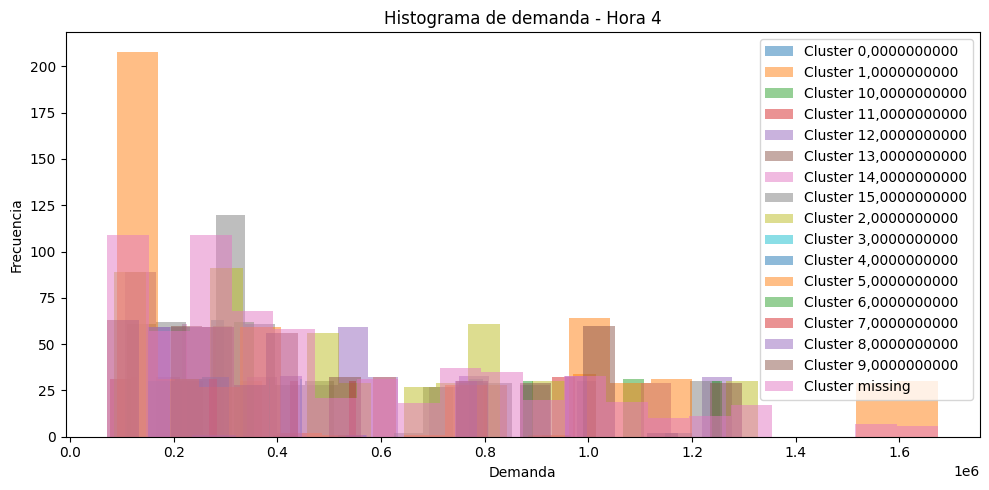

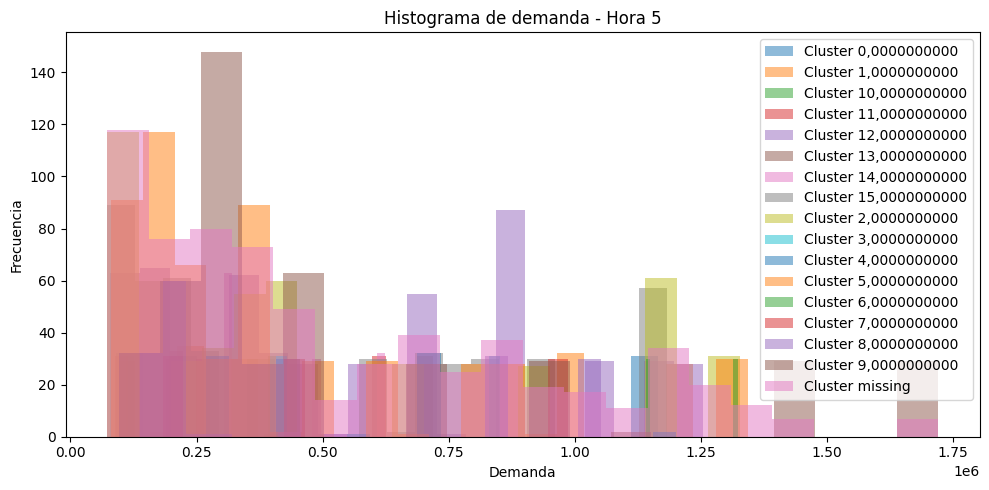

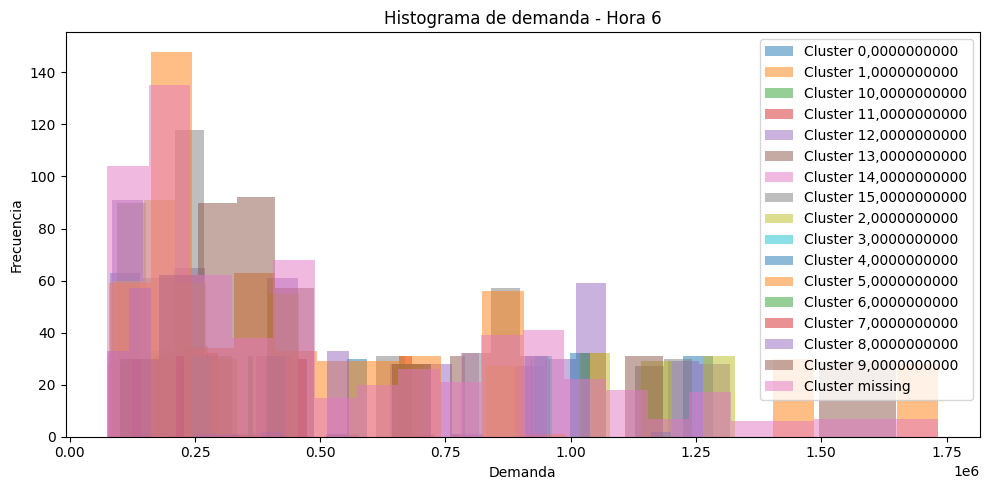

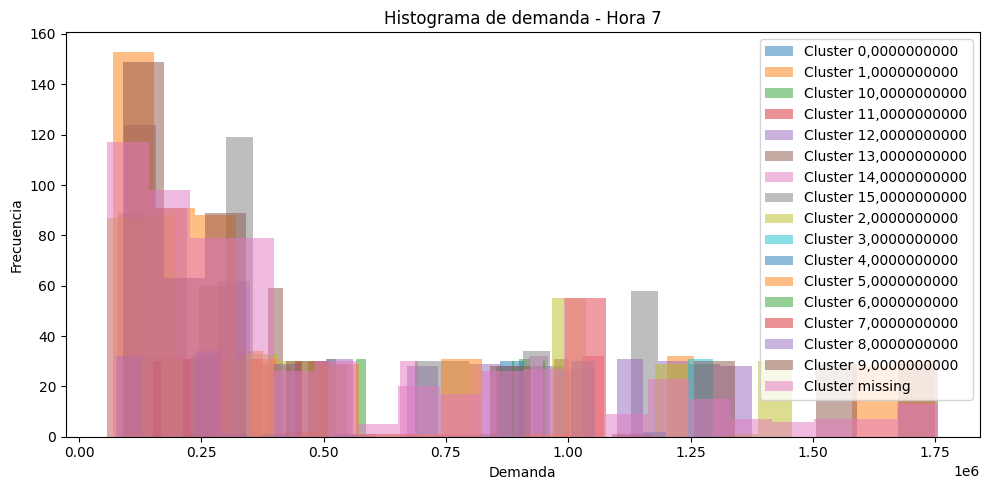

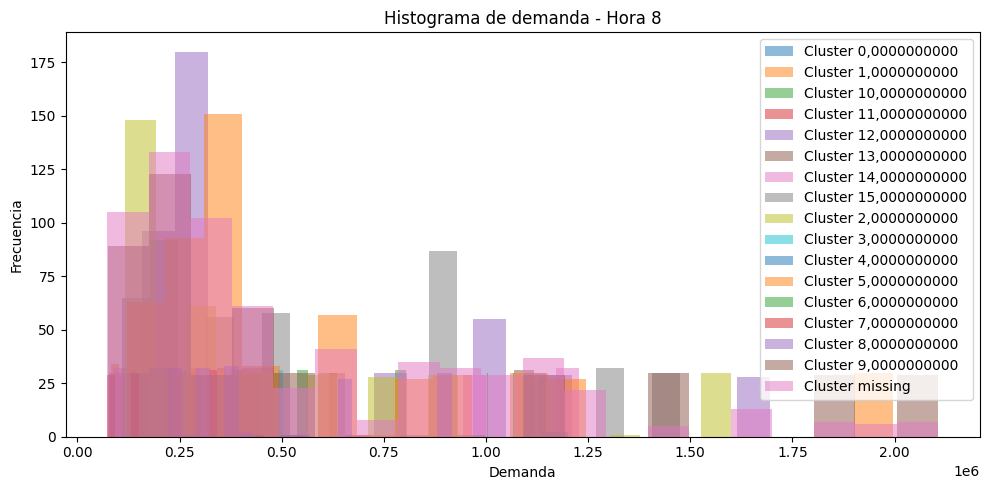

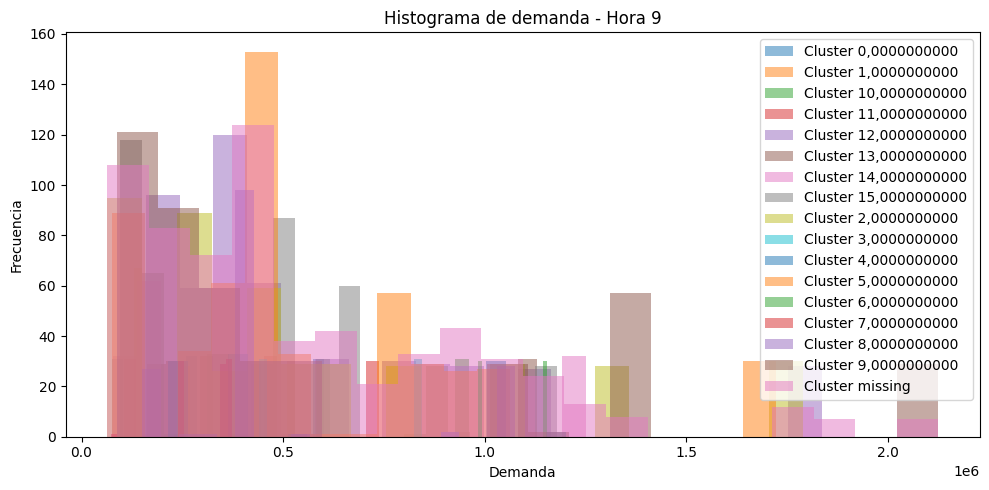

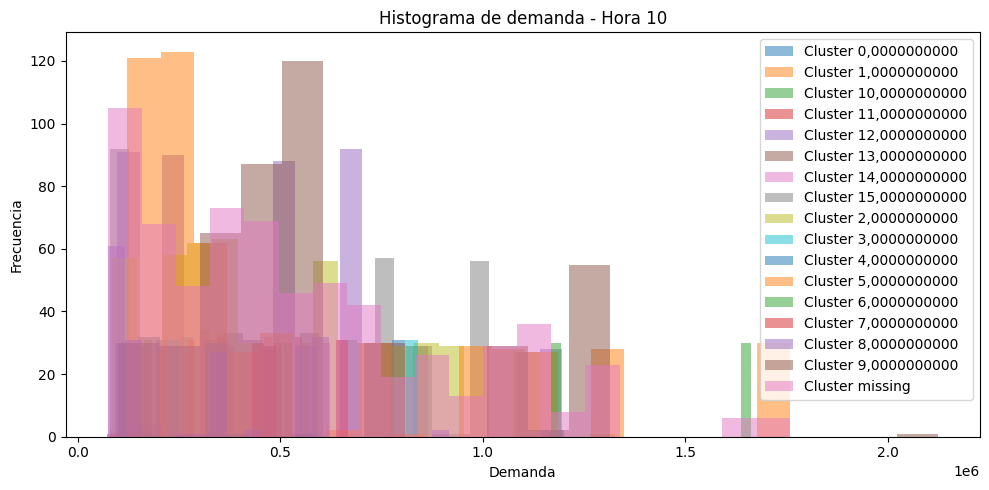

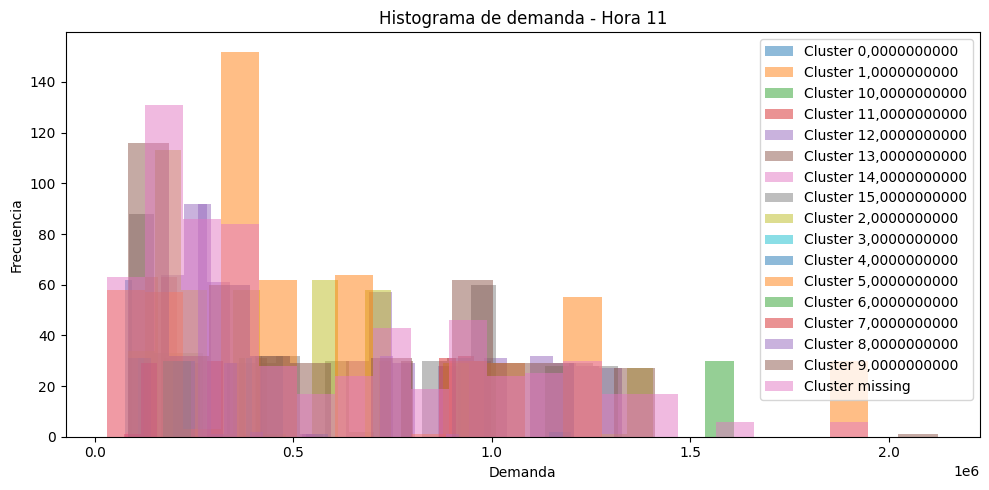

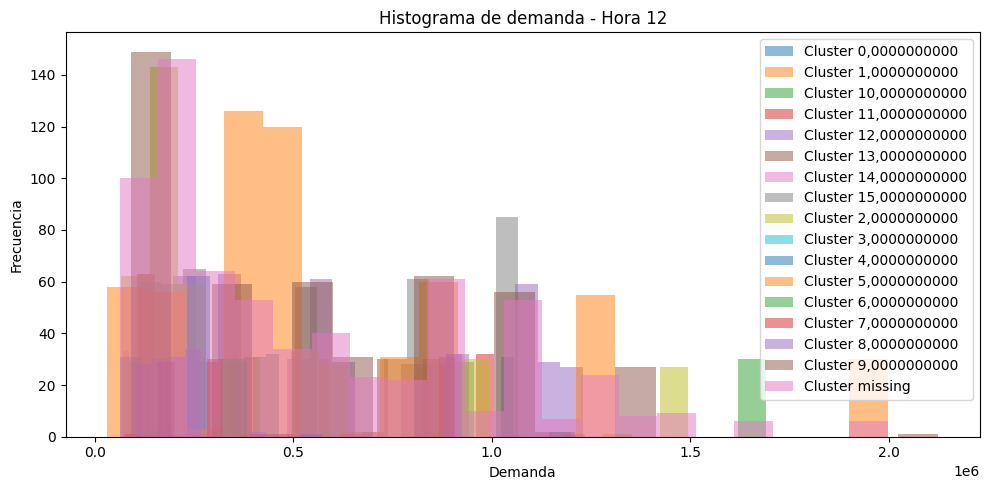

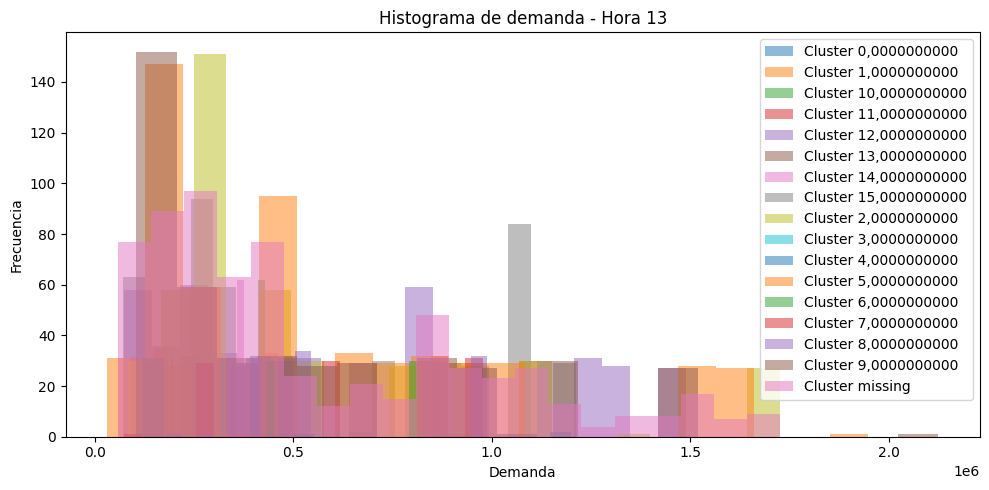

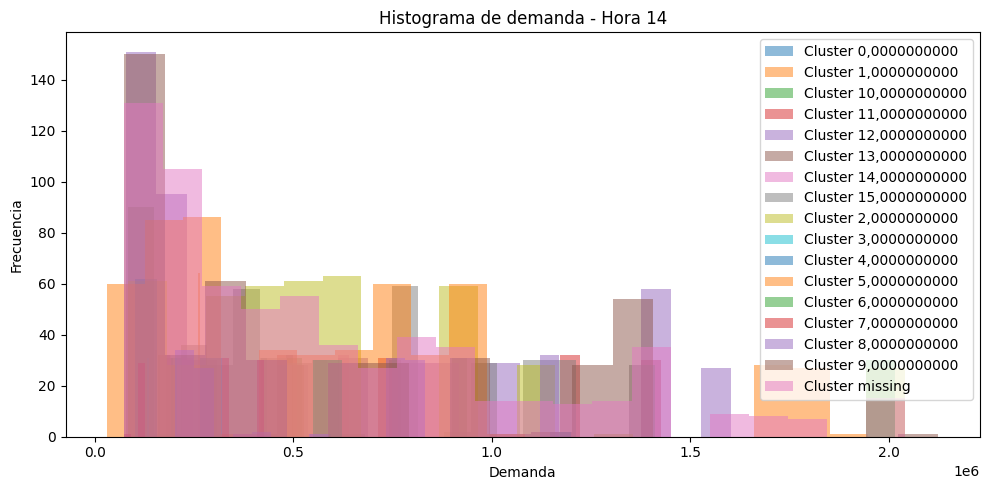

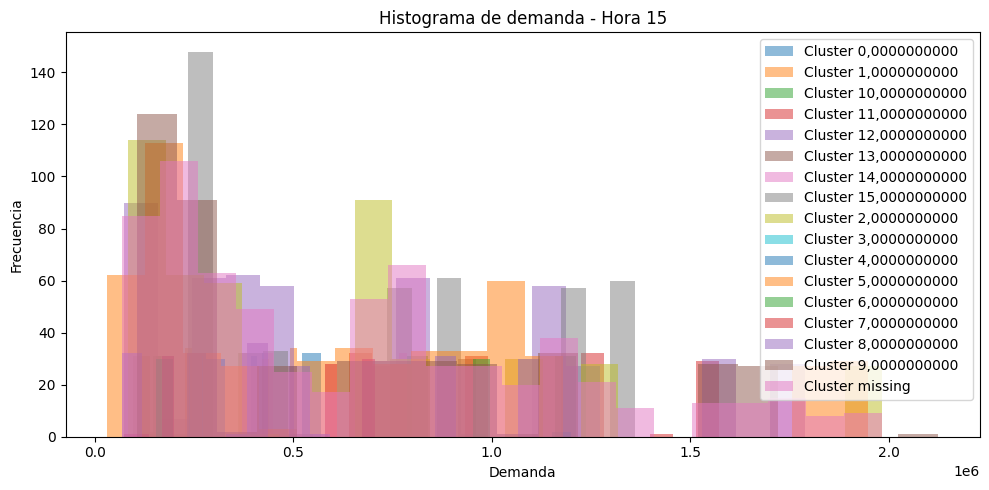

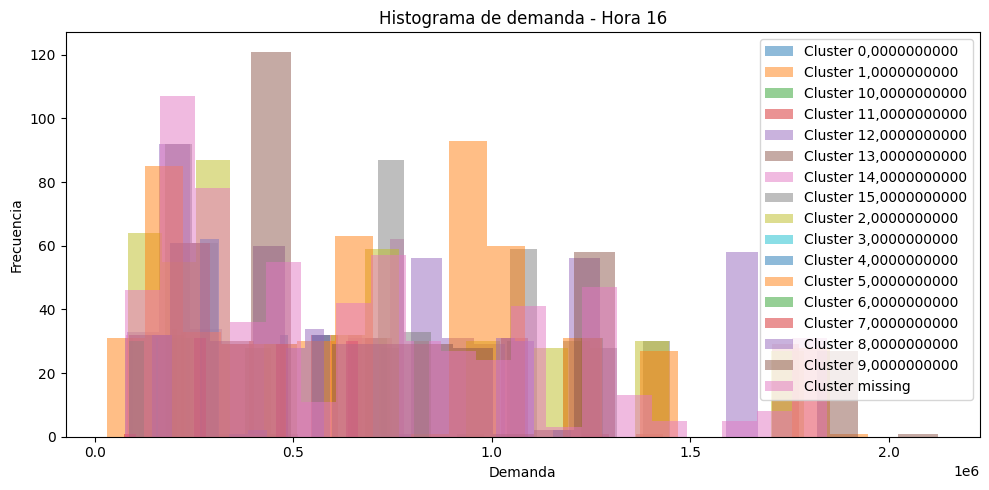

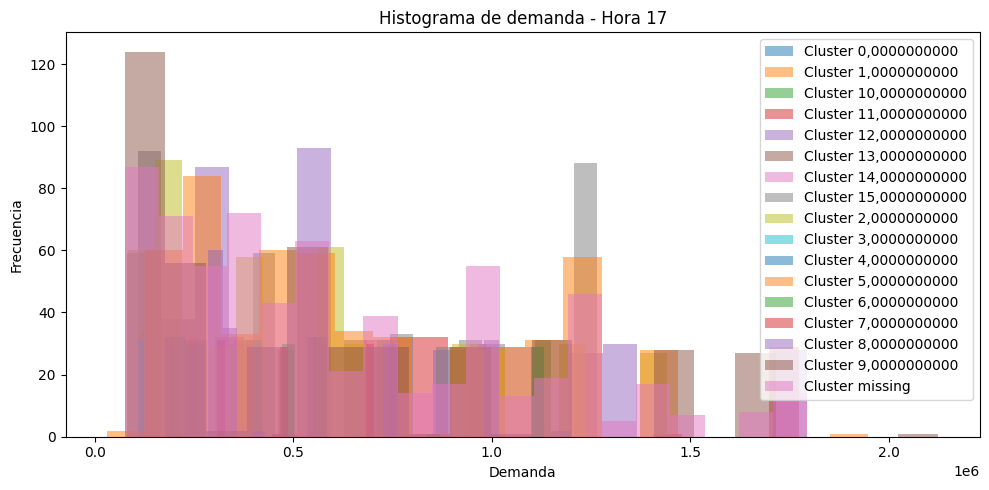

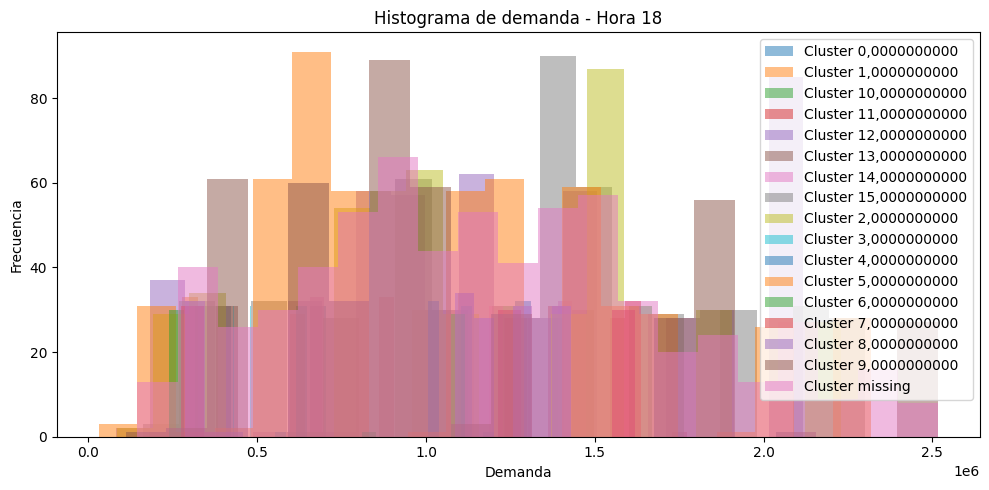

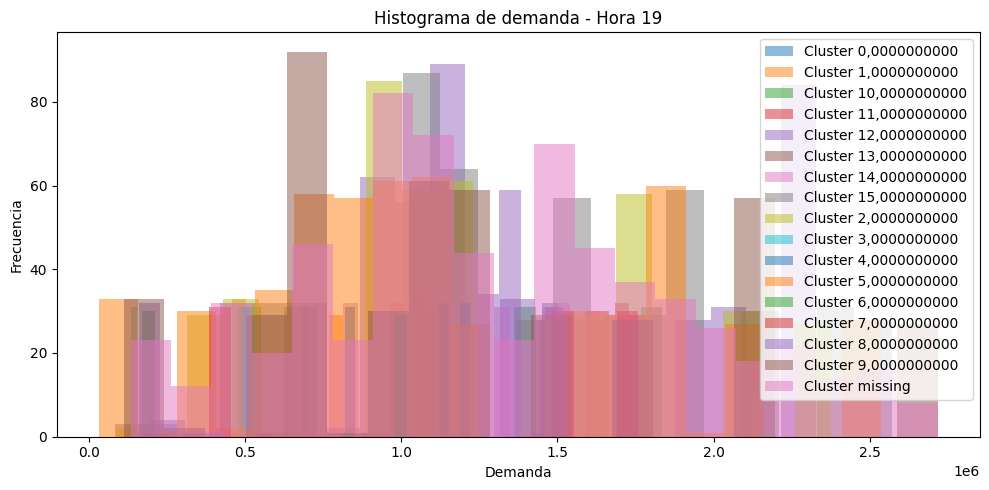

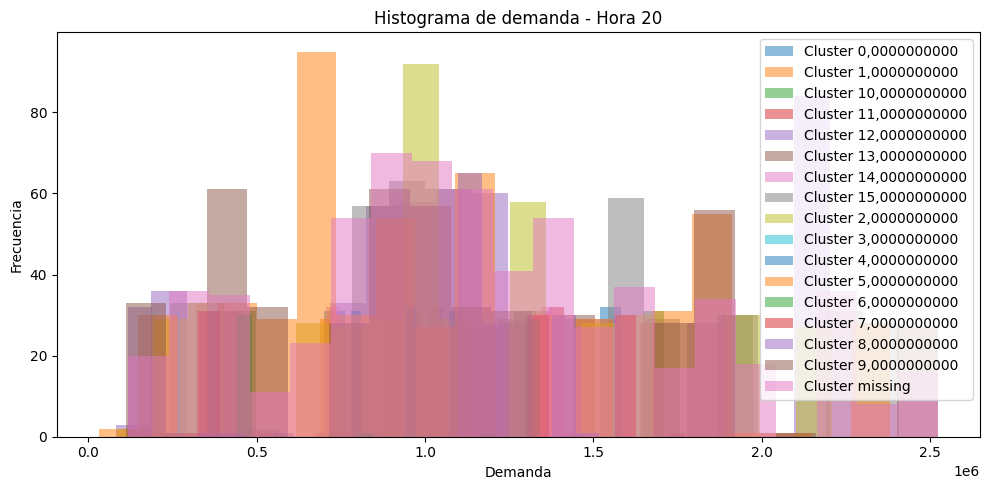

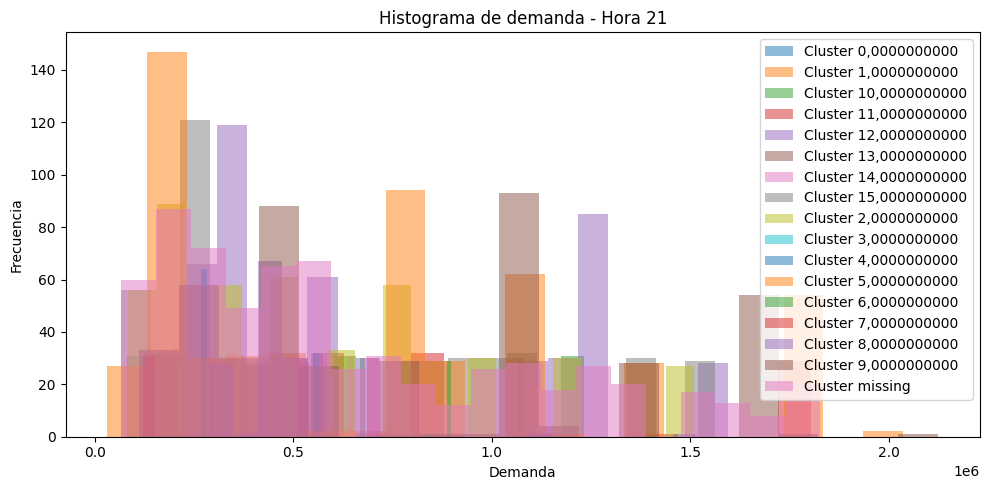

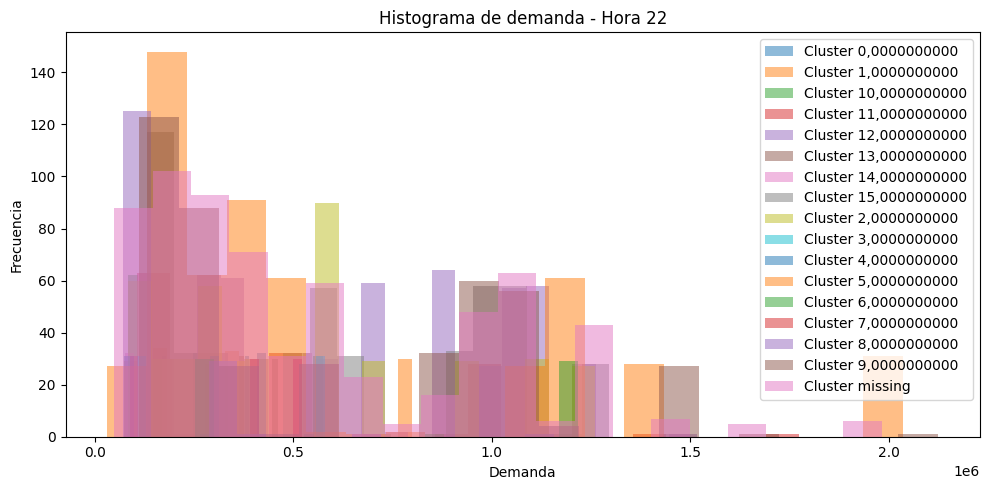

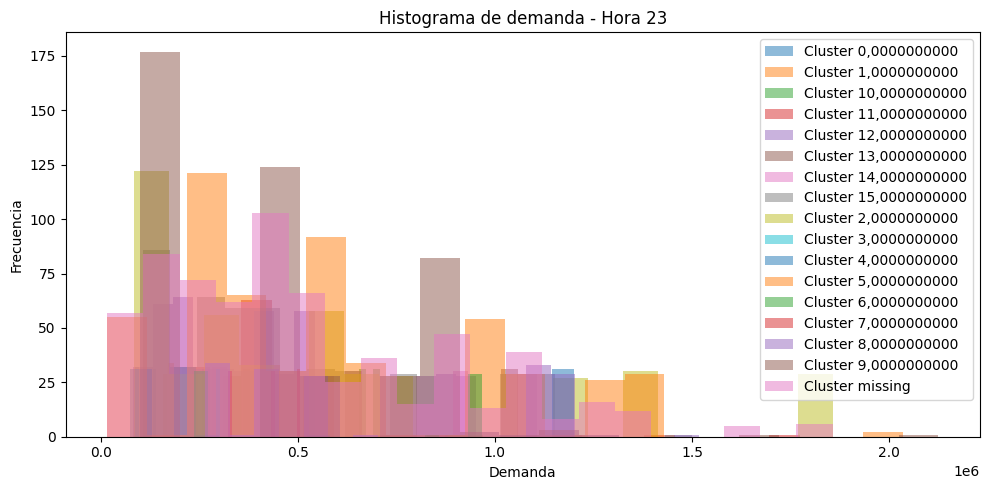

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Asegurarse de que daily_reman_demand sea lista
input_red['daily_reman_demand'] = input_red['daily_reman_demand'].apply(
    lambda x: eval(x) if isinstance(x, str) else x
)

# 2️⃣ Expandir la lista por fila
df_exp = input_red.explode('daily_reman_demand')

# 3️⃣ Crear hora_lista
df_exp['hora_lista'] = df_exp.groupby(['Fecha_sola','CodigoPlanta']).cumcount()

# 4️⃣ Convertir cluster a string y reemplazar NaN
df_exp['cluster'] = df_exp['cluster'].astype(str).fillna('missing')
clusters = sorted(df_exp['cluster'].unique())

# 5️⃣ Horas únicas
horas = sorted(df_exp['hora_lista'].unique())

# Colores consistentes
colors = {c: plt.cm.tab10(i % 10) for i, c in enumerate(clusters)}

# 6️⃣ Graficar histogramas por hora
for h in horas:
    plt.figure(figsize=(10,5))
    
    for c in clusters:
        datos = df_exp[(df_exp['hora_lista']==h) & (df_exp['cluster']==c)]['daily_reman_demand']
        if len(datos) > 0:
            plt.hist(datos, bins=20, alpha=0.5, label=f'Cluster {c}', color=colors[c])
    
    plt.title(f'Histograma de demanda - Hora {h}')
    plt.xlabel('Demanda')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()


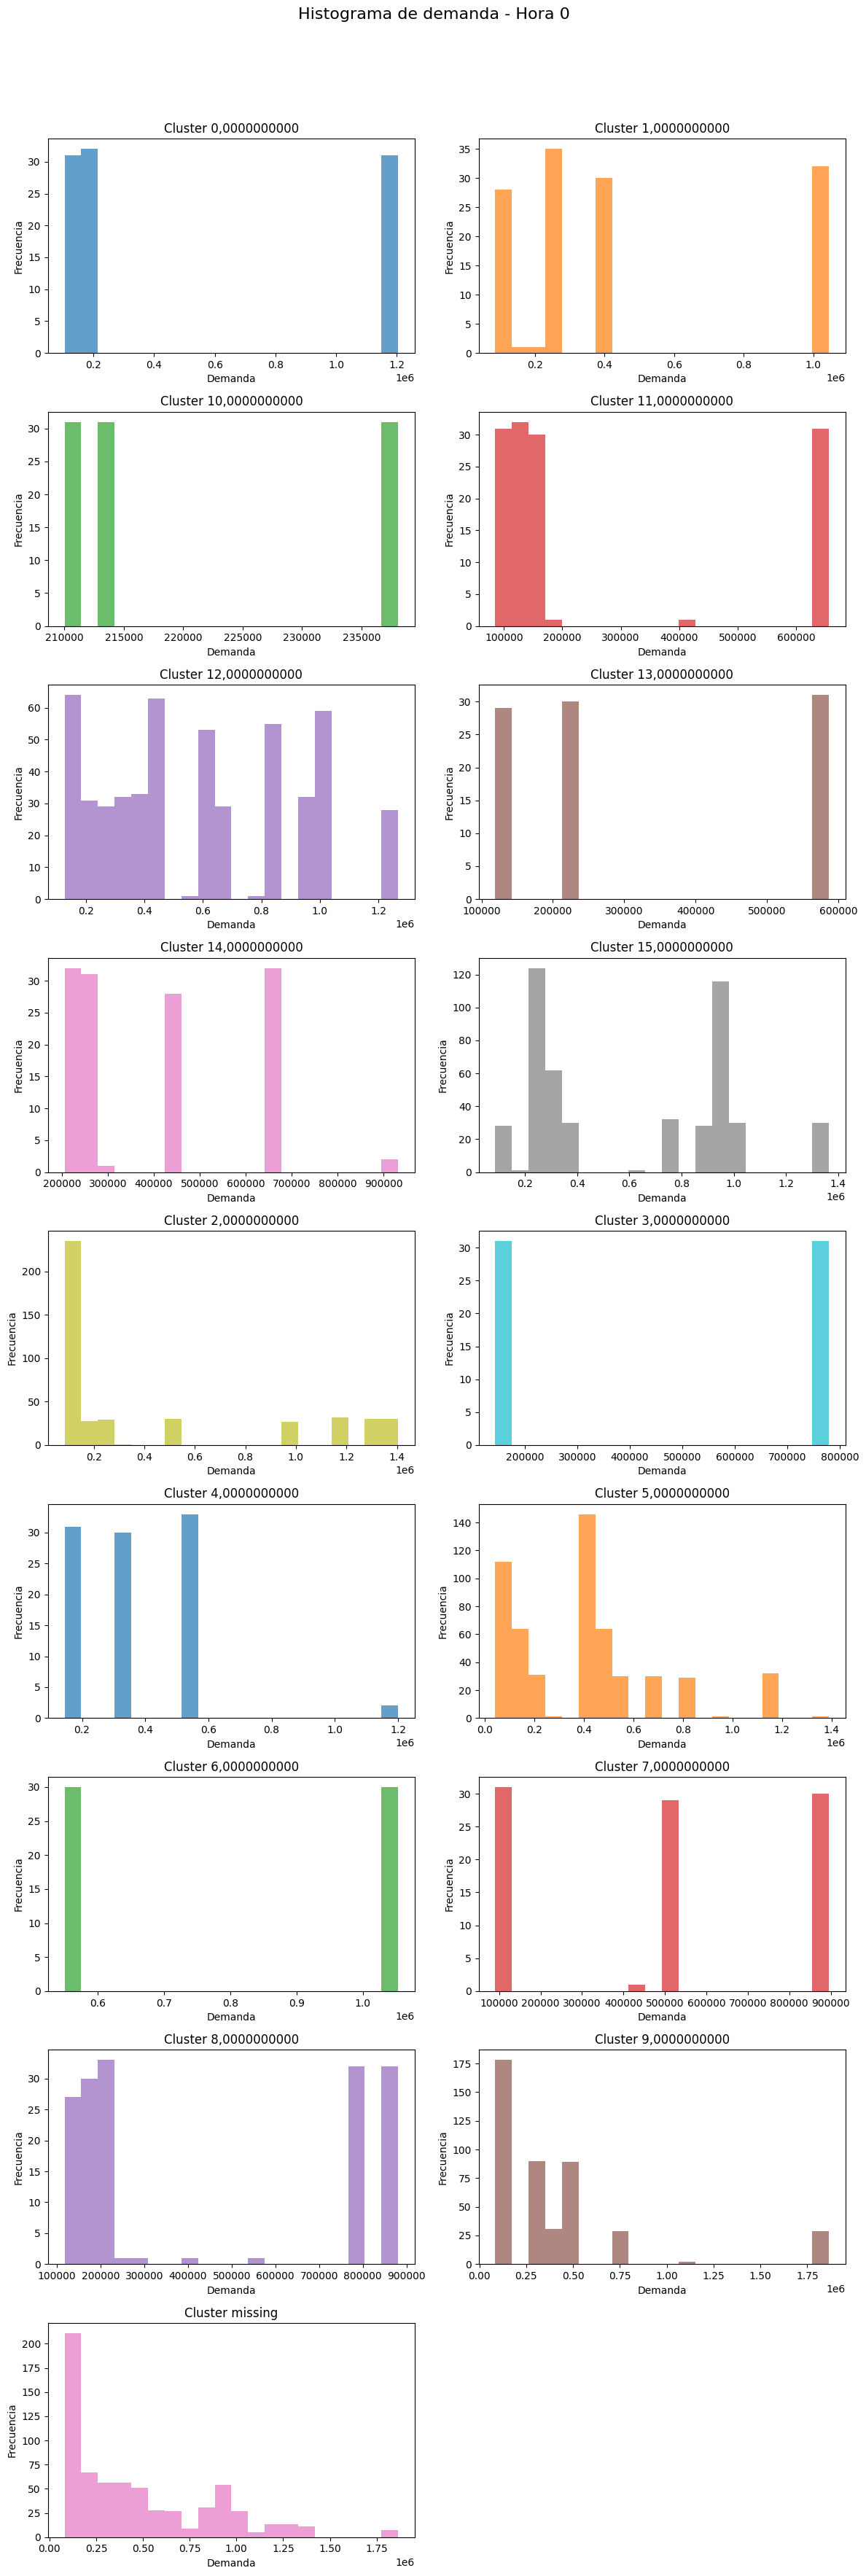

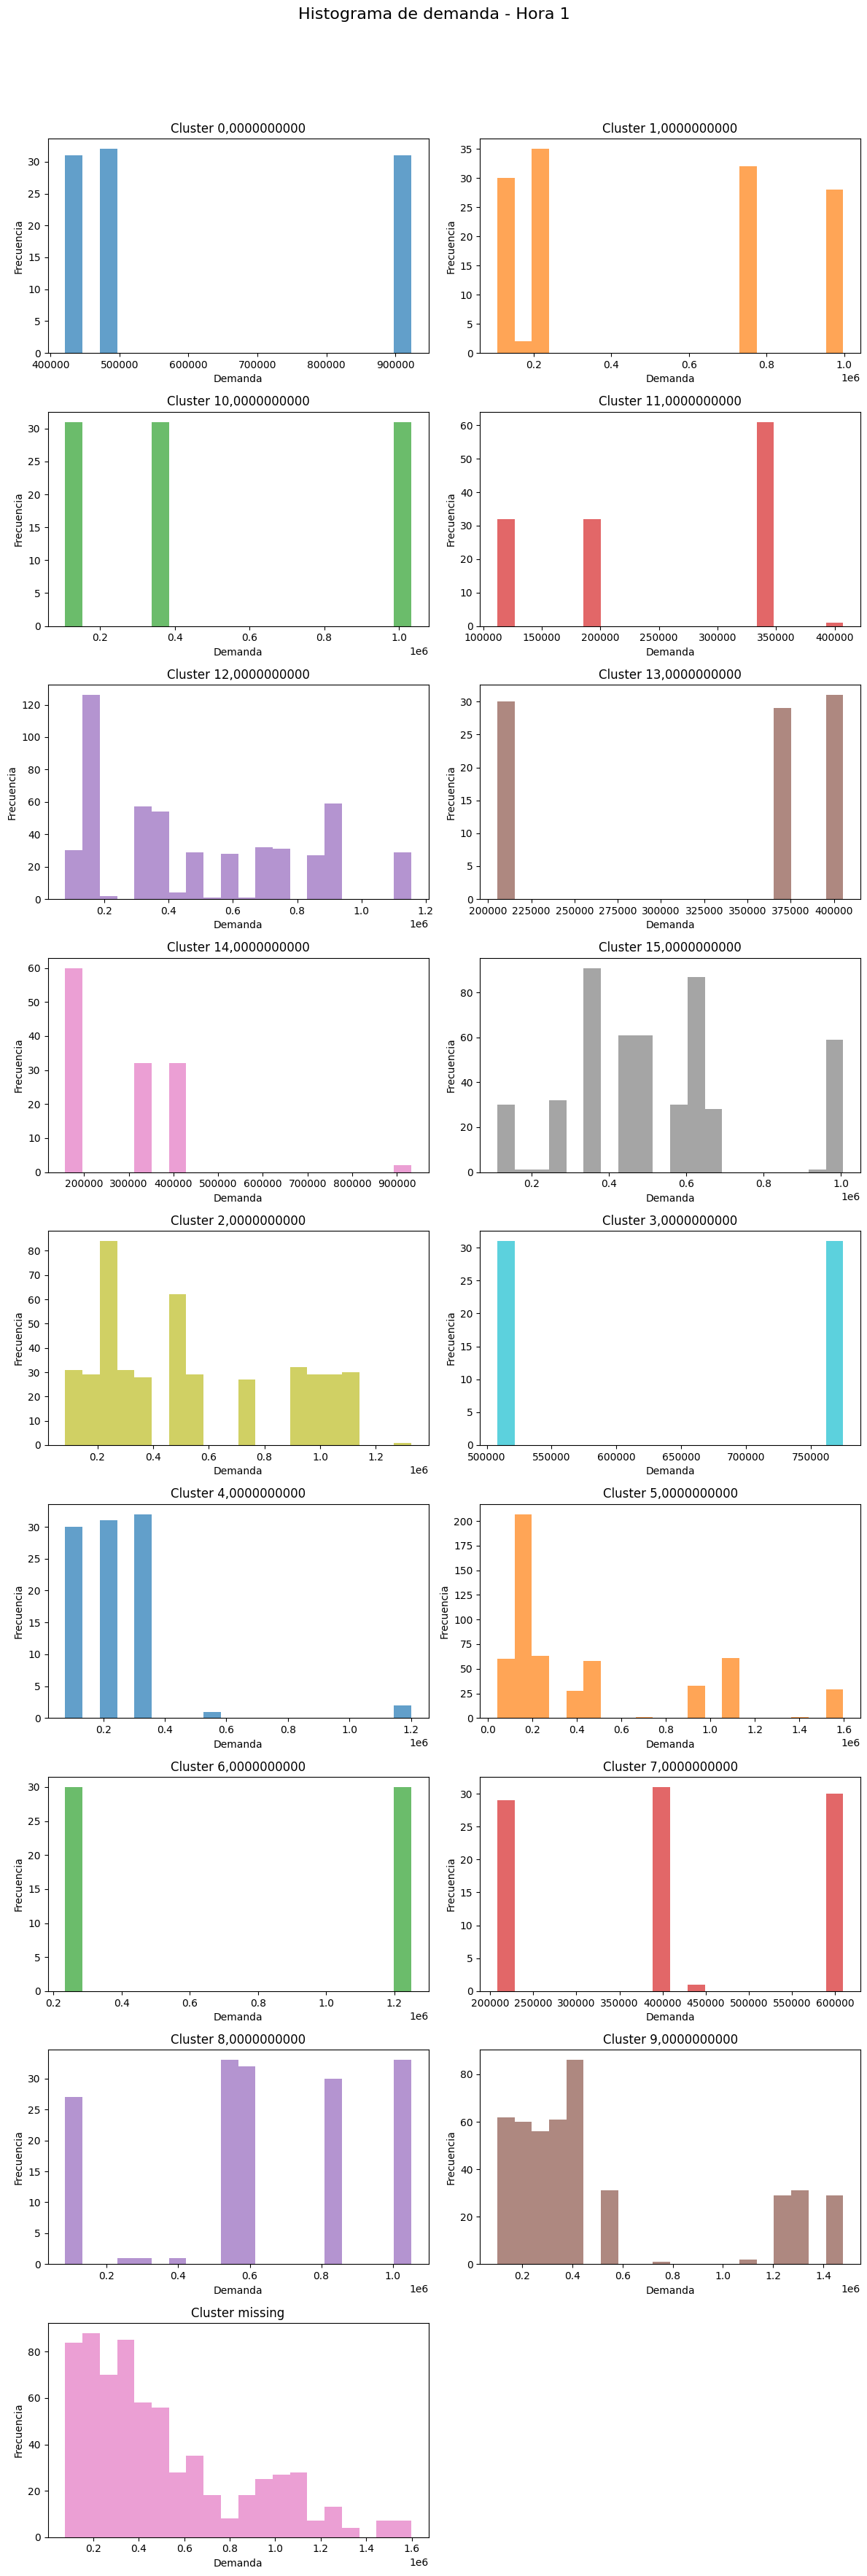

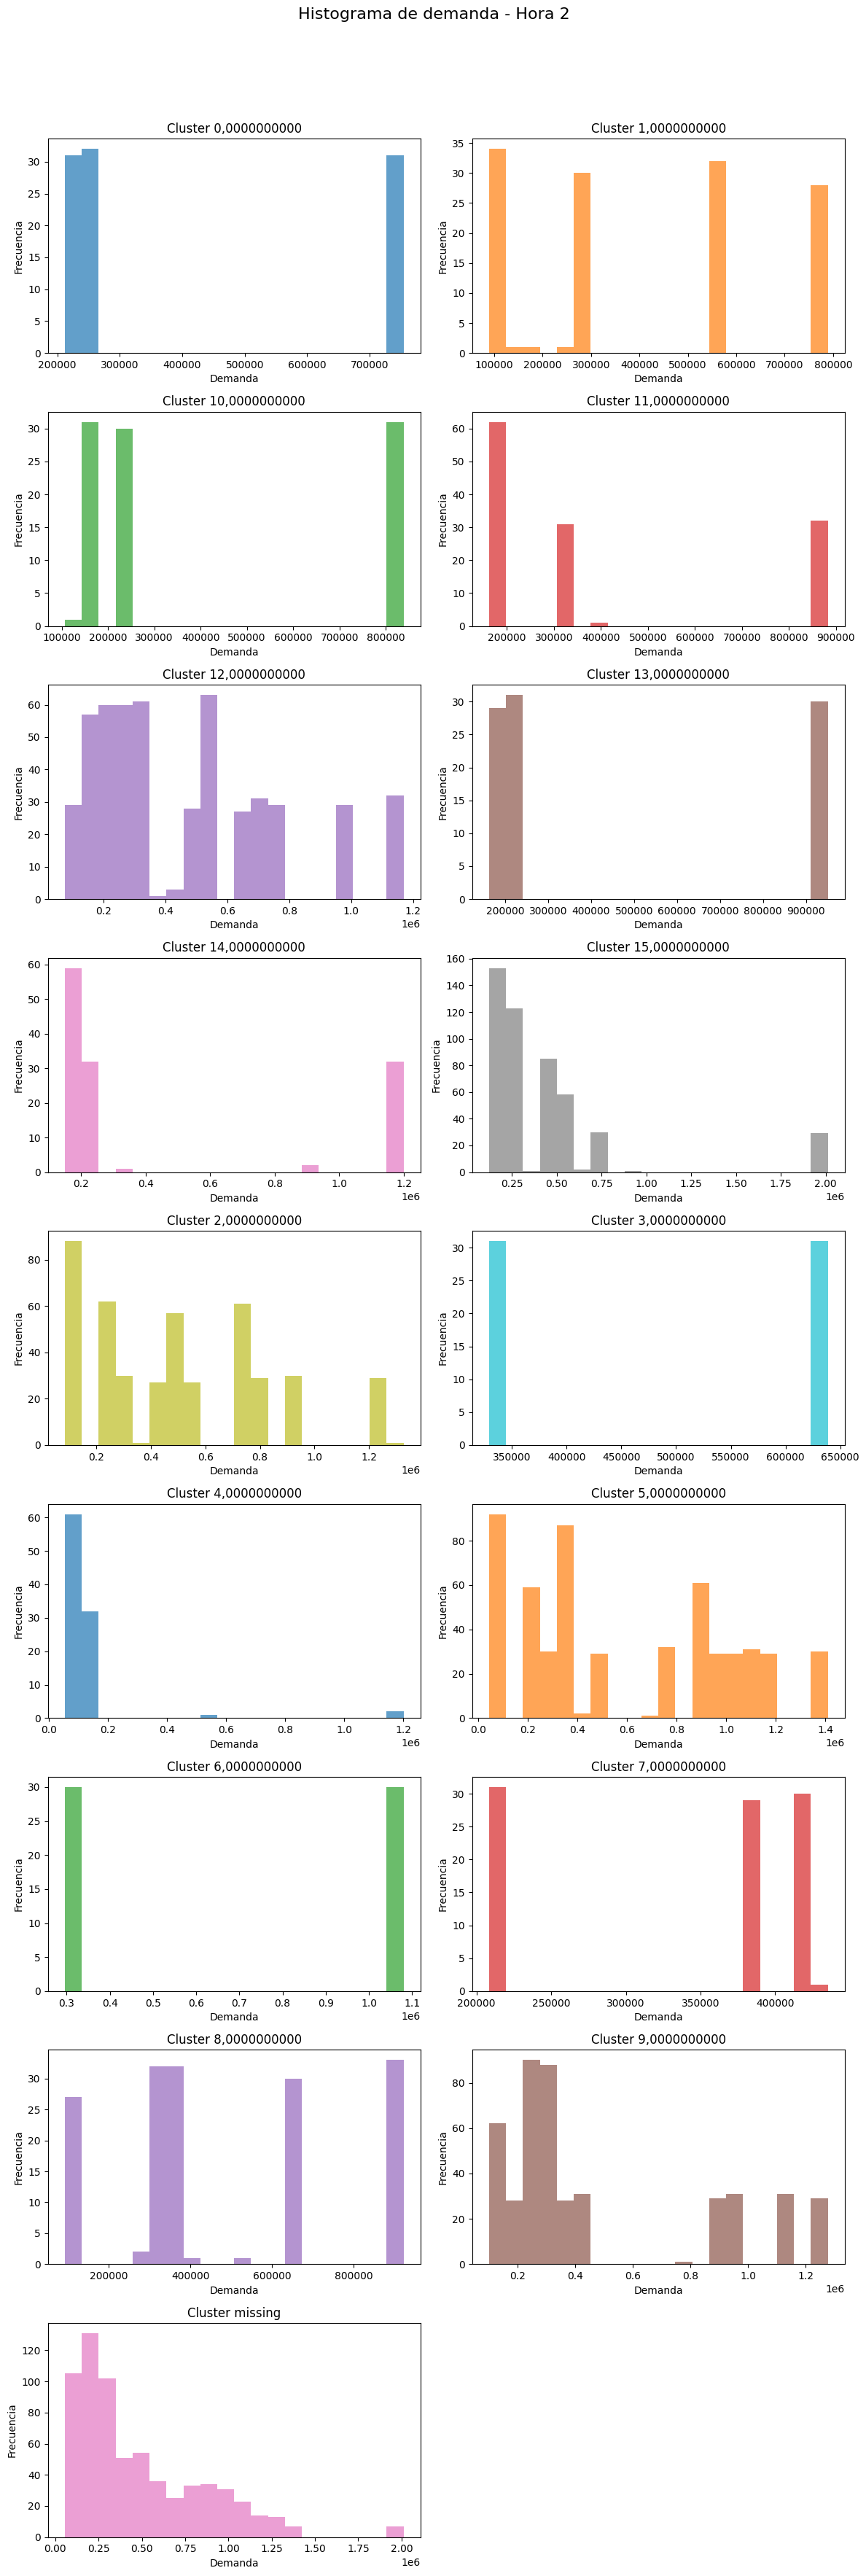

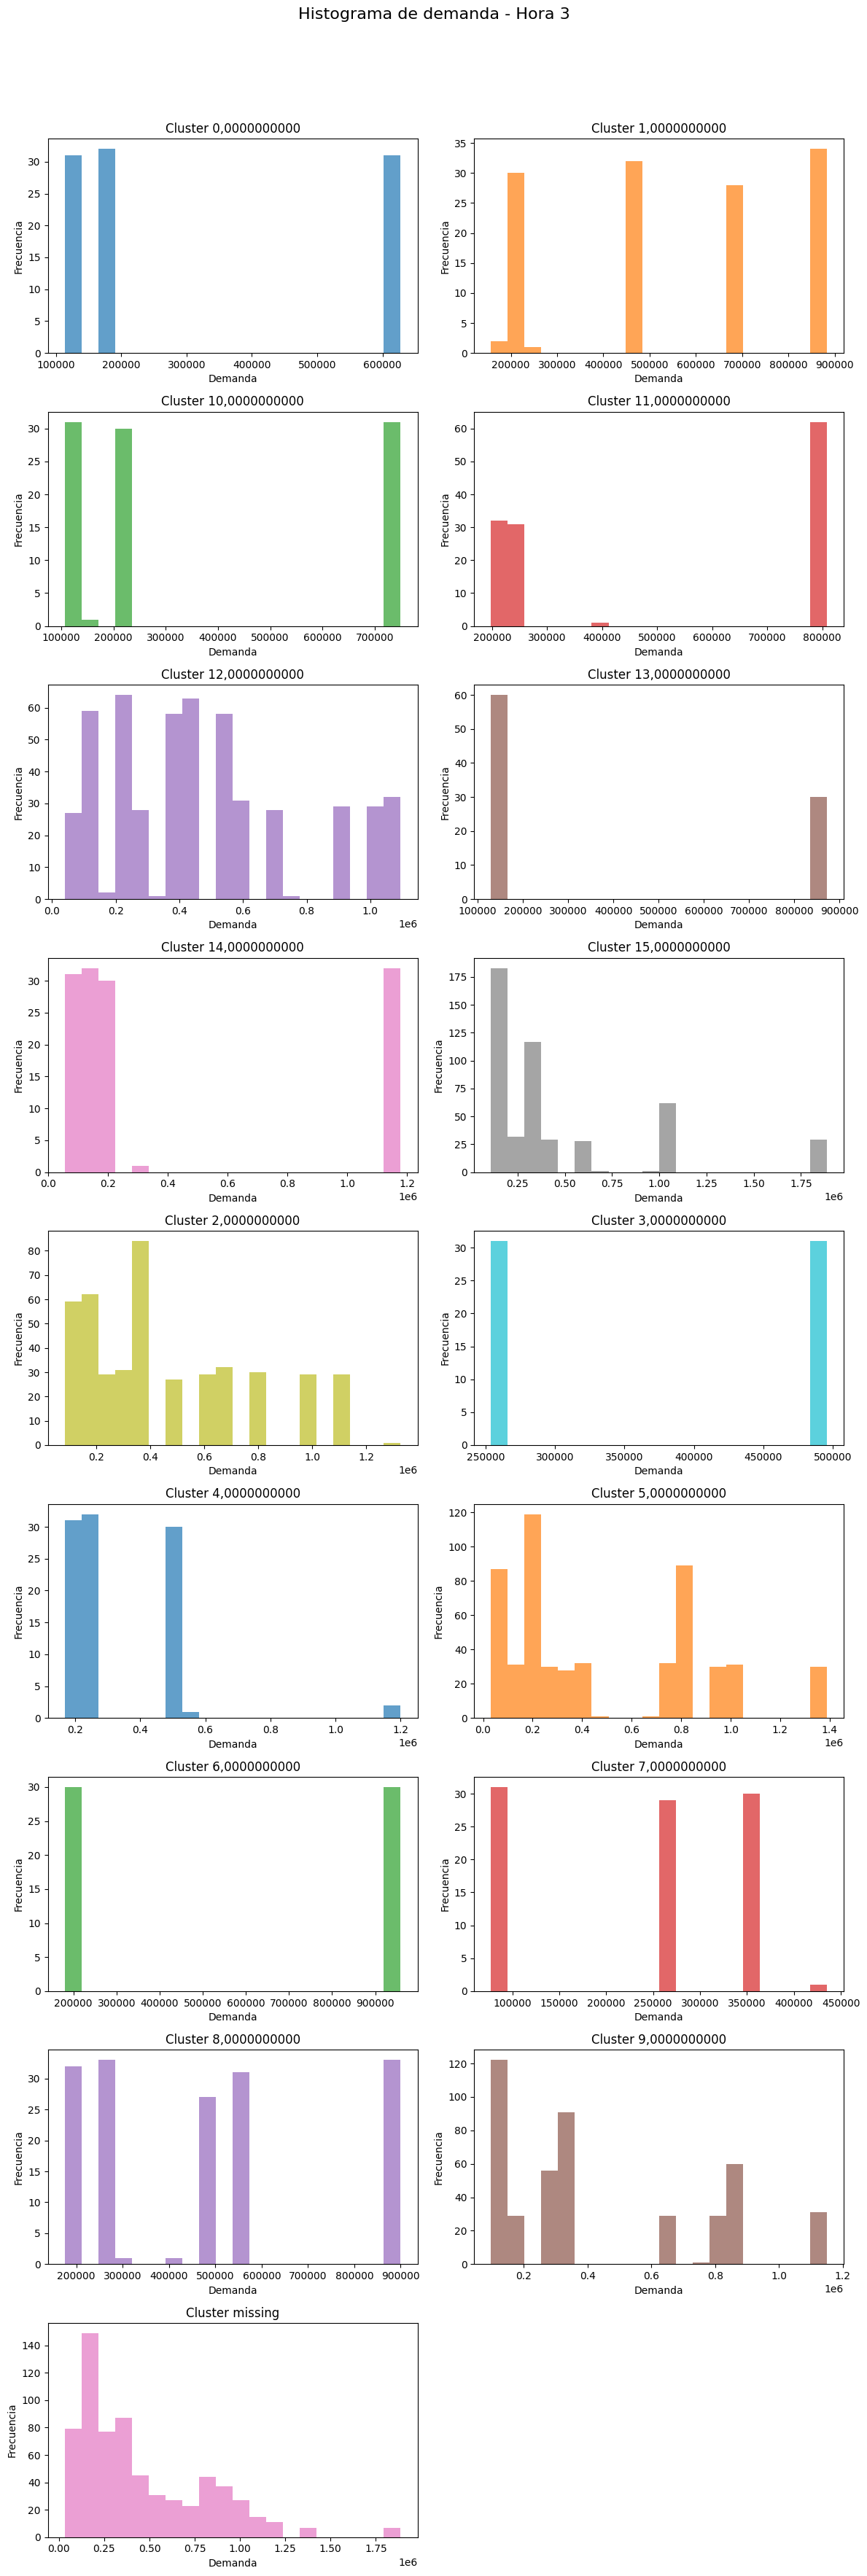

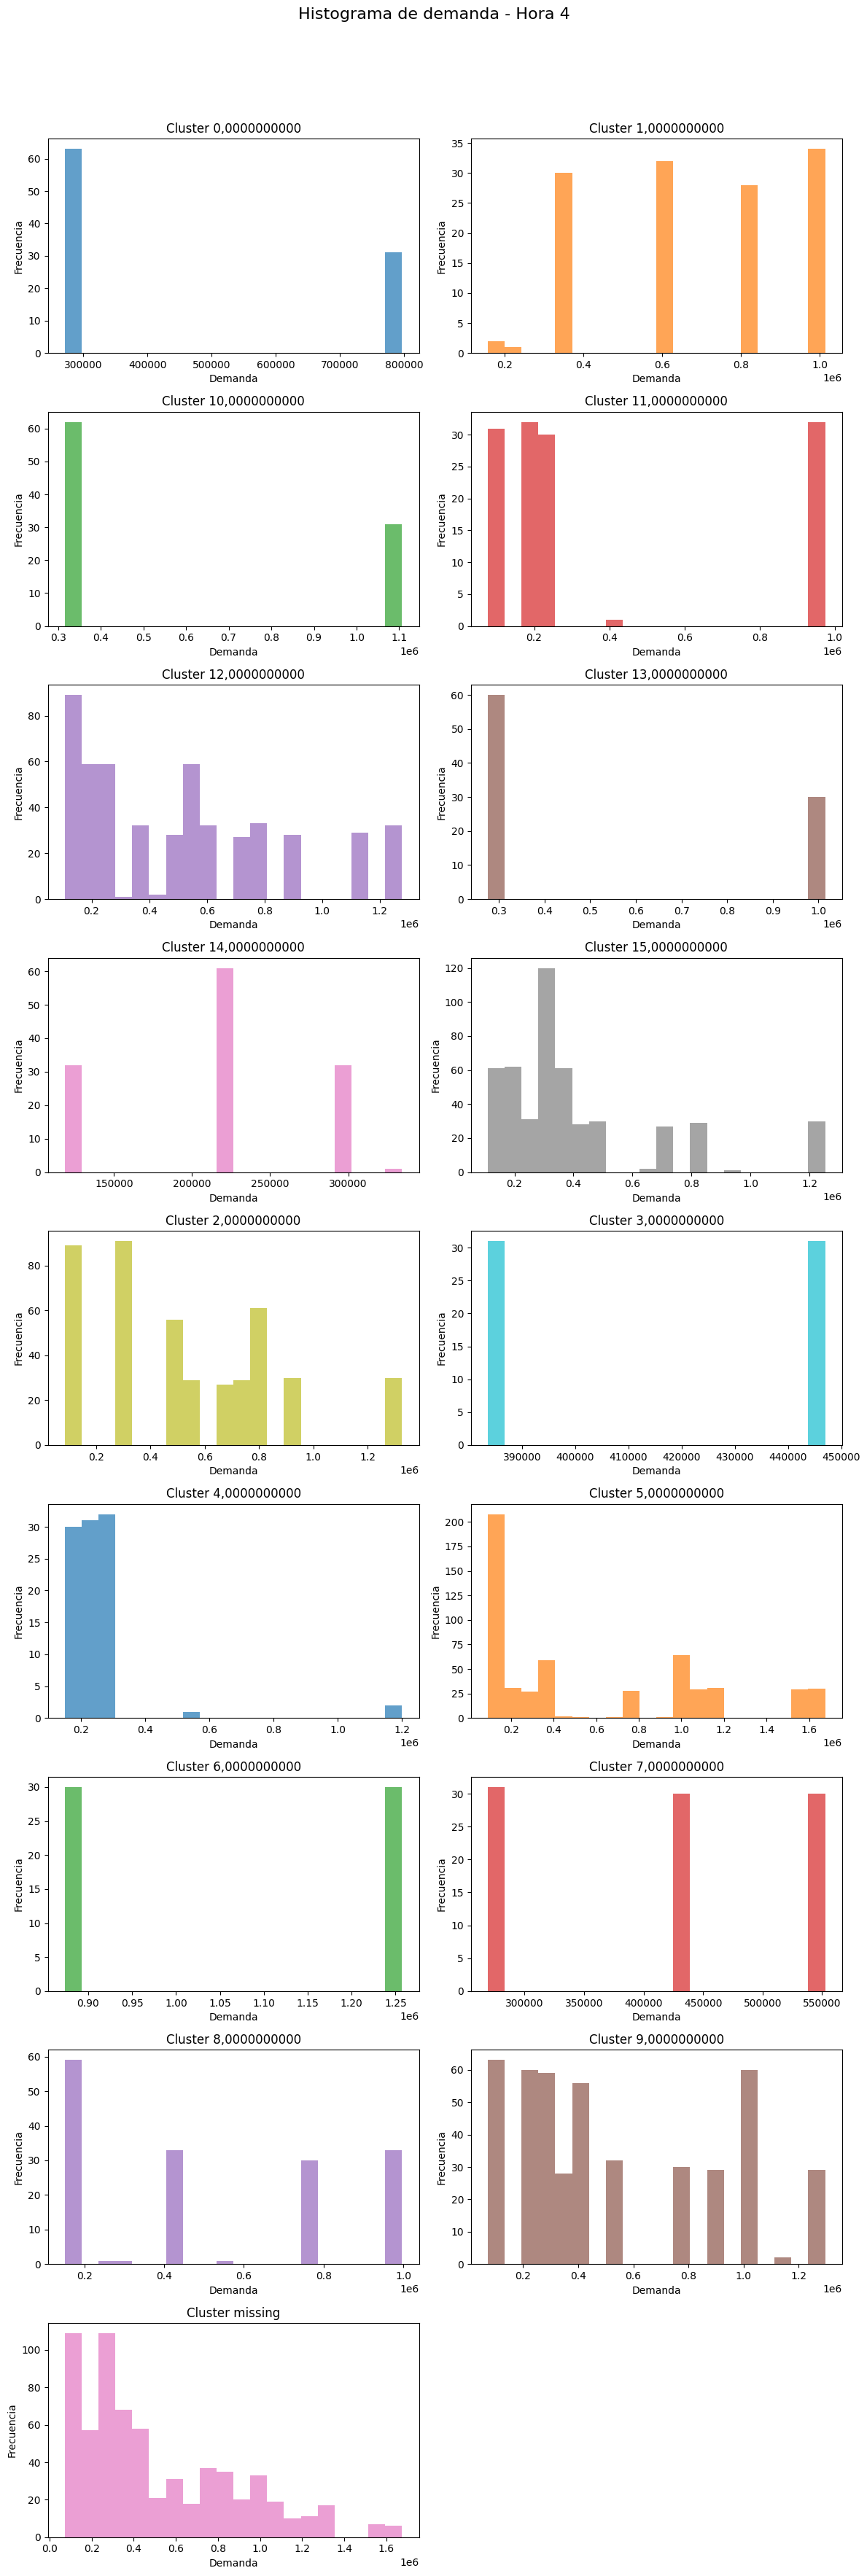

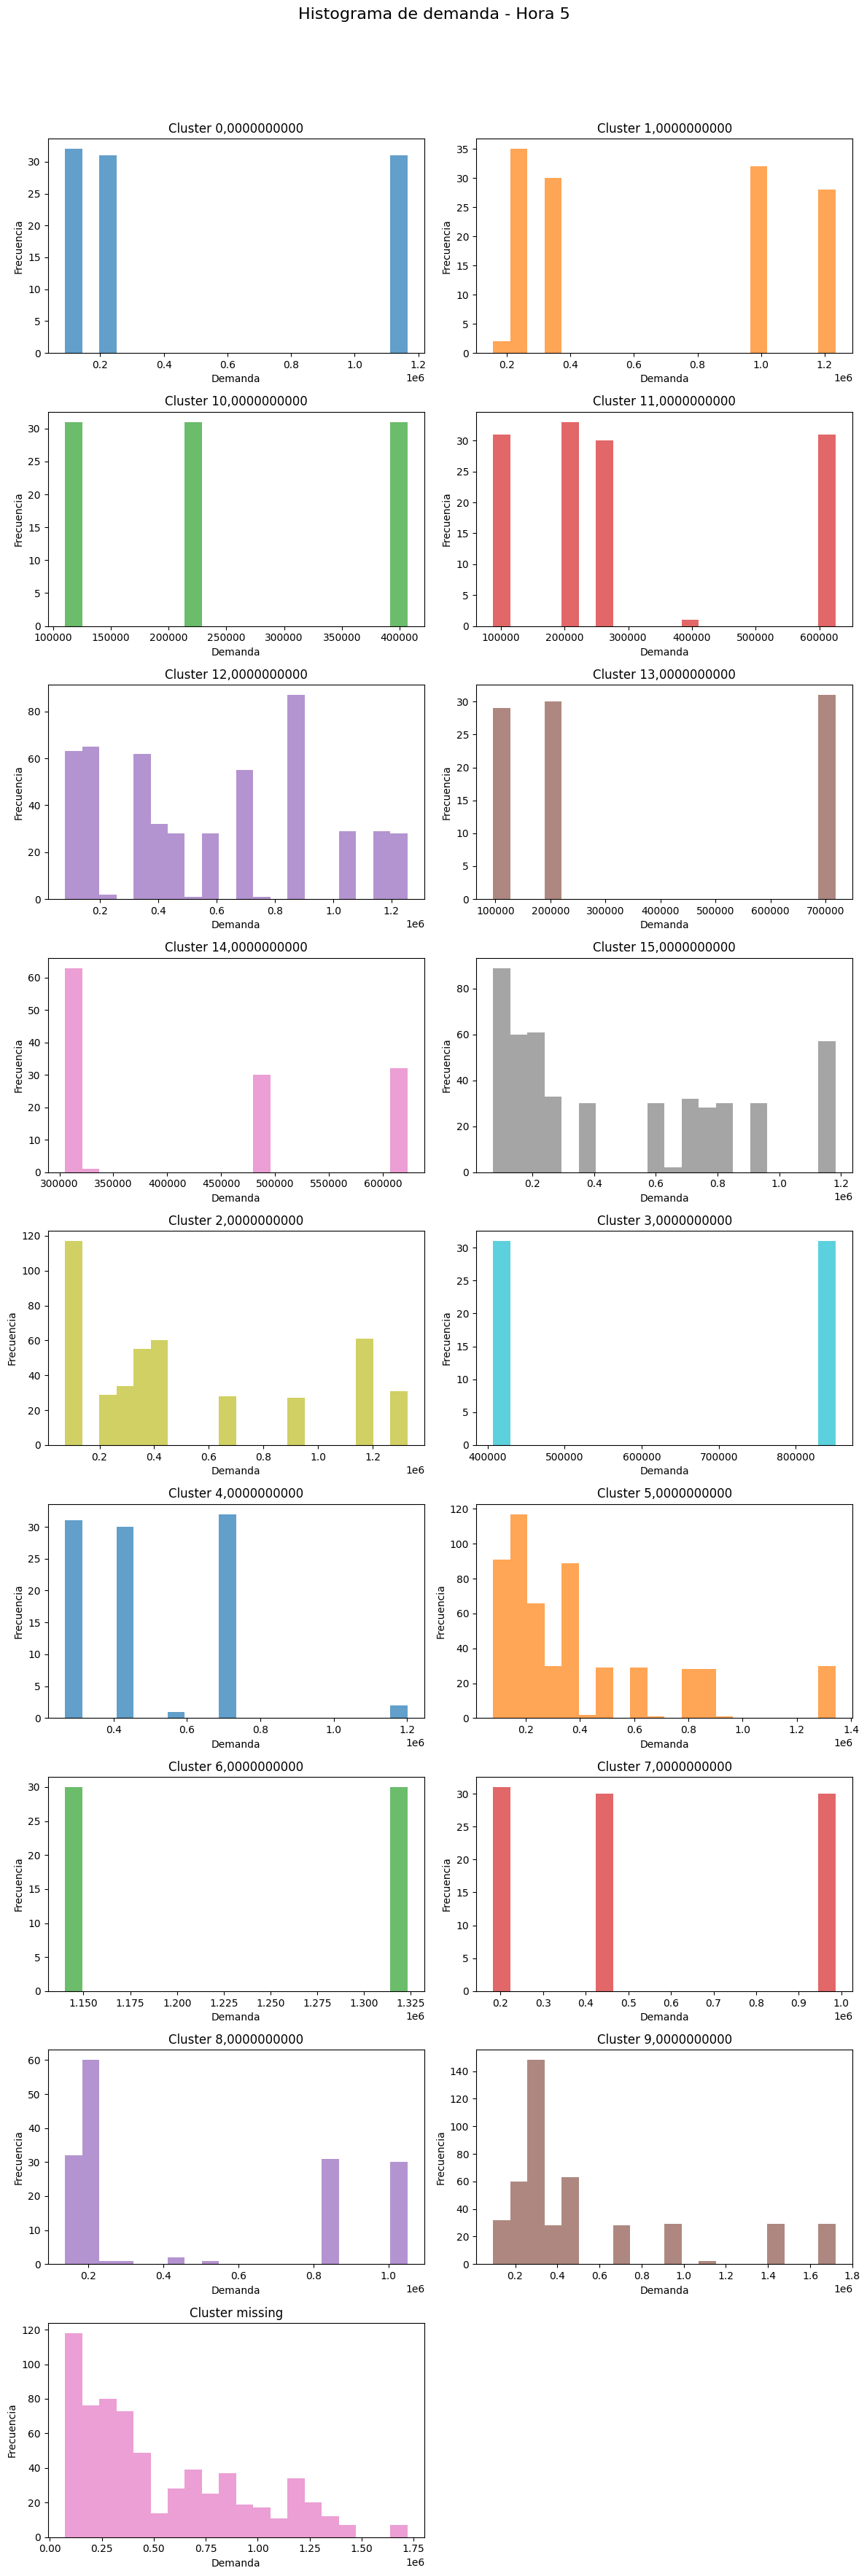

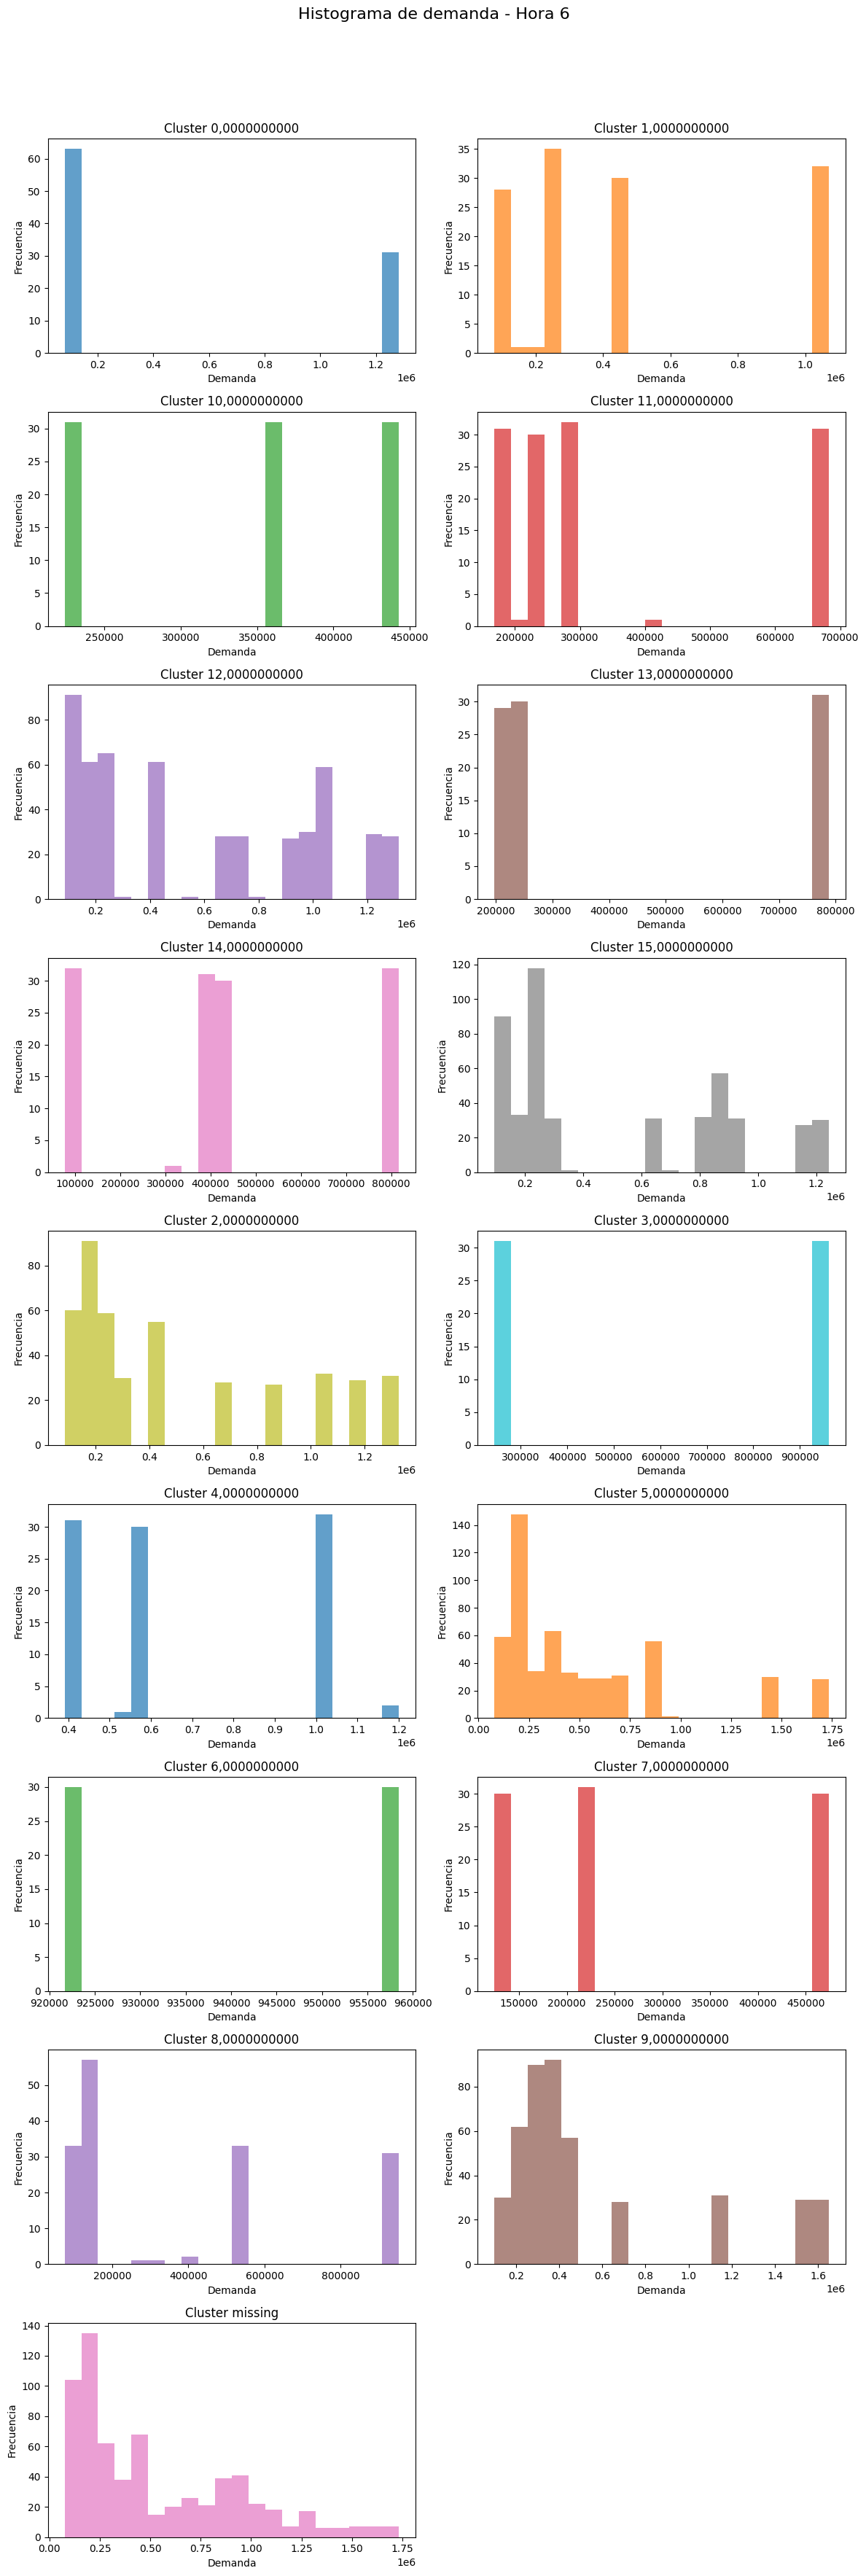

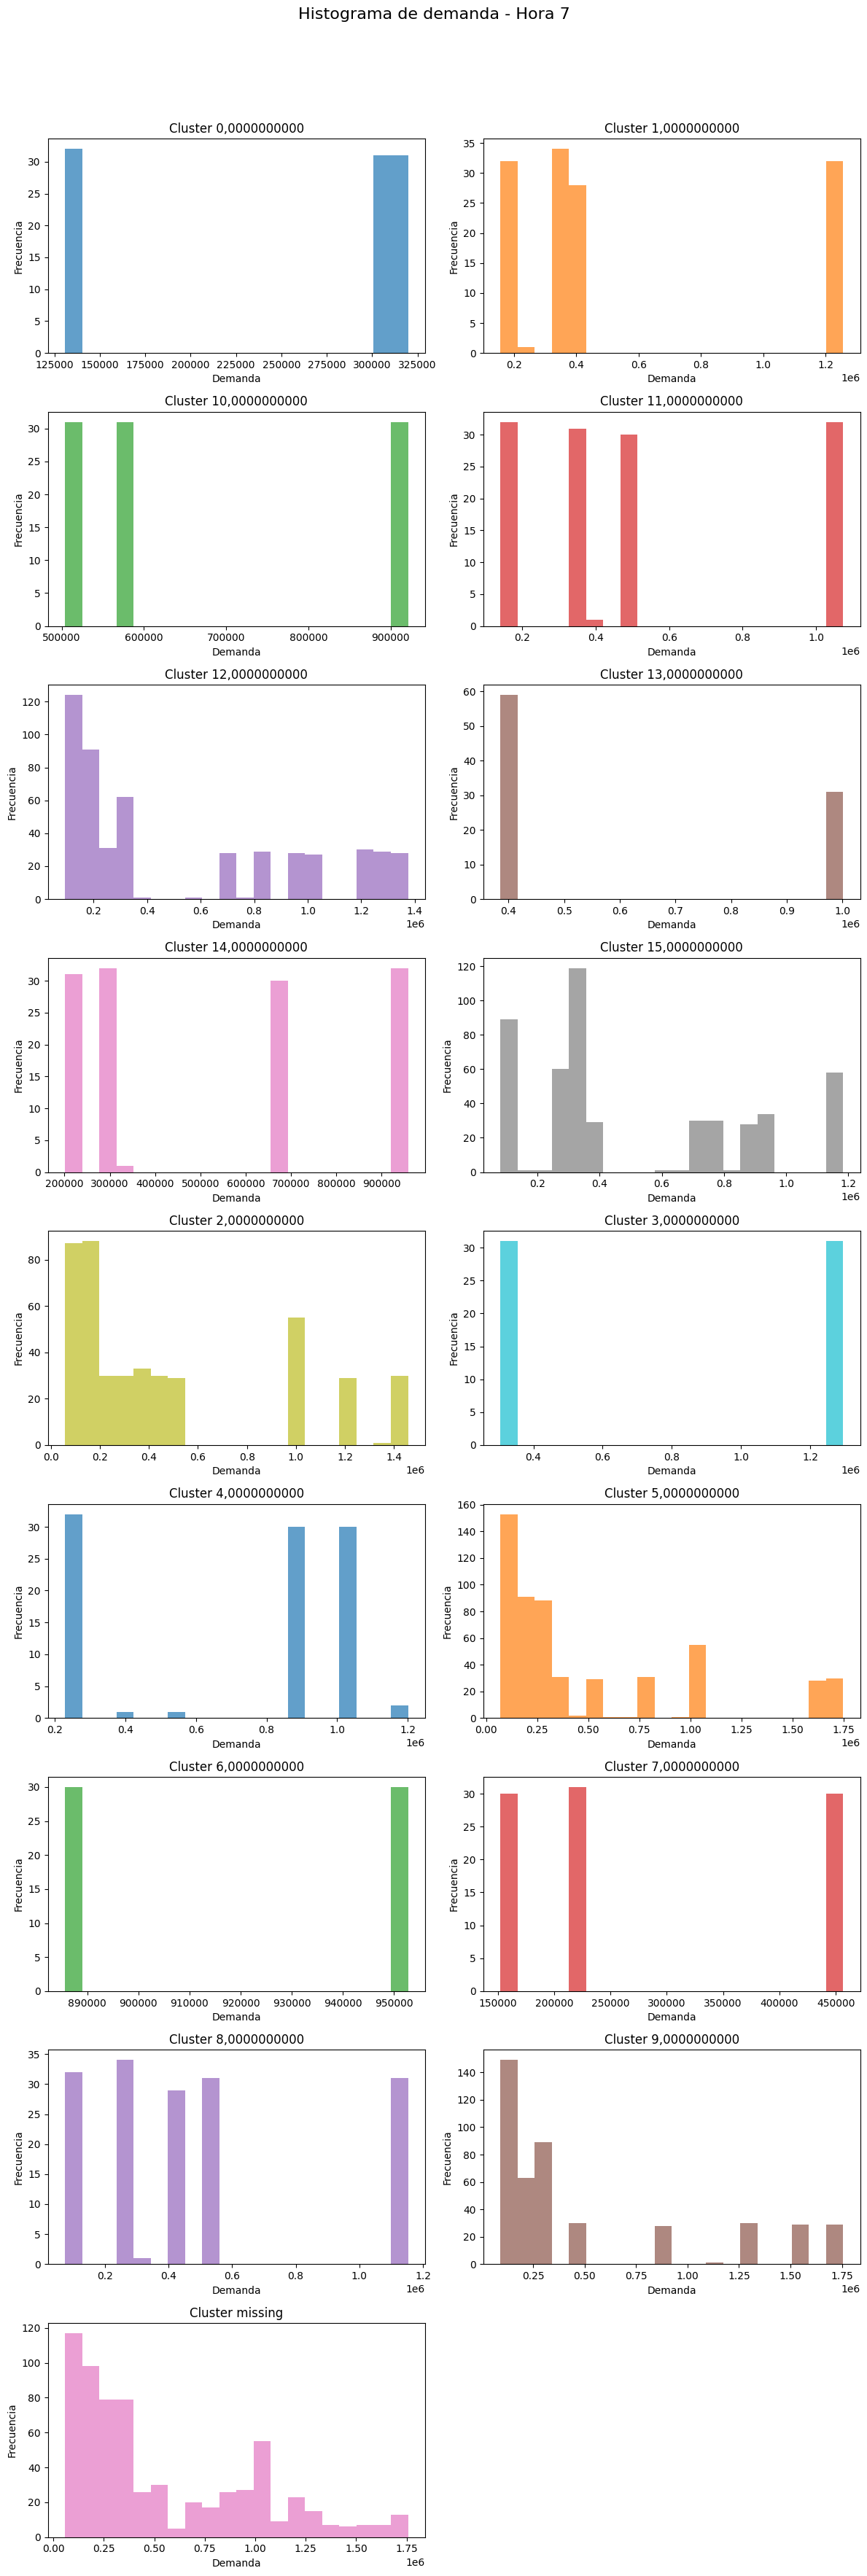

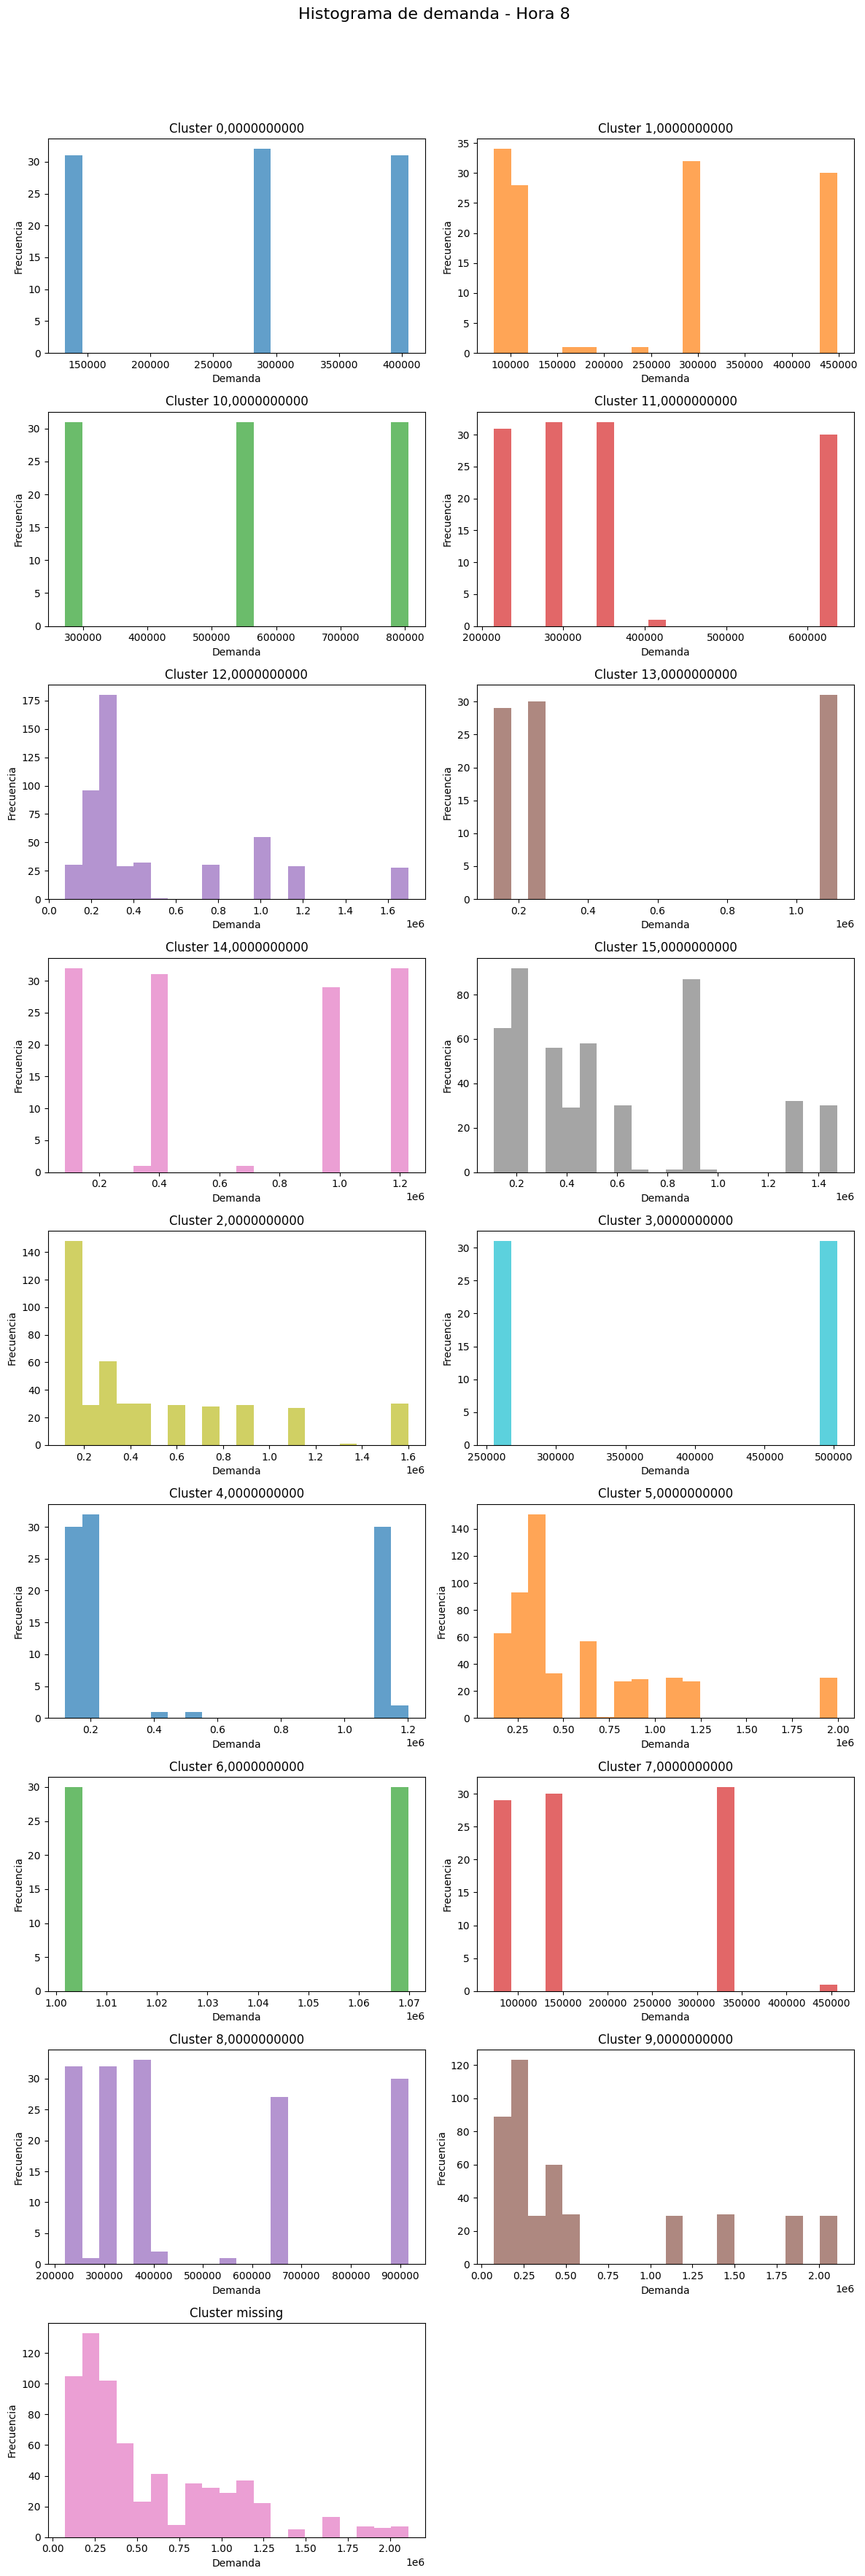

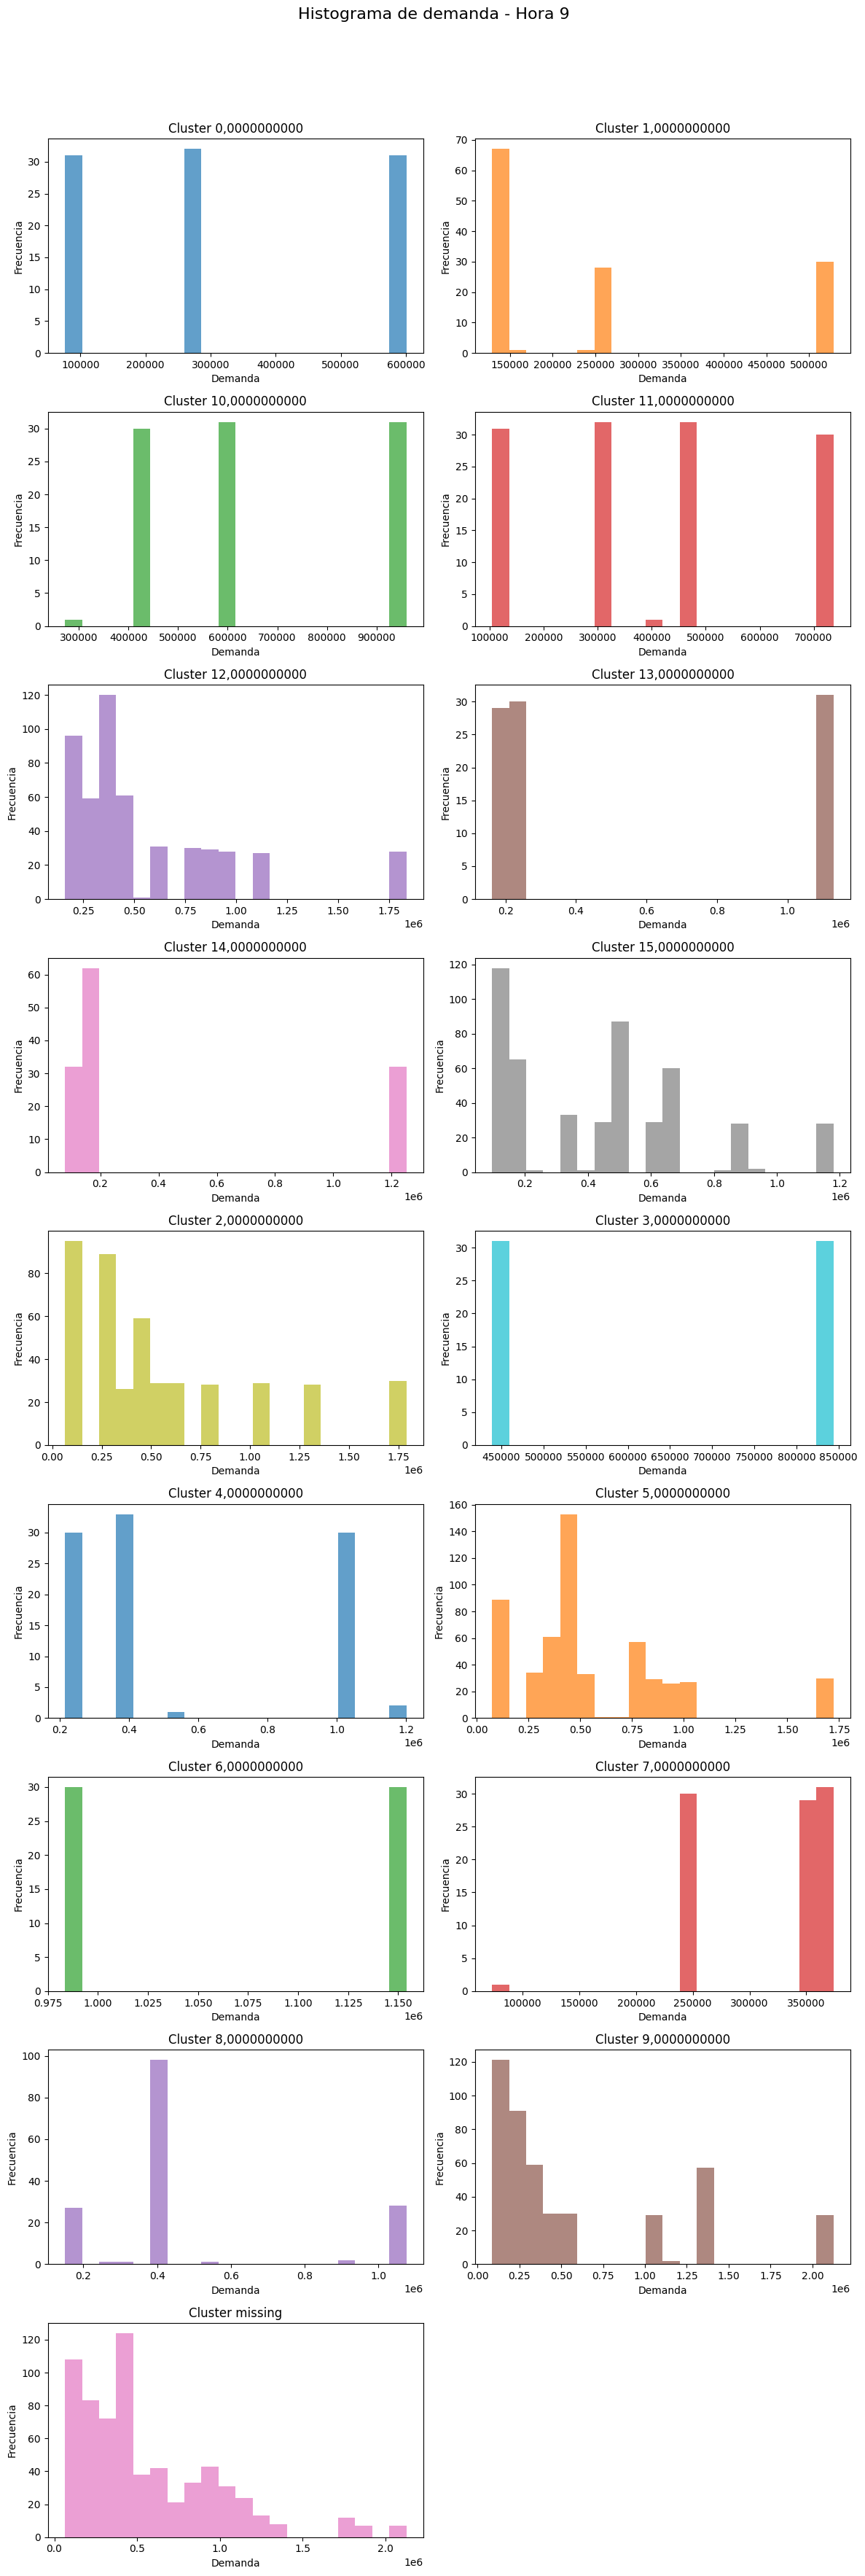

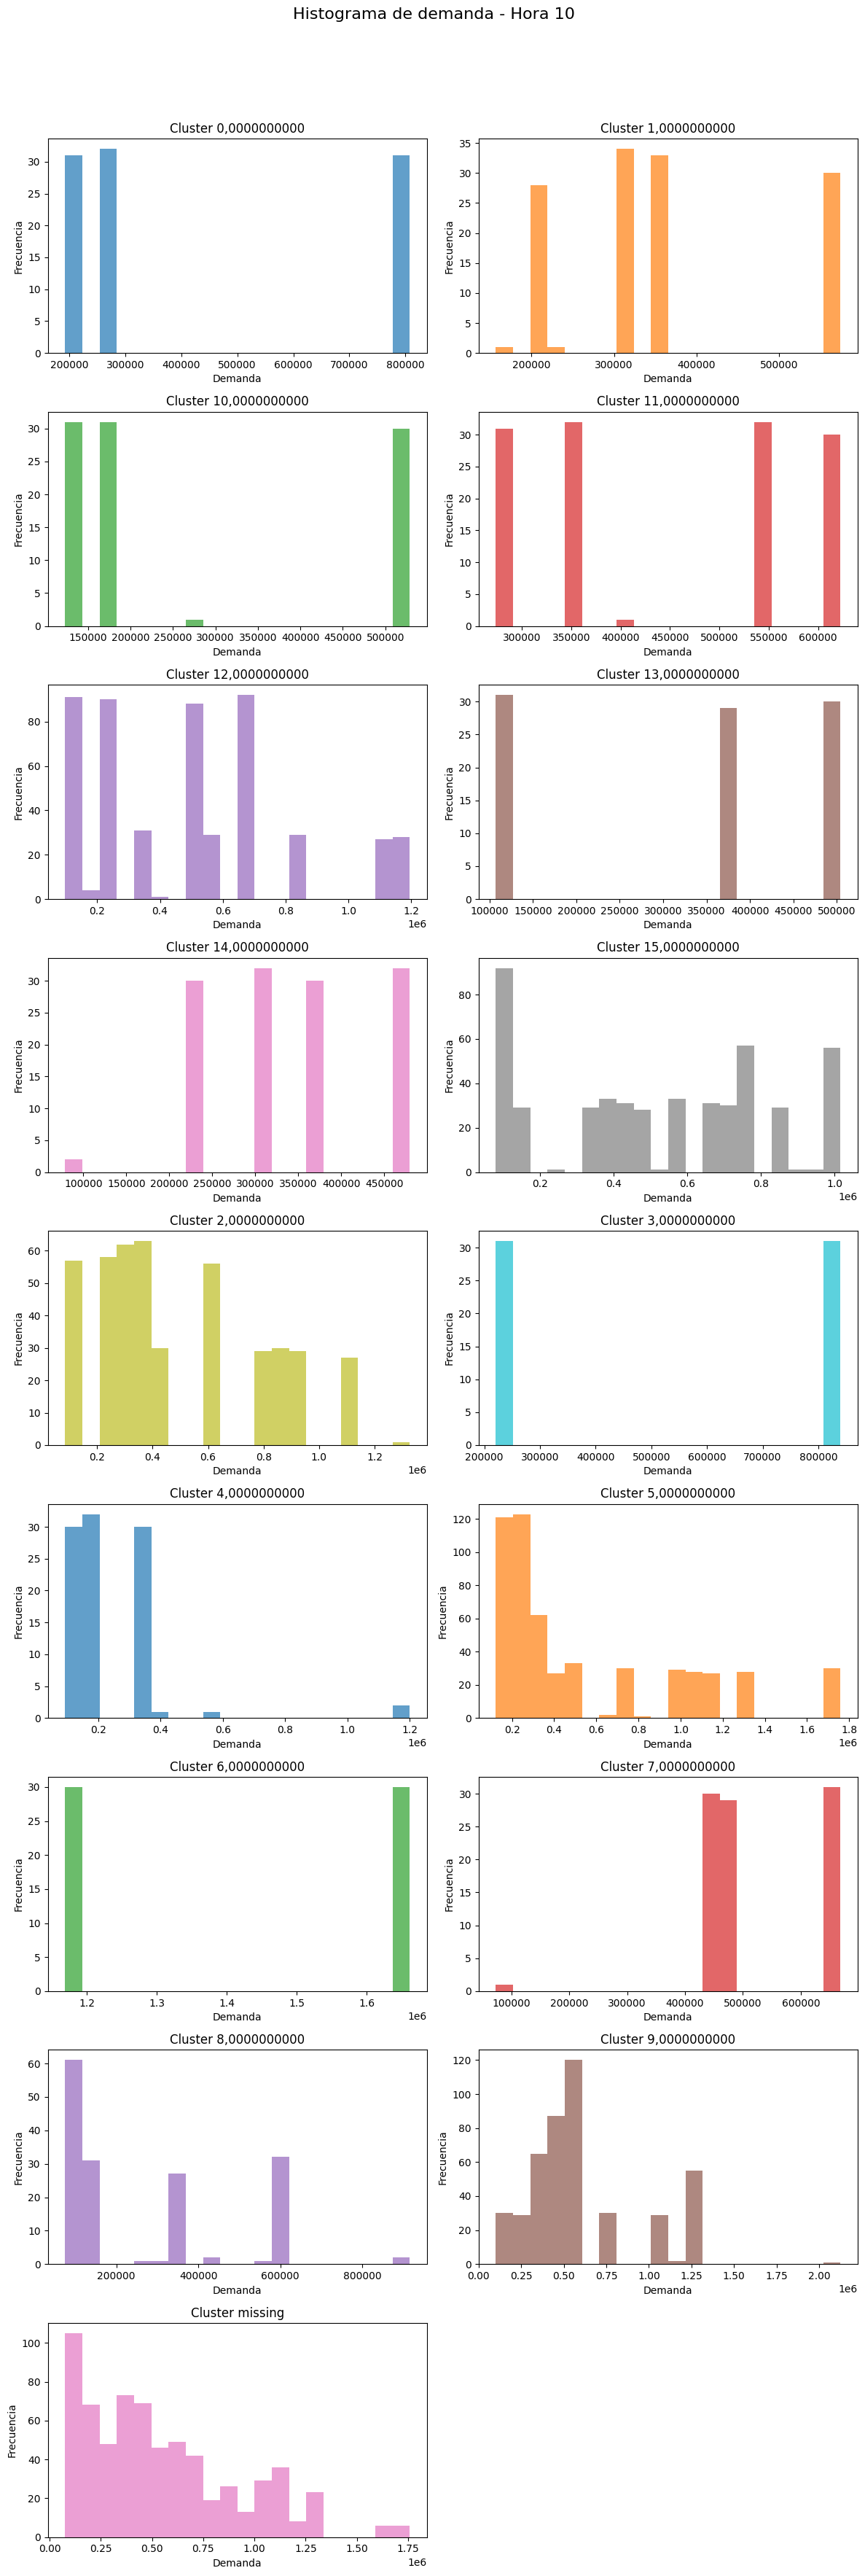

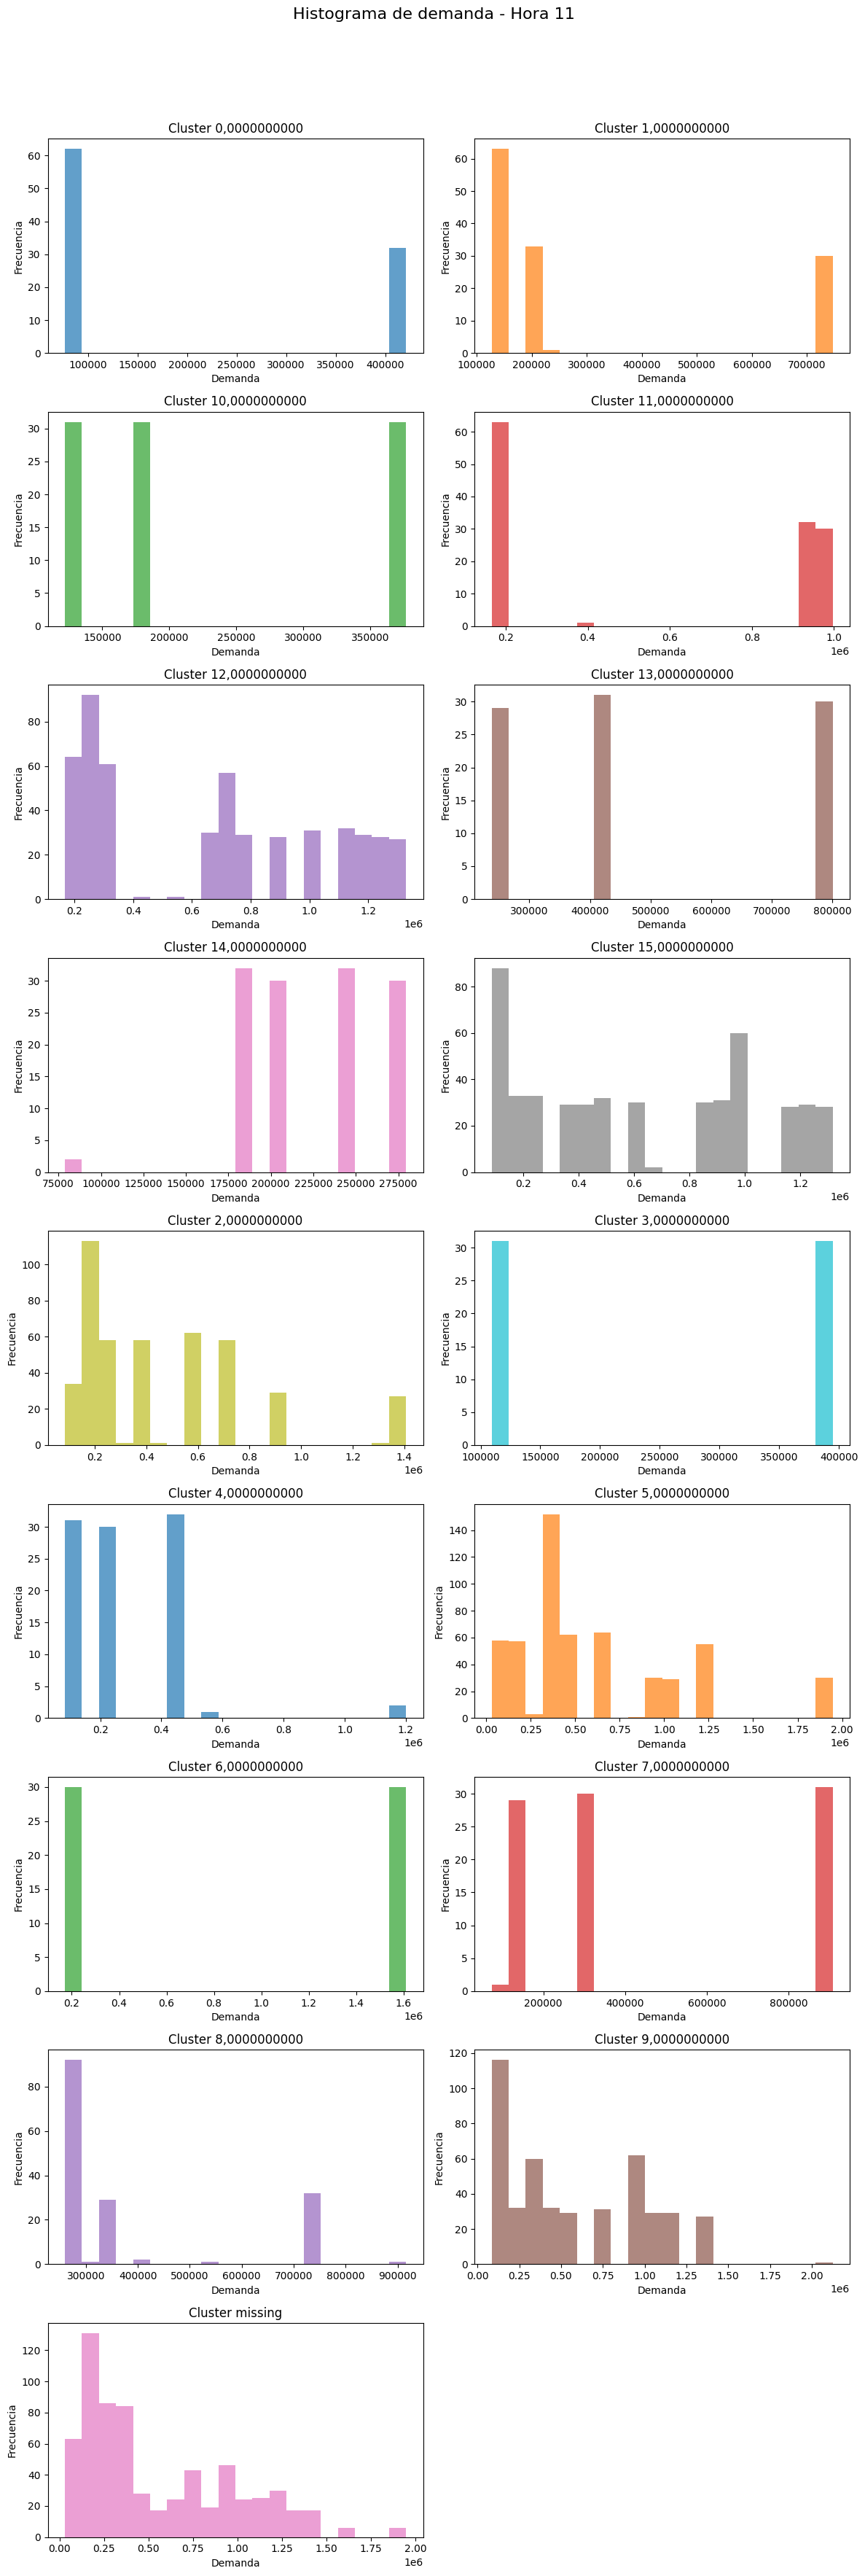

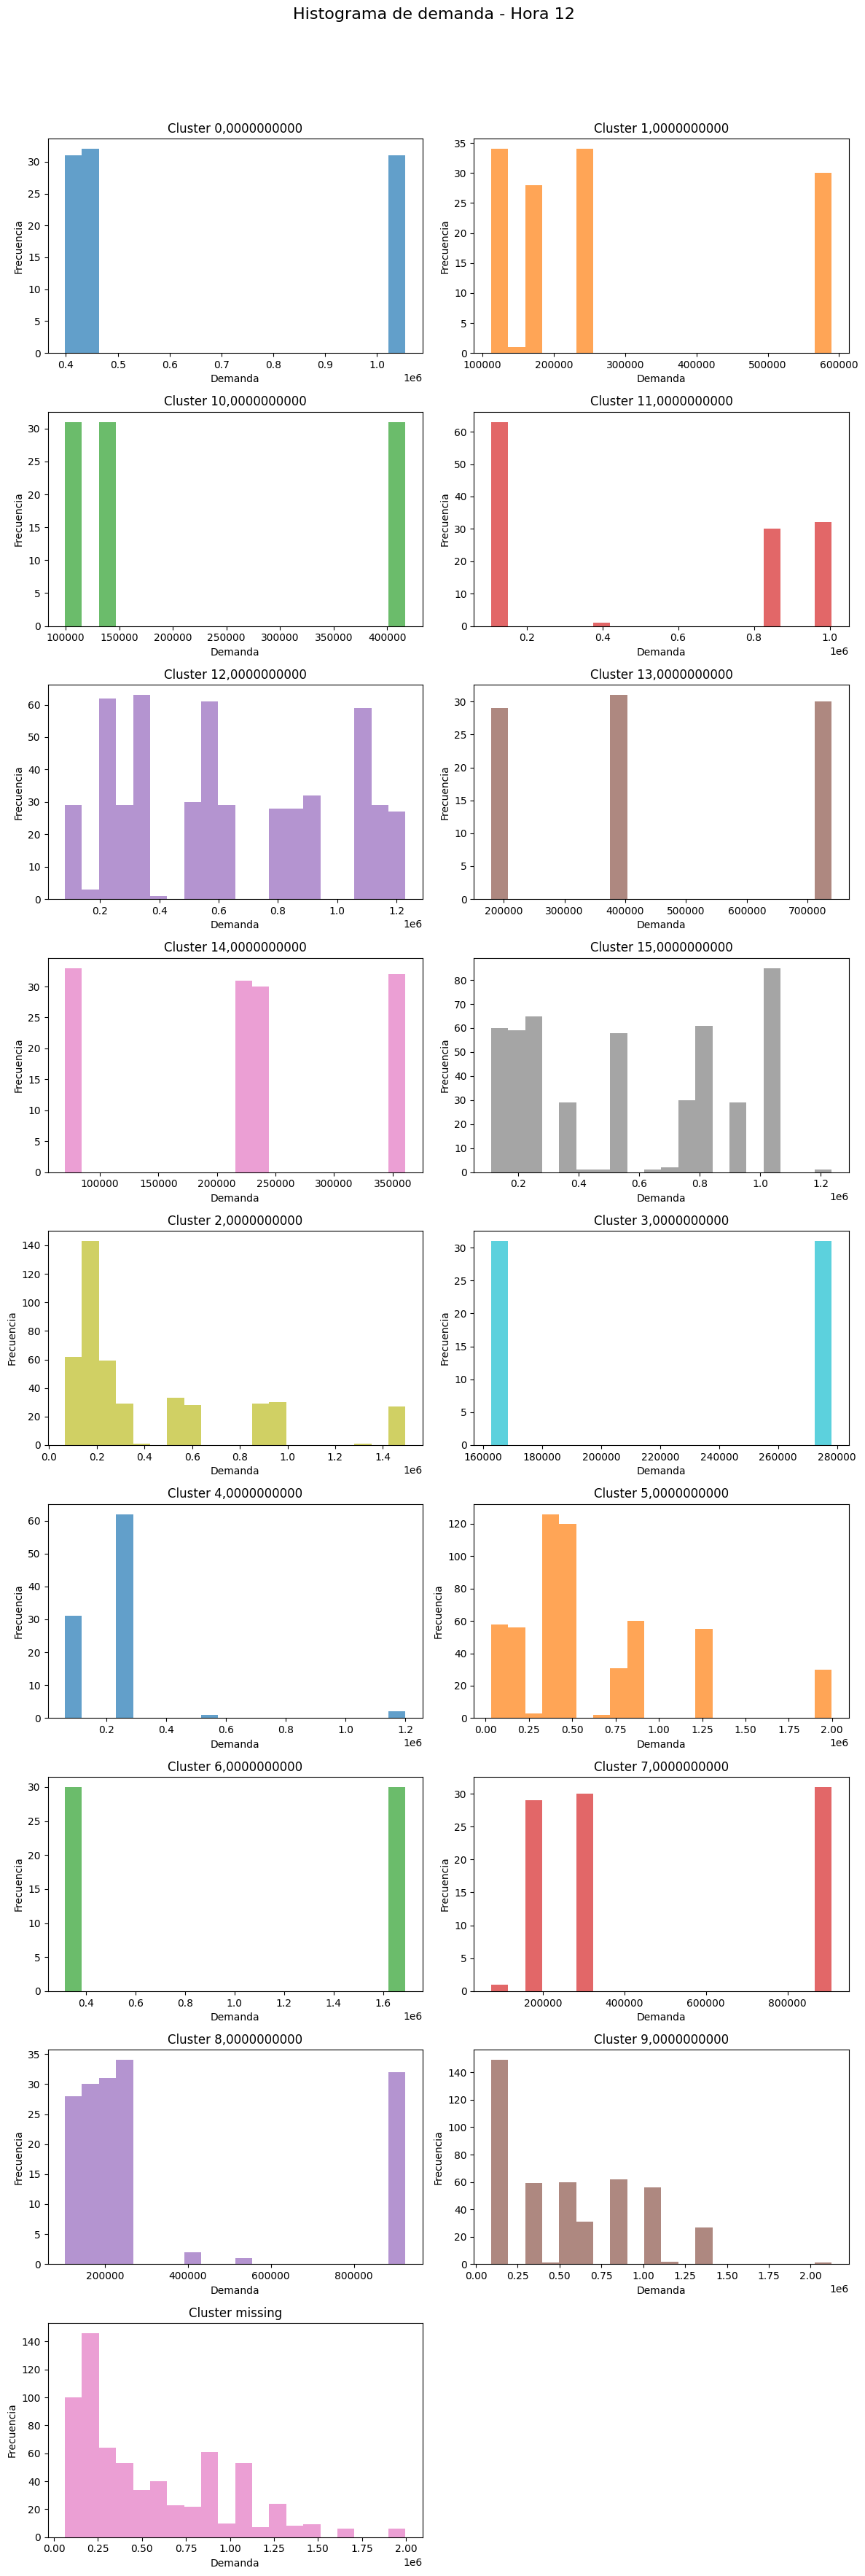

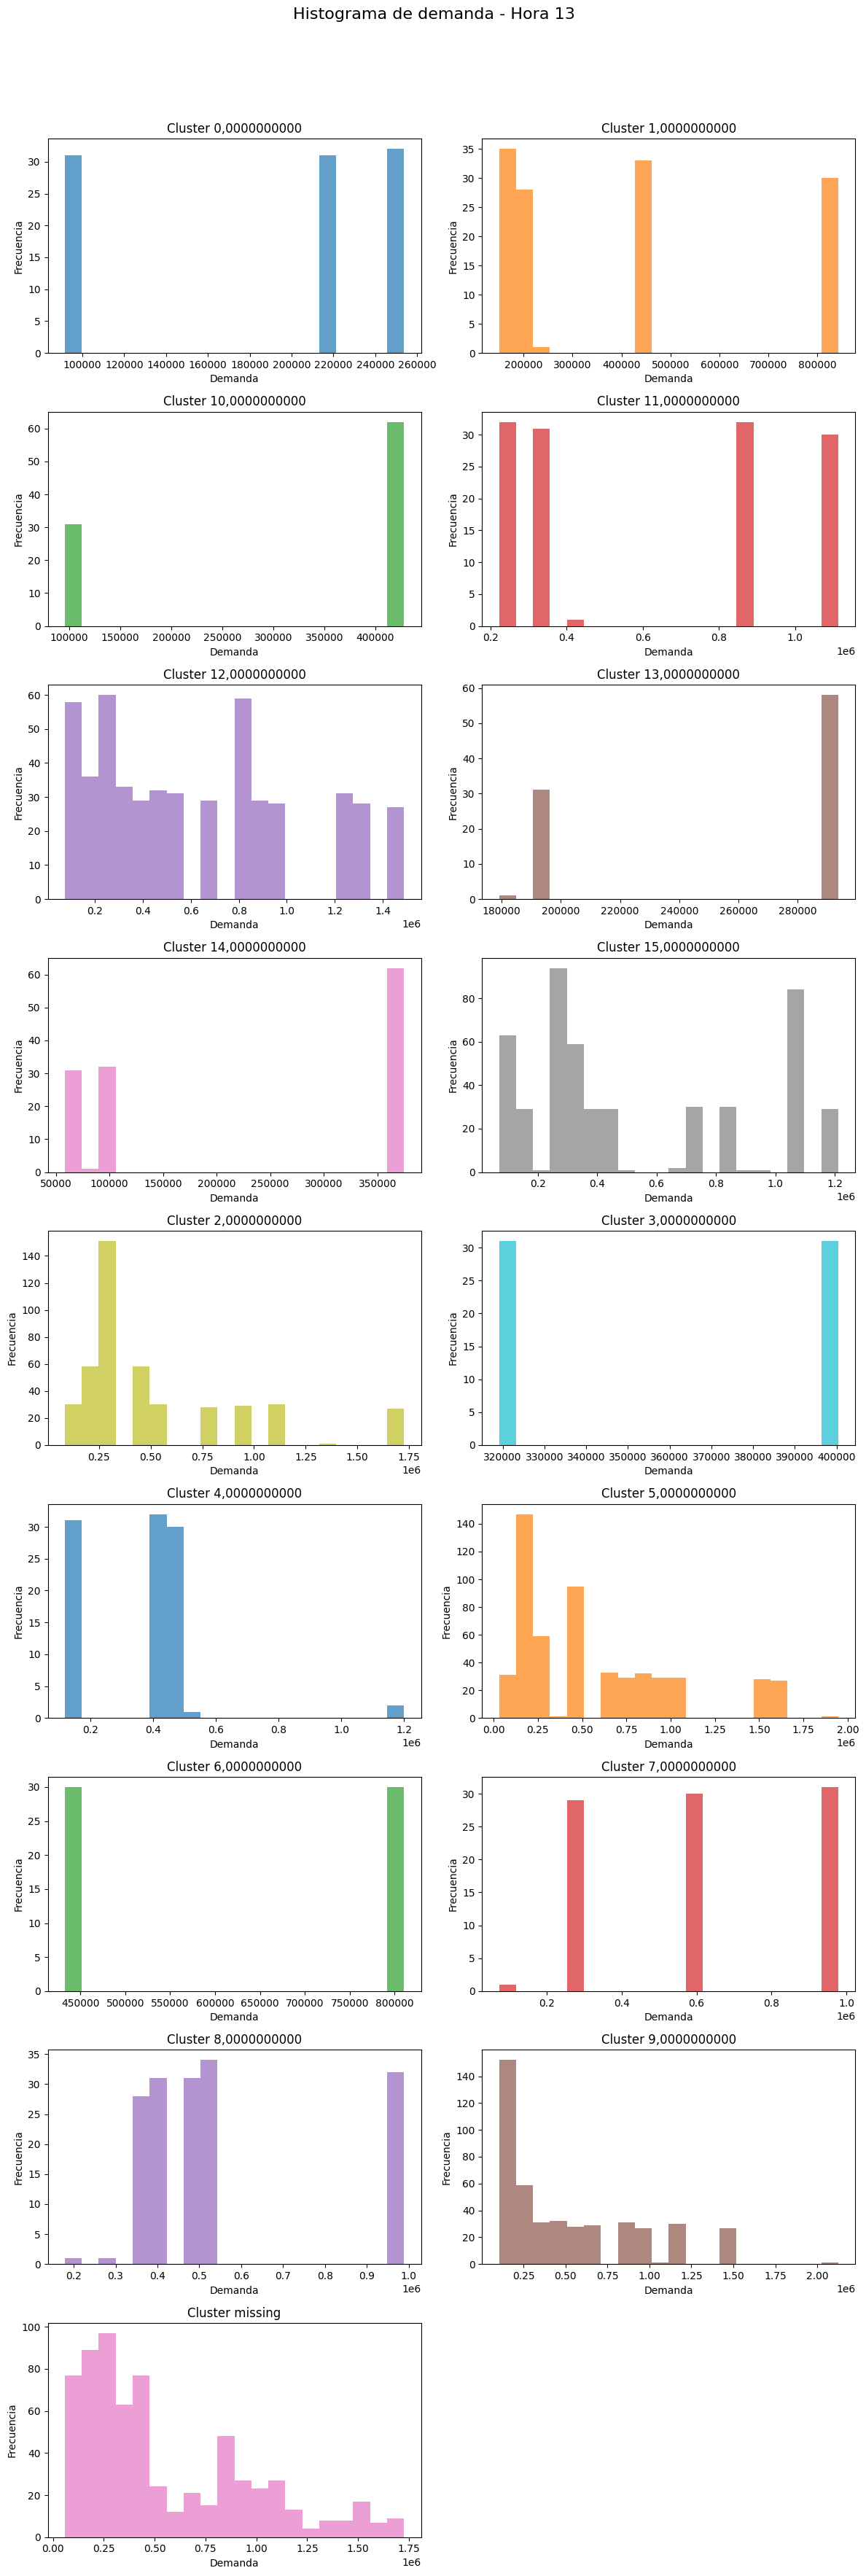

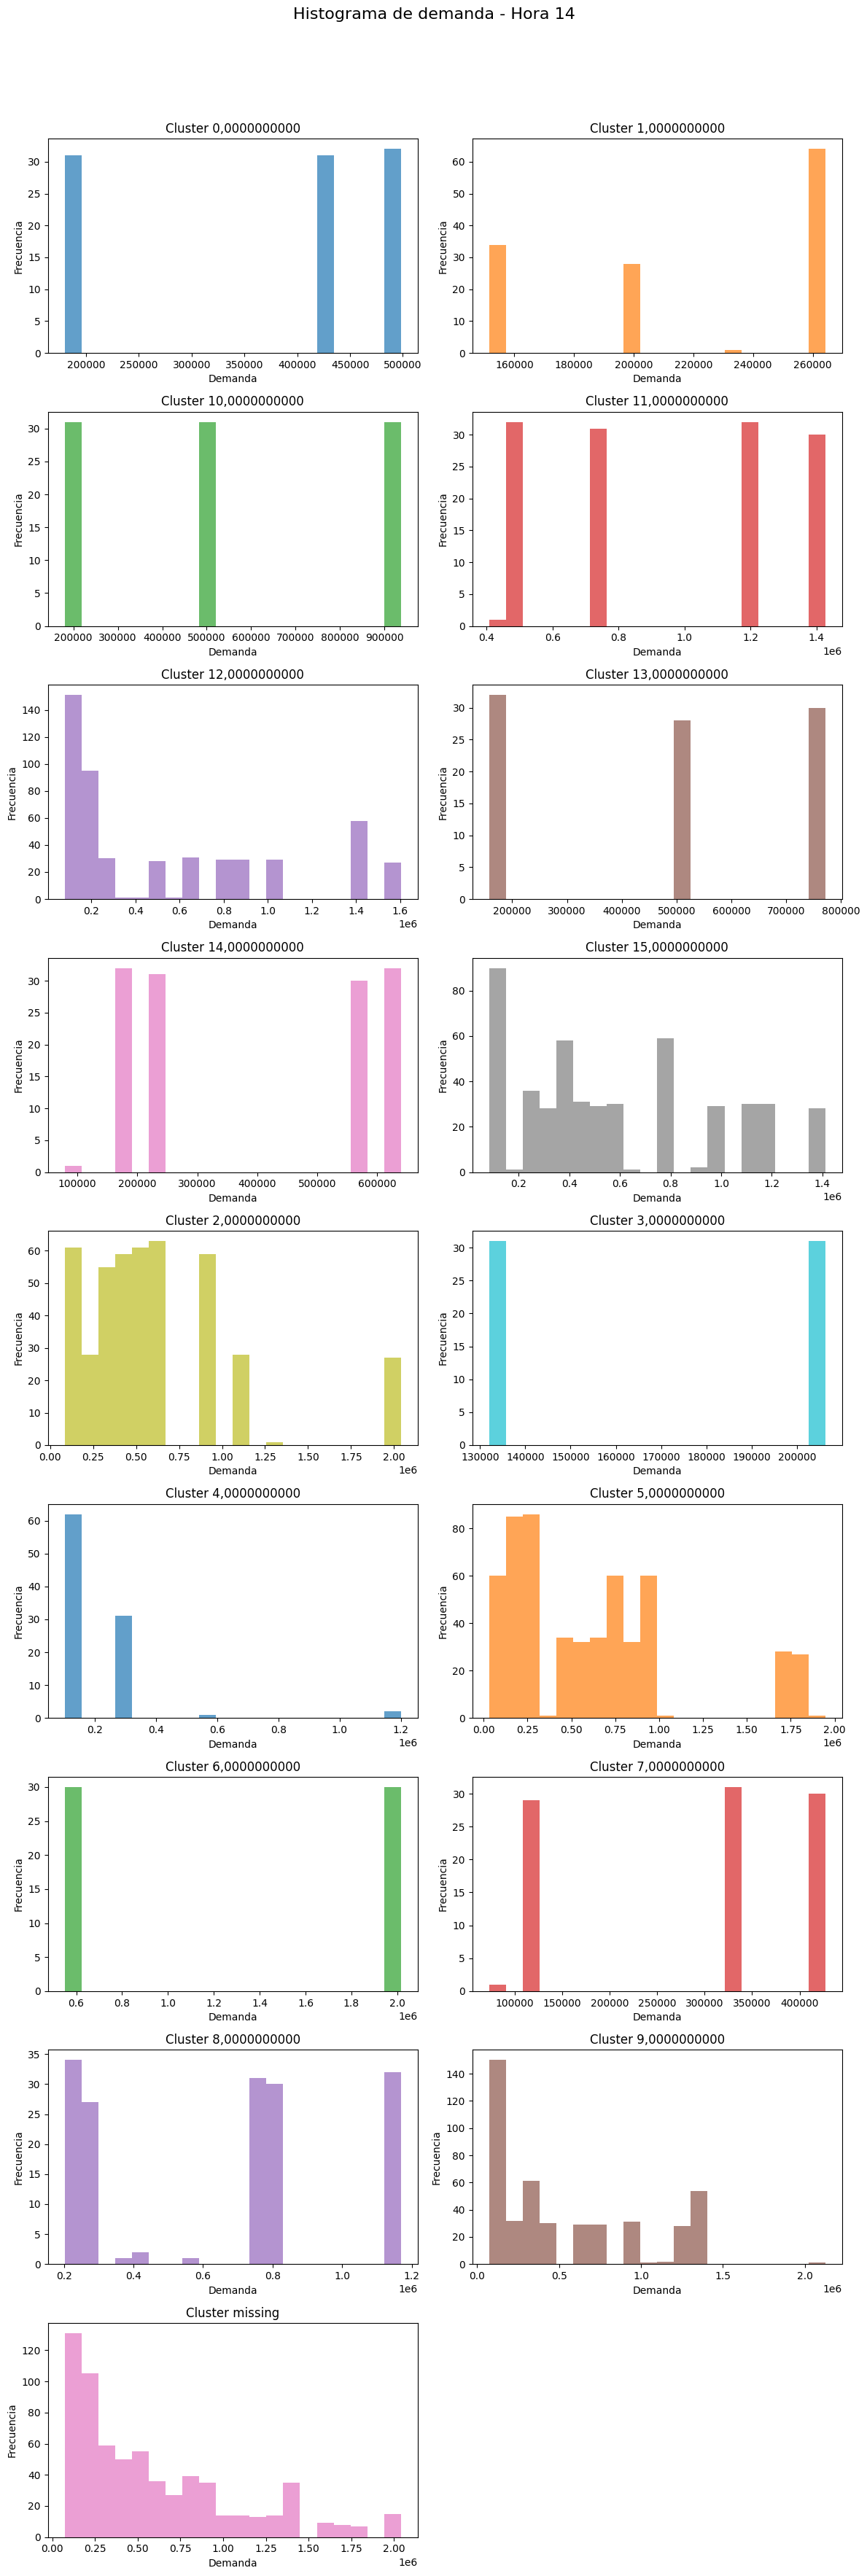

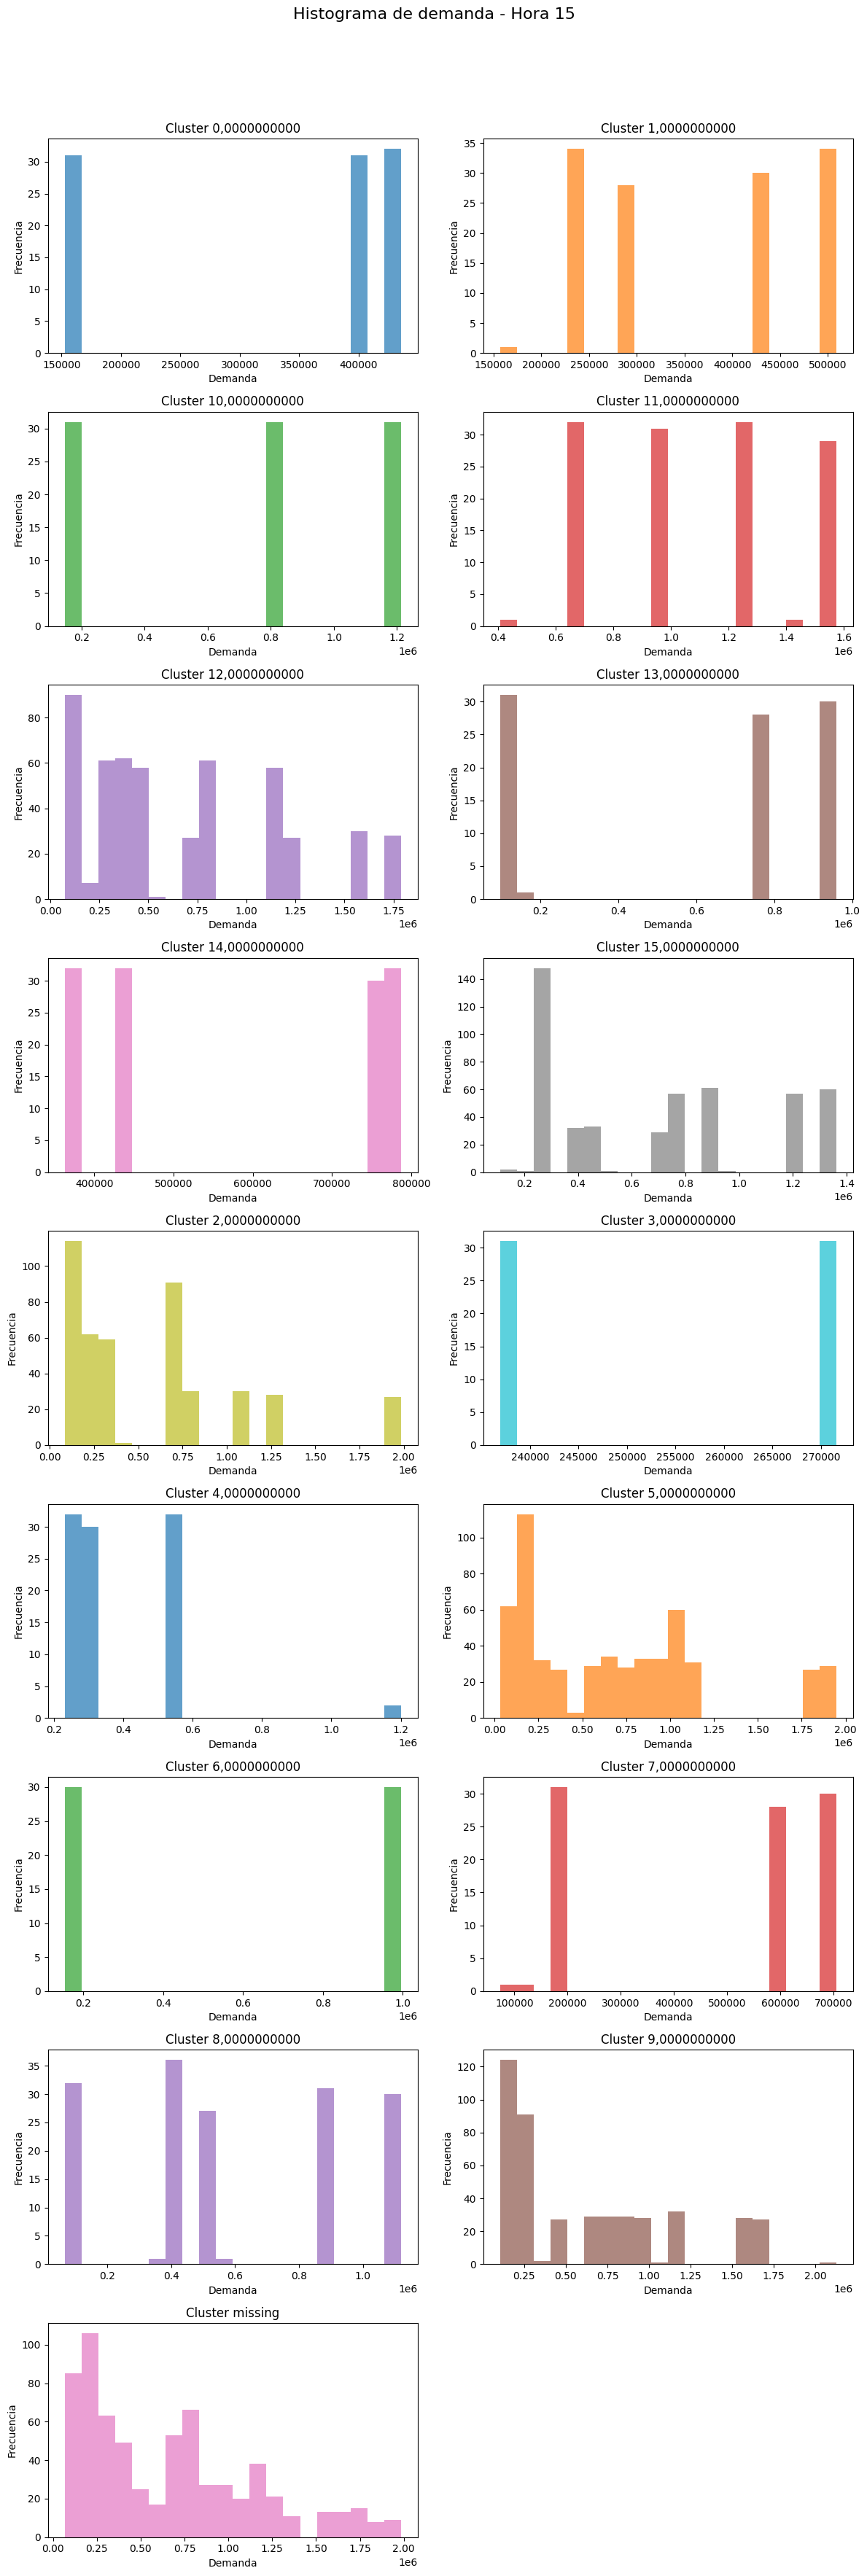

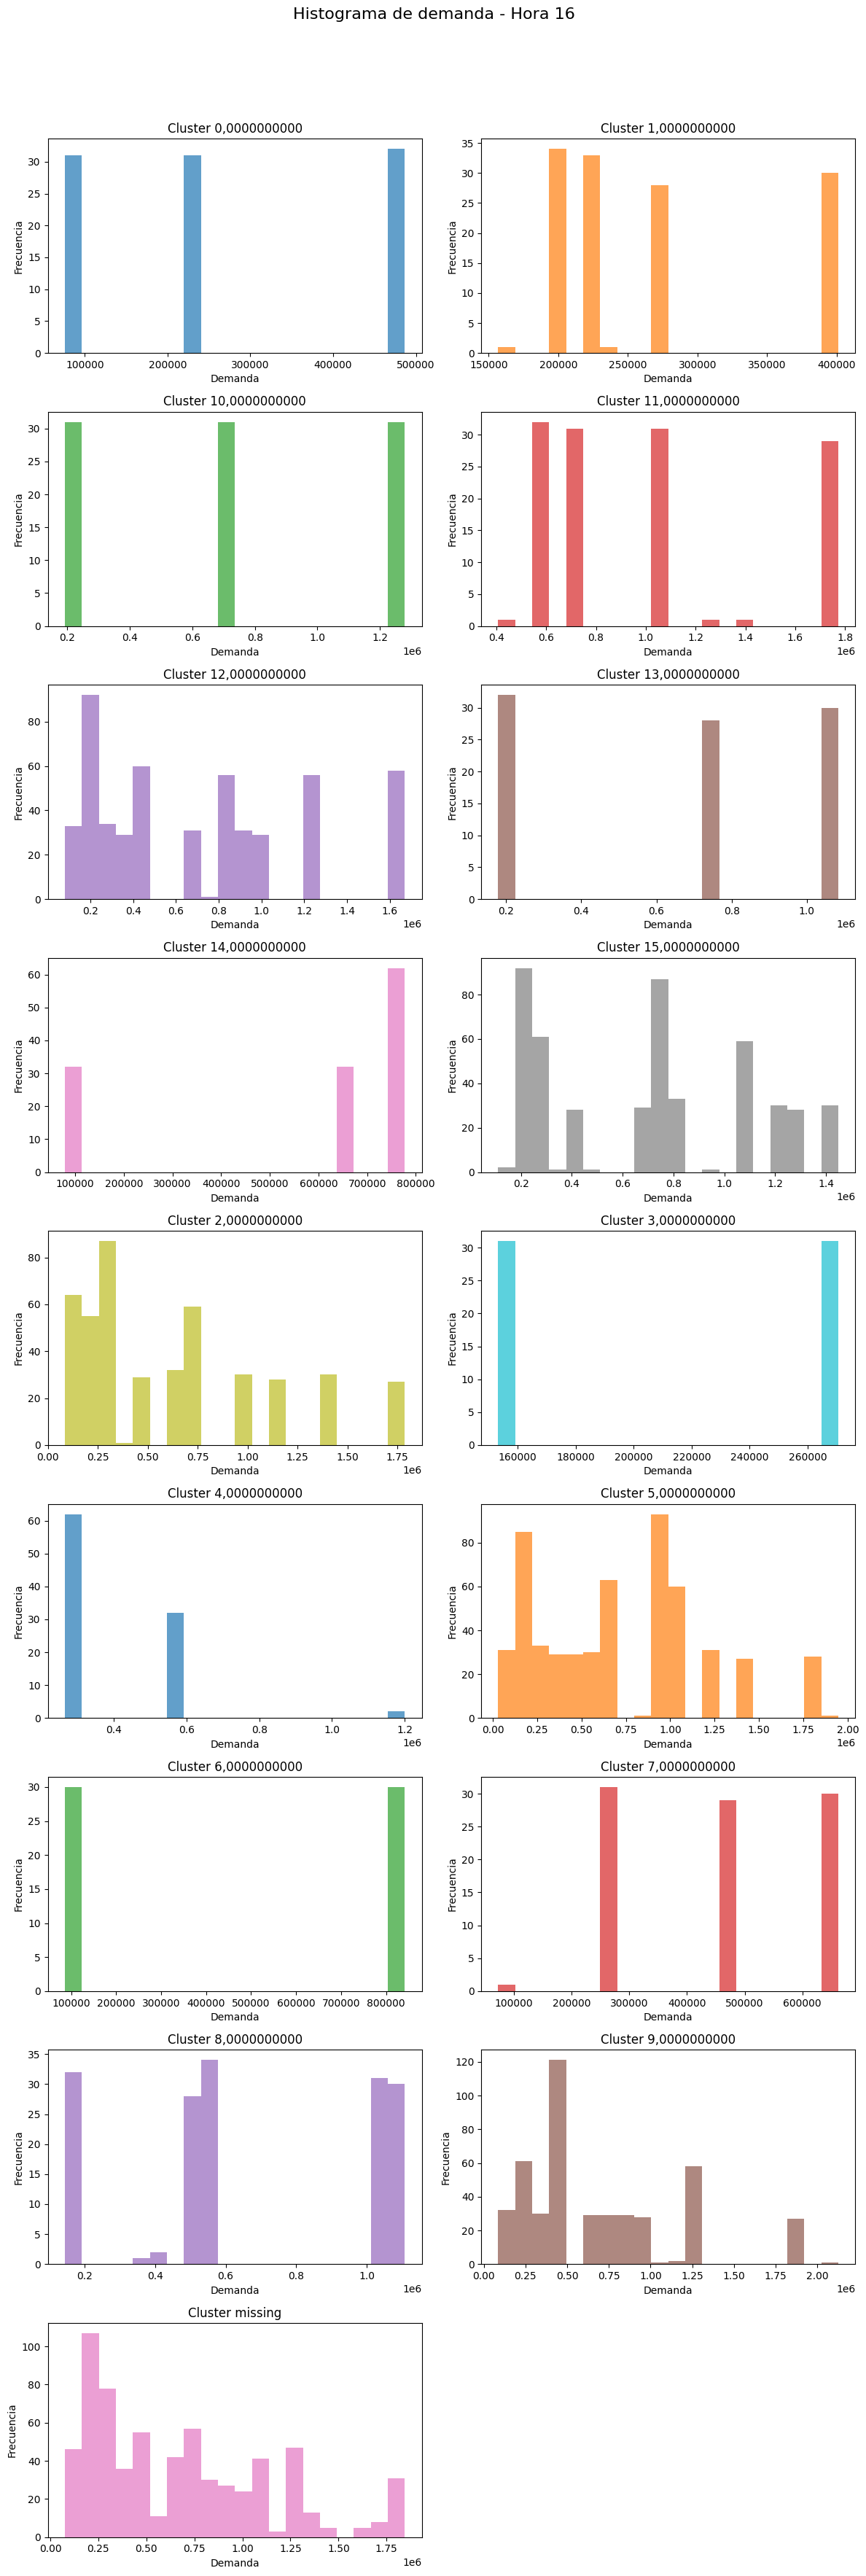

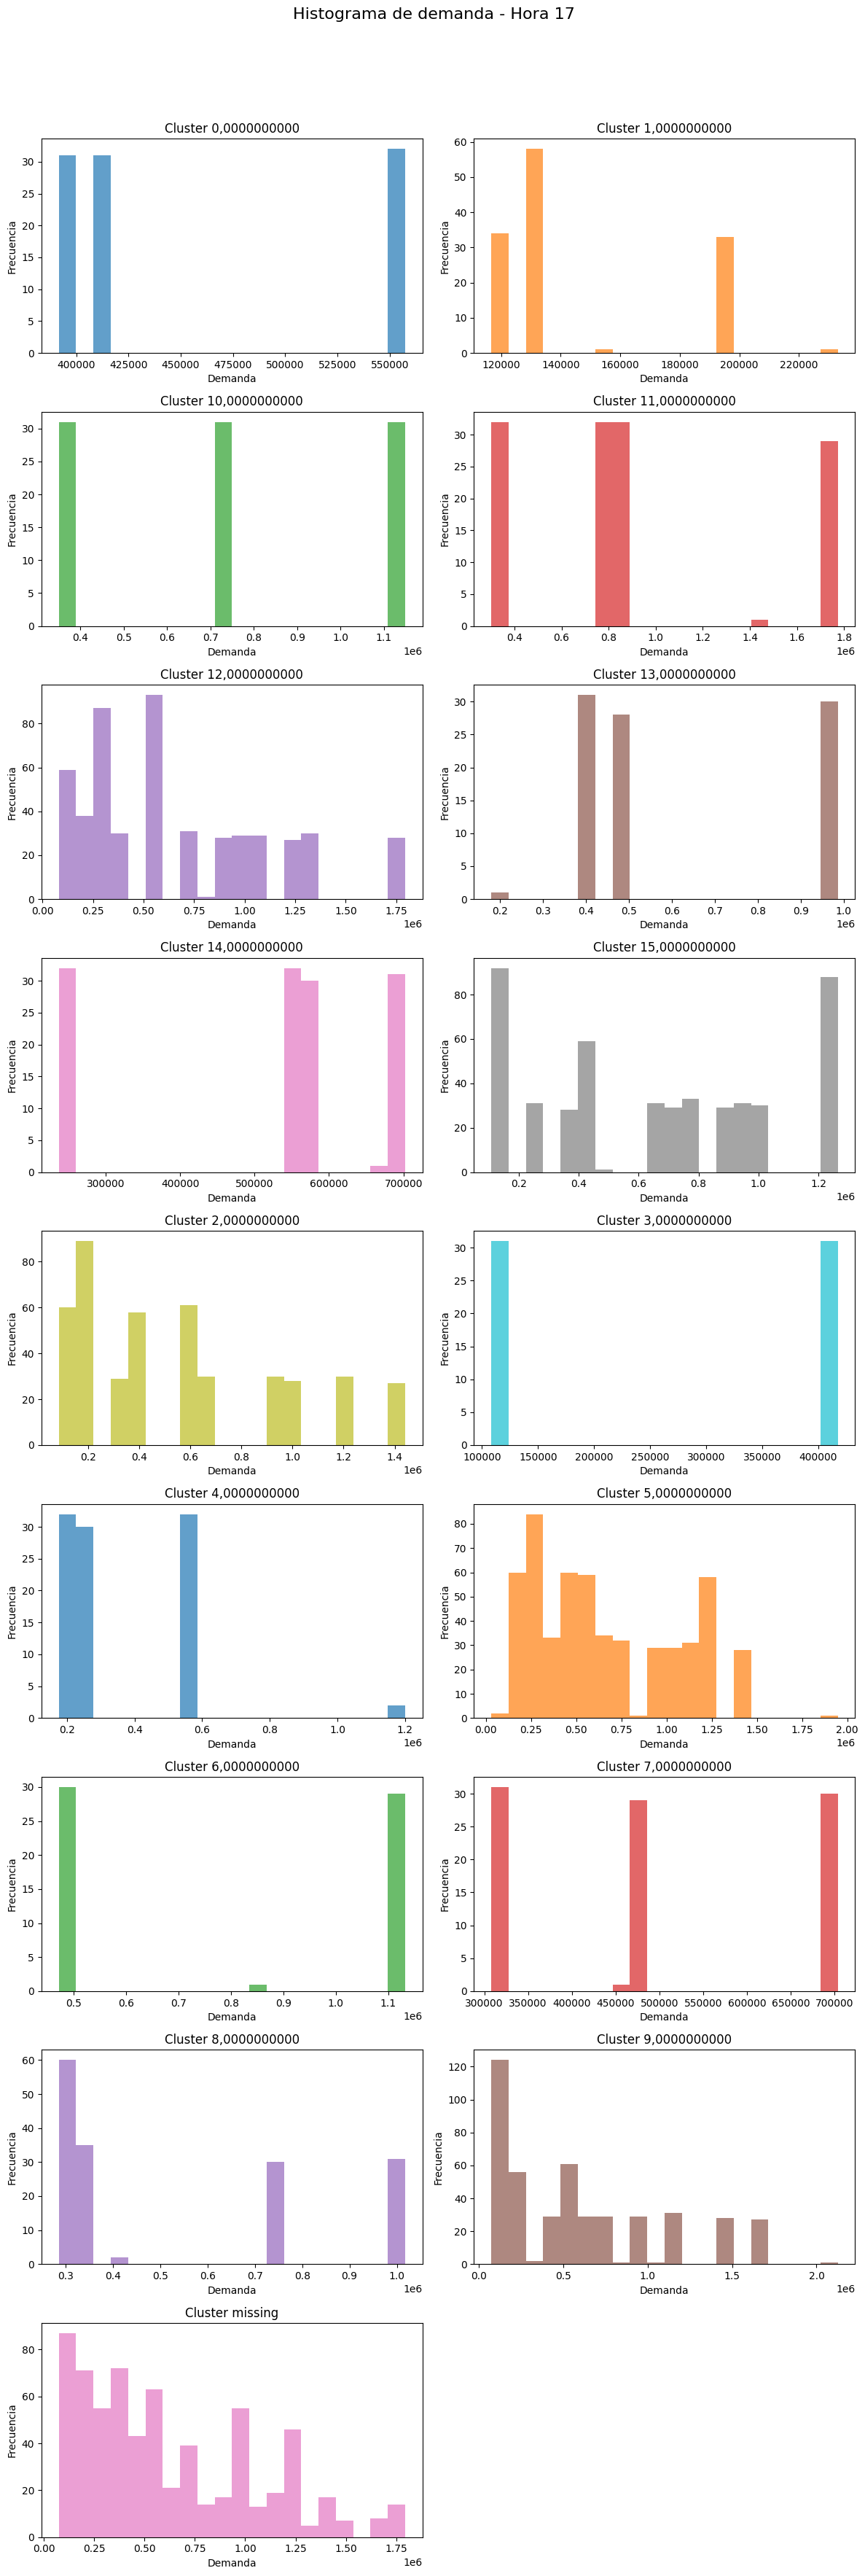

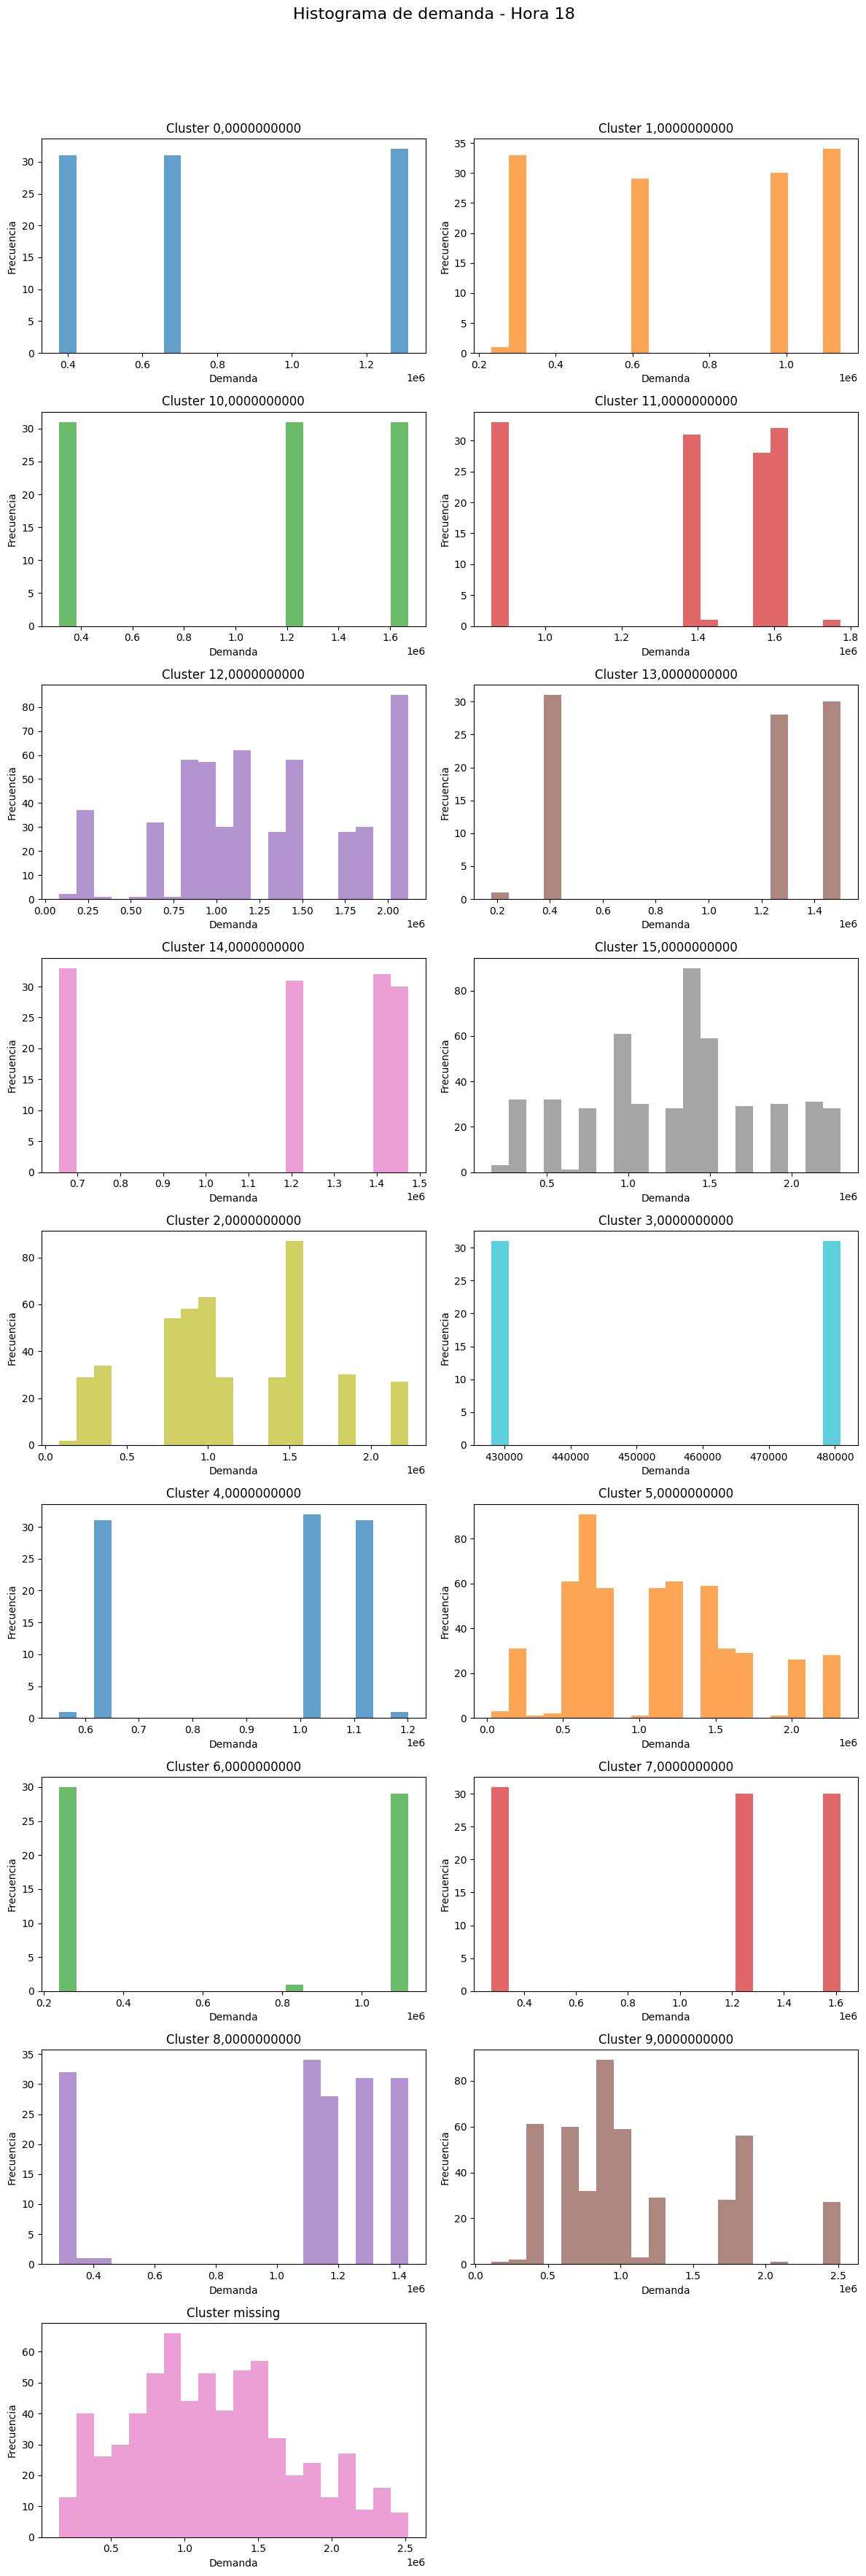

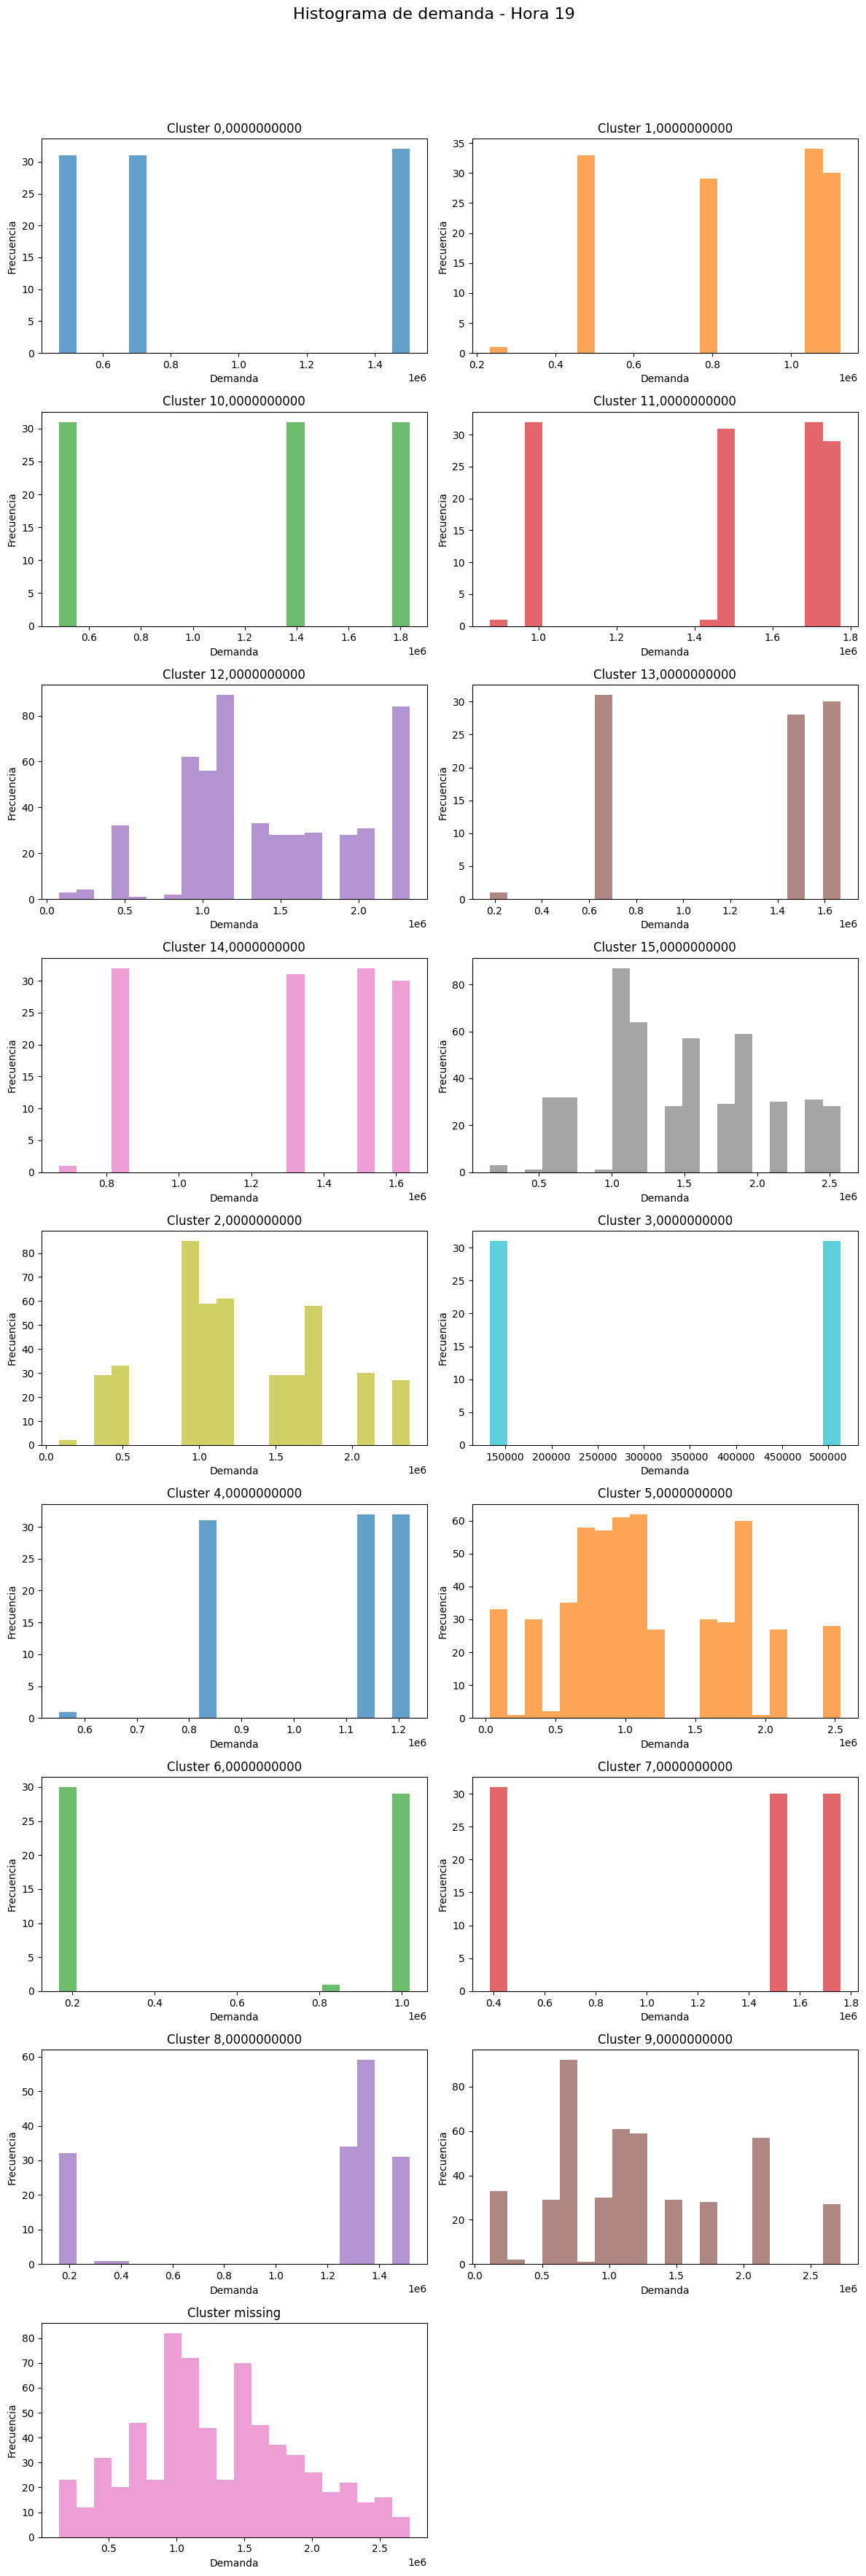

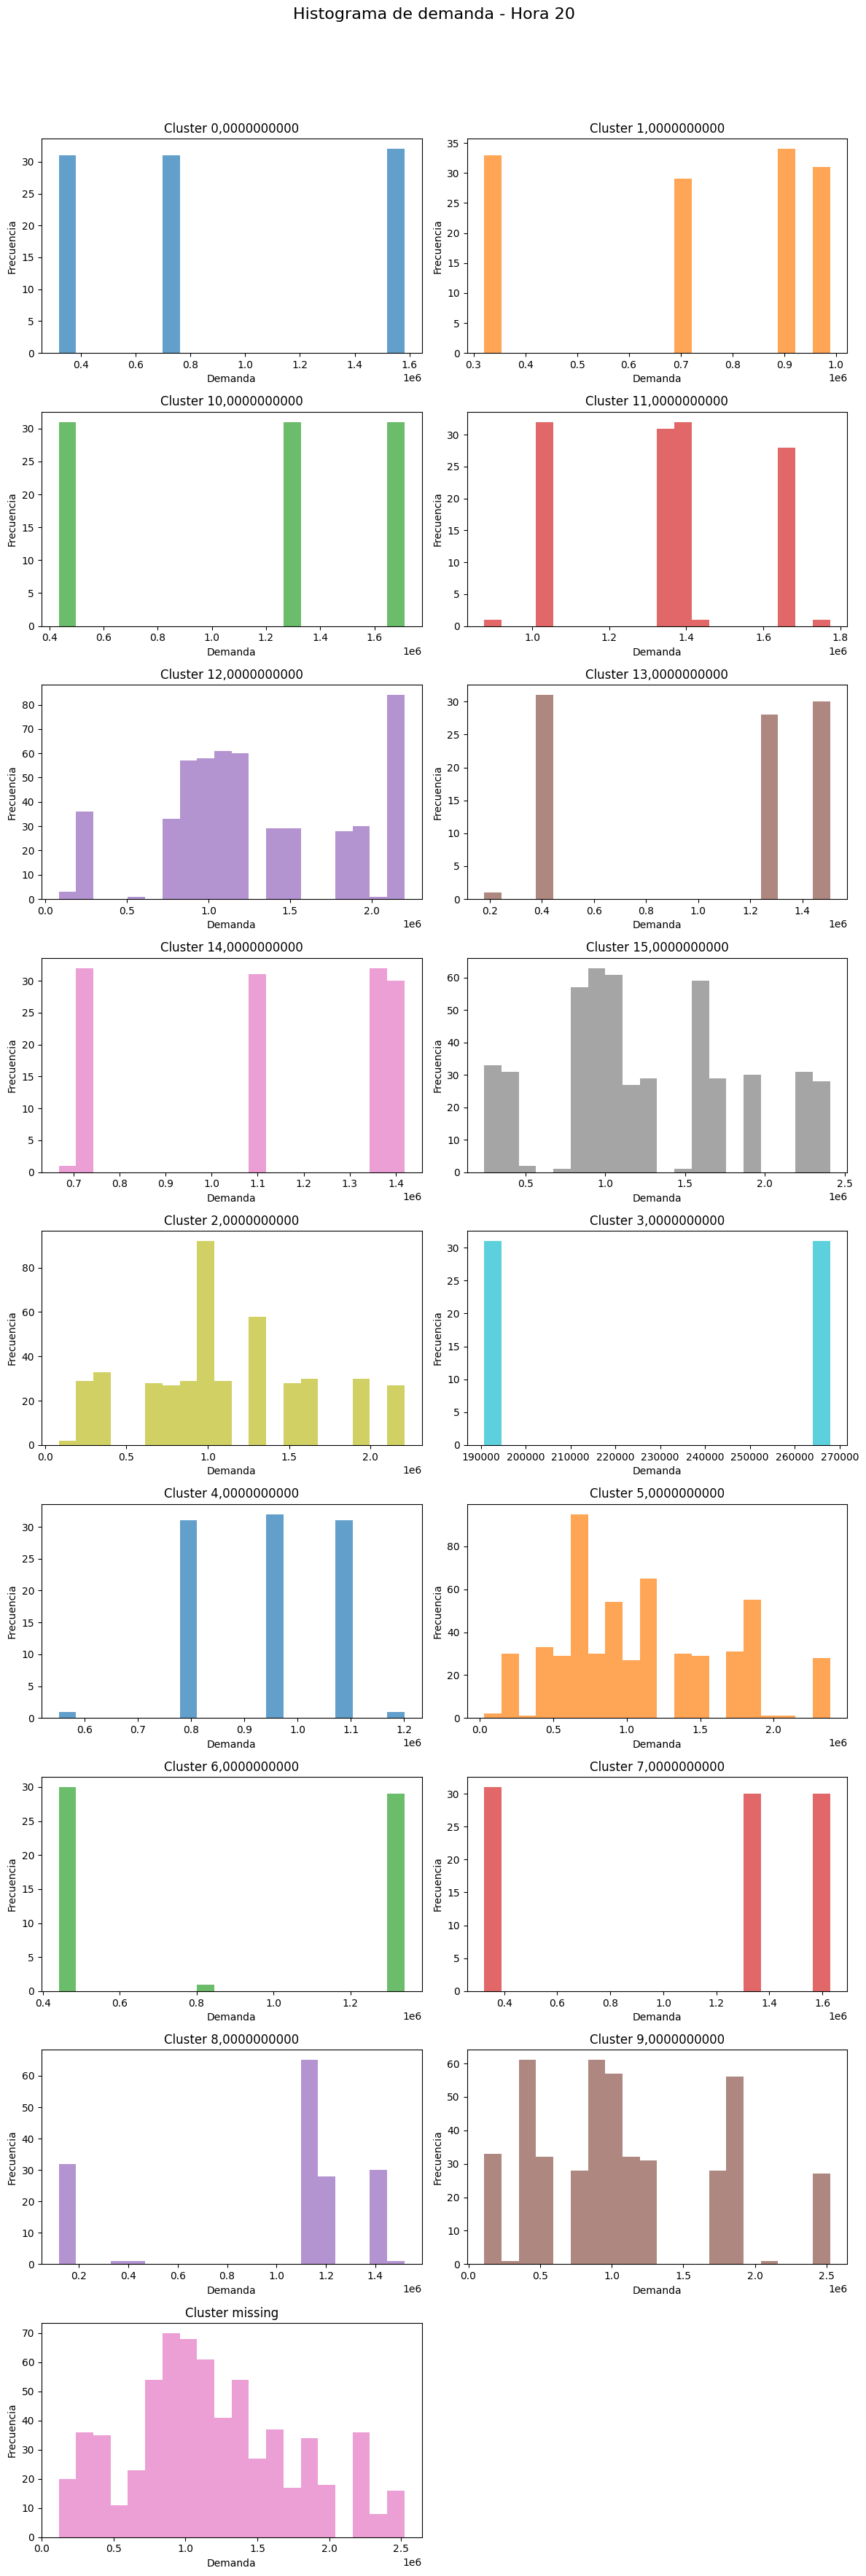

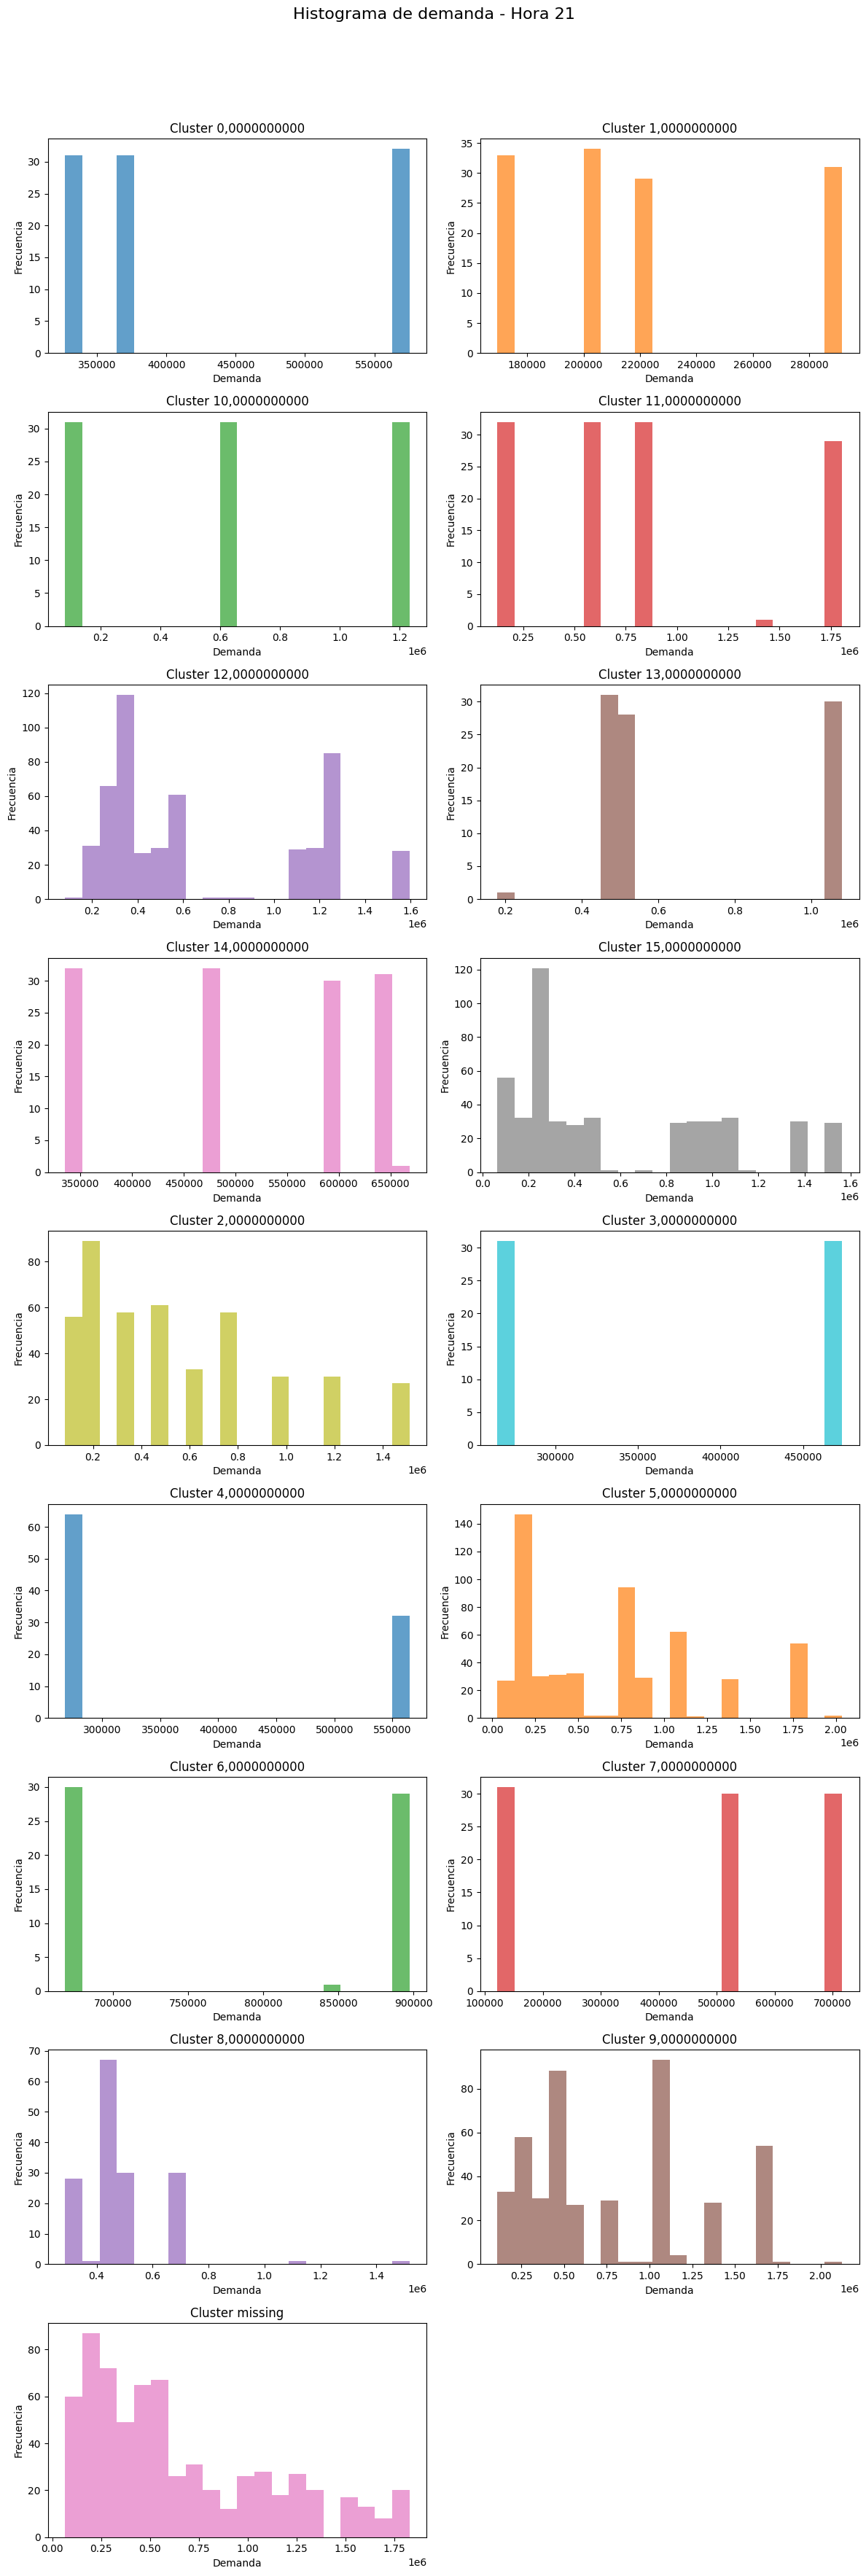

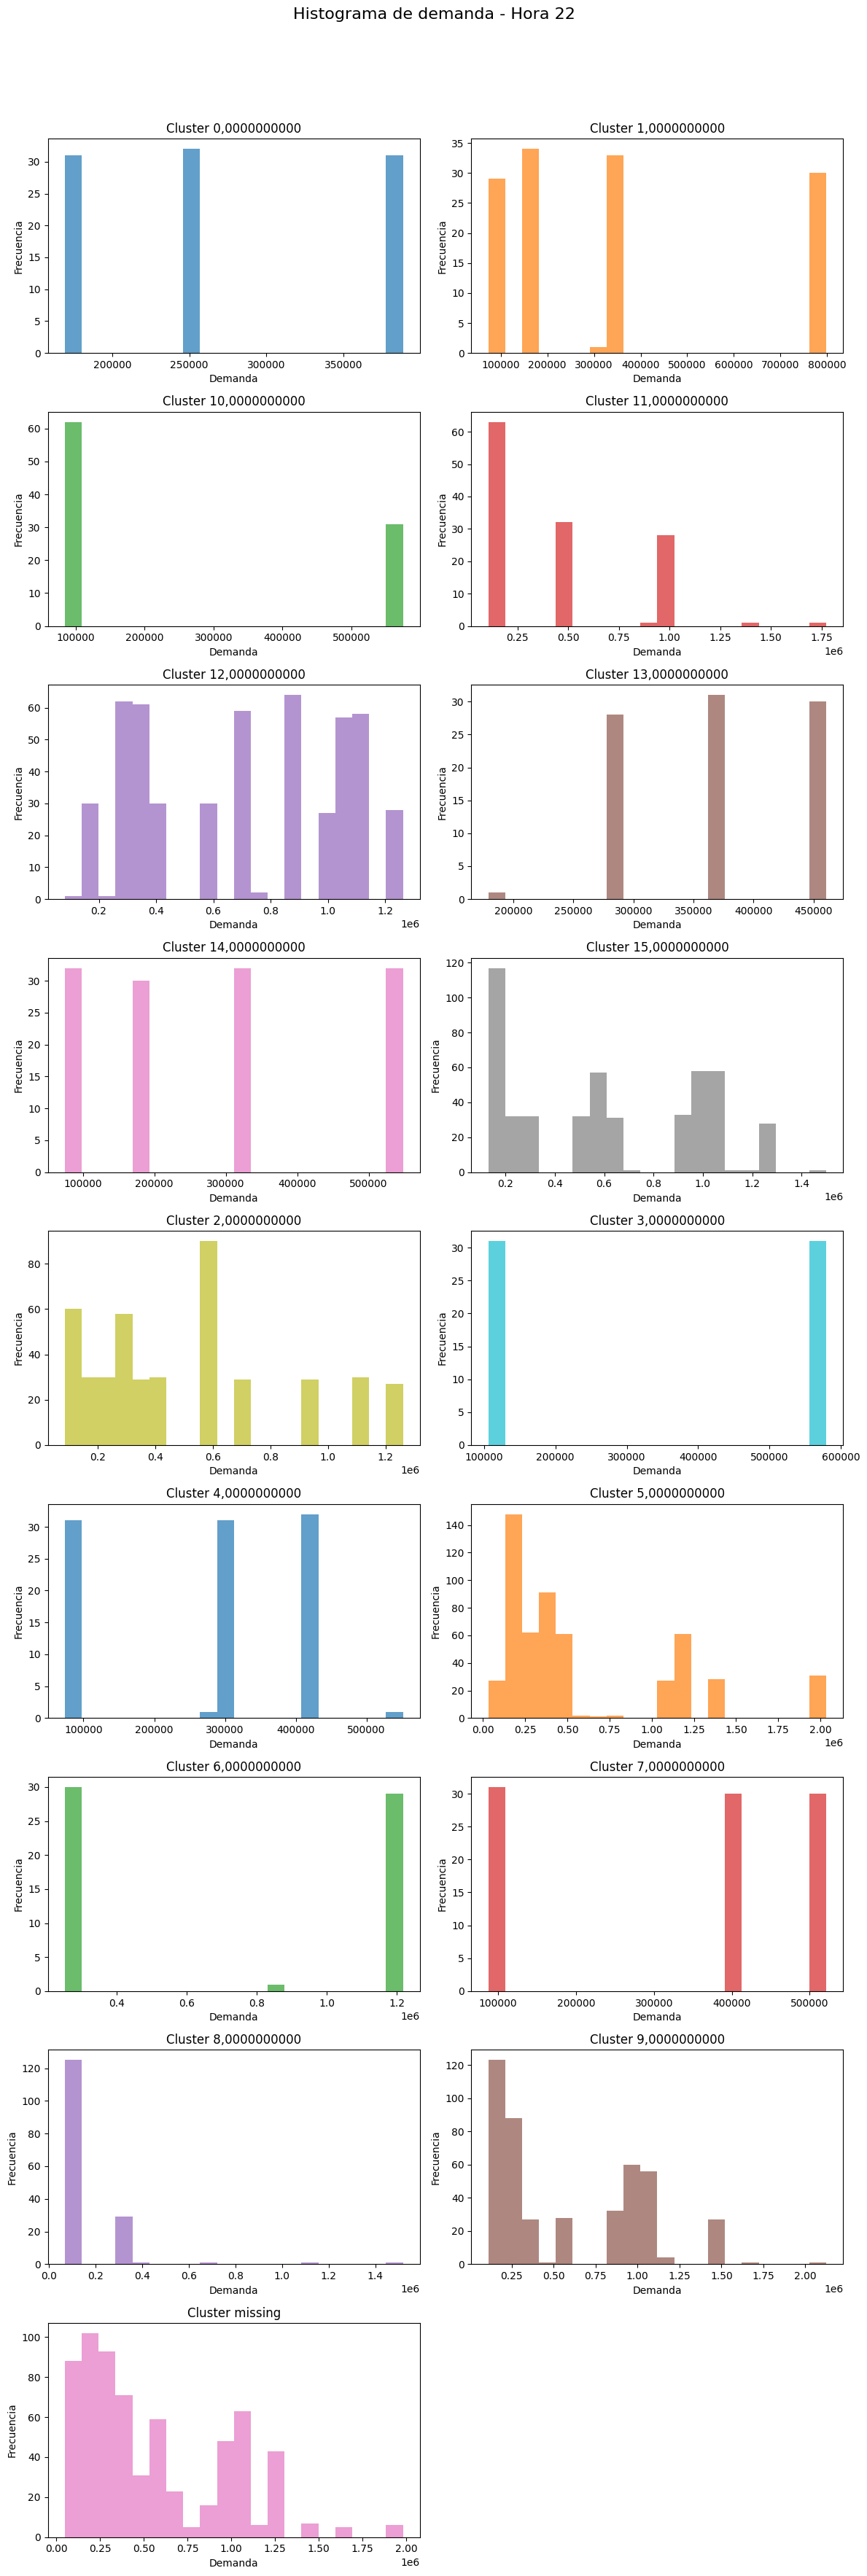

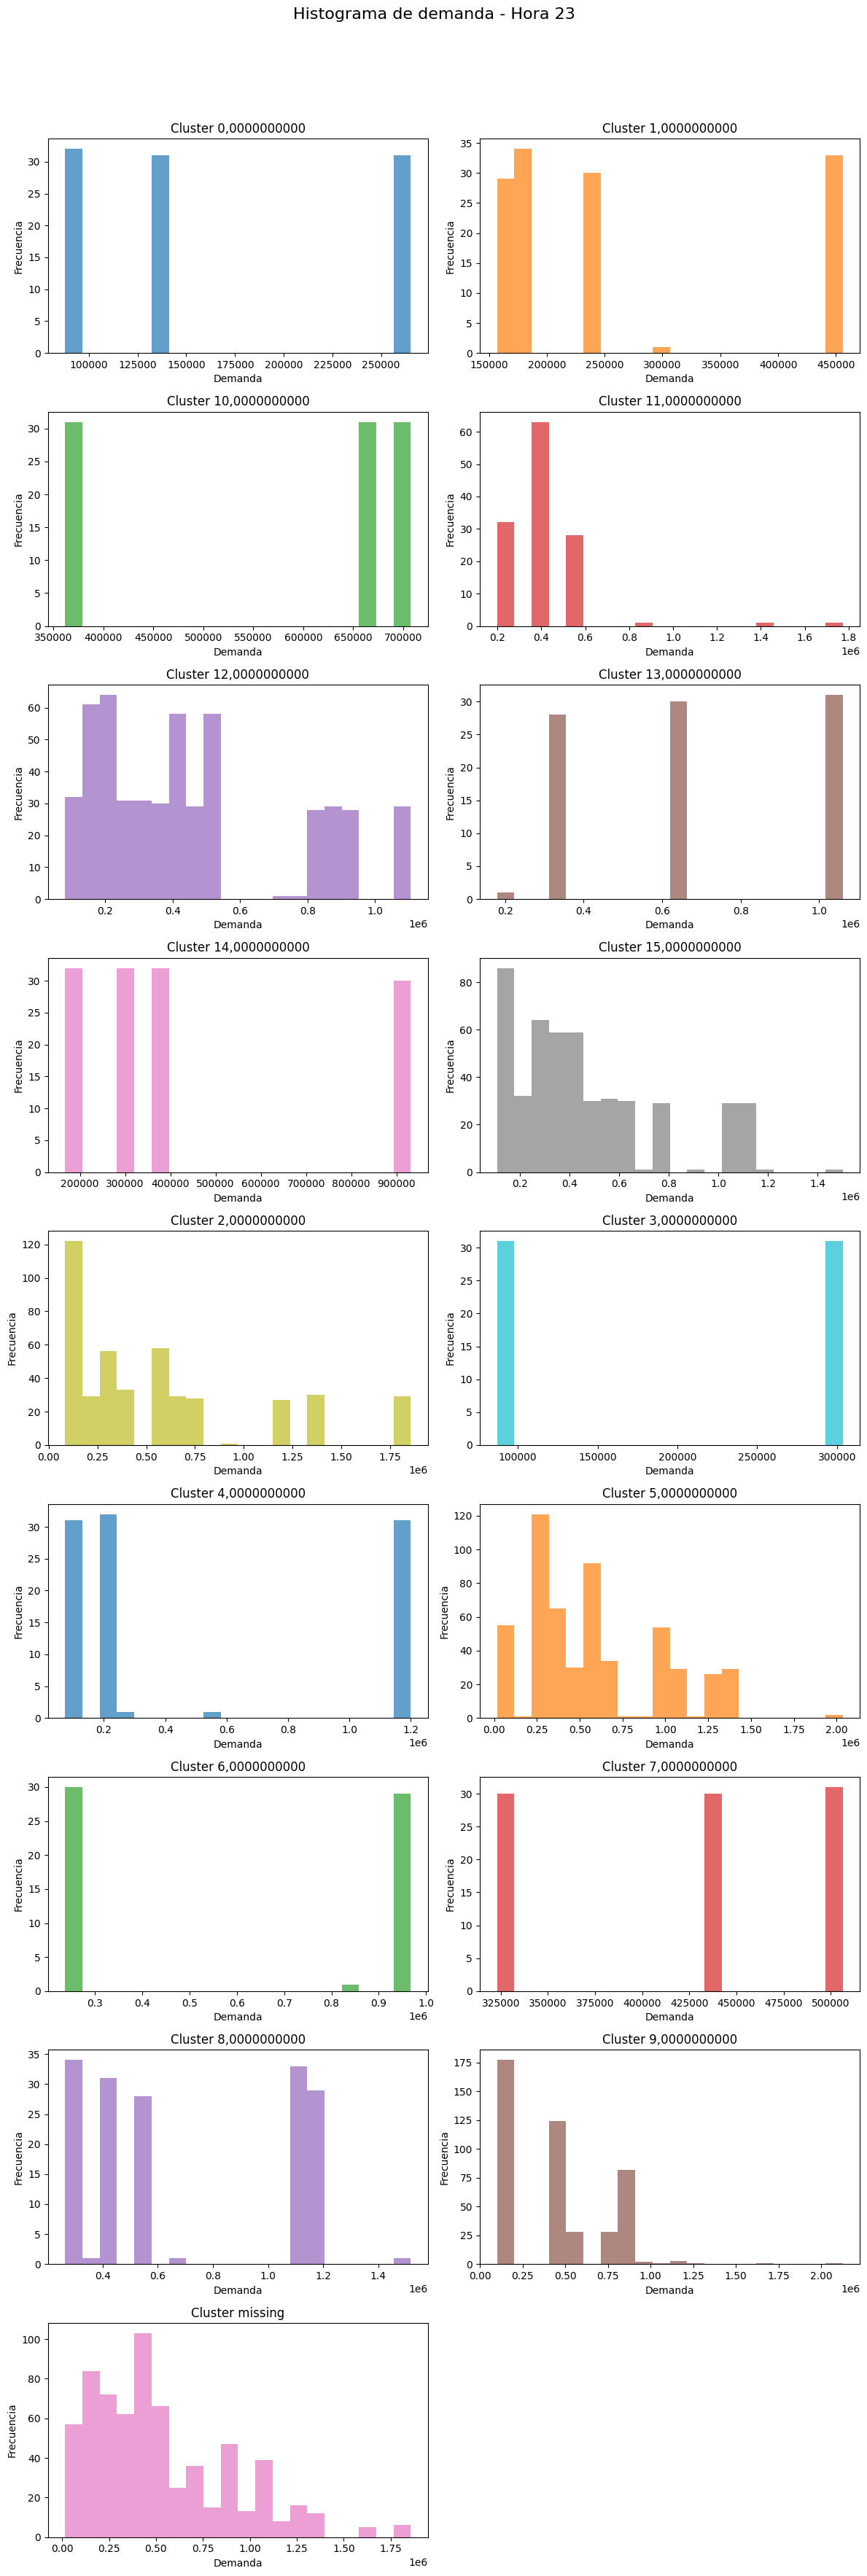

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Asegurarse de que daily_reman_demand sea lista
# -------------------------------
input_red['daily_reman_demand'] = input_red['daily_reman_demand'].apply(
    lambda x: eval(x) if isinstance(x, str) else x
)

# -------------------------------
# 2️⃣ Expandir la lista por fila
# -------------------------------
df_exp = input_red.explode('daily_reman_demand')

# -------------------------------
# 3️⃣ Crear hora_lista
# -------------------------------
df_exp['hora_lista'] = df_exp.groupby(['Fecha_sola','CodigoPlanta']).cumcount()

# -------------------------------
# 4️⃣ Convertir cluster a string y reemplazar NaN
# -------------------------------
df_exp['cluster'] = df_exp['cluster'].astype(str).fillna('missing')
clusters = sorted(df_exp['cluster'].unique())
horas = sorted(df_exp['hora_lista'].unique())

# Colores consistentes
colors = {c: plt.cm.tab10(i % 10) for i, c in enumerate(clusters)}

# -------------------------------
# 5️⃣ Graficar por hora con subplots por cluster
# -------------------------------
import math

for h in horas:
    n_cols = 2  # subplots por fila
    n_rows = math.ceil(len(clusters)/n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
    axes = axes.flatten()
    
    for i, c in enumerate(clusters):
        ax = axes[i]
        datos = df_exp[(df_exp['hora_lista']==h) & (df_exp['cluster']==c)]['daily_reman_demand']
        
        if len(datos) > 0:
            ax.hist(datos, bins=20, alpha=0.7, color=colors[c])
        
        ax.set_title(f'Cluster {c}')
        ax.set_xlabel('Demanda')
        ax.set_ylabel('Frecuencia')
    
    # eliminar ejes vacíos
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f'Histograma de demanda - Hora {h}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

